# OpenTelemetry Trace Duration Heatmap Analysis

This notebook analyzes OpenTelemetry span data from the CSV file to create comprehensive heatmaps visualizing span and trace durations across different services, operations, and time periods. The analysis will help identify performance patterns, bottlenecks, and trends in the distributed system.

## Setup

In [65]:
# Install and import required Azure libraries for Log Analytics
!pip install azure-monitor-query azure-identity azure-core

from azure.monitor.query import LogsQueryClient
from azure.identity import DefaultAzureCredential
from azure.core.exceptions import HttpResponseError
import pandas as pd
from datetime import datetime, timedelta
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

import pytz
from datetime import datetime, timedelta

pacific_tz = pytz.timezone('US/Pacific')

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")

# Configure display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("Libraries imported successfully!")

print("Azure libraries imported successfully!")

Libraries imported successfully!
Azure libraries imported successfully!


In [66]:
# Configure Log Analytics Workspace connection
workspace_id = "4f42970f-23c5-4a26-ba64-f40c3775fdfe"  # Use workspace GUID, not full resource path

# Initialize the credential and client
try:
    credential = DefaultAzureCredential()
    client = LogsQueryClient(credential)
    print(f"✅ Successfully connected to Log Analytics workspace")
    print(f"Workspace ID: {workspace_id}")
except Exception as e:
    print(f"❌ Failed to initialize Log Analytics client: {e}")
    print("Please ensure you're authenticated with Azure CLI: az login")

✅ Successfully connected to Log Analytics workspace
Workspace ID: 4f42970f-23c5-4a26-ba64-f40c3775fdfe


### Function Definitions
These are re-used for each query that's analyzed

In [67]:
def queryOTel(table_name, time_start, time_end, additional_filters="", projection_columns=None, max_batch_size=500000):
        """Execute a single batch query"""
        # Build the query
        if projection_columns:
            project_clause = f"| project {', '.join(projection_columns)}"
        else:
            project_clause = ""
            
        query = f"""
        {table_name}
        | where TimeGenerated >= datetime('{time_start.isoformat()}')
        | where TimeGenerated < datetime('{time_end.isoformat()}')
        {additional_filters}
        {project_clause}
        | limit {max_batch_size}
        """
        
        print(f"📊 Querying {time_start.strftime('%m/%d %H:%M')} to {time_end.strftime('%m/%d %H:%M')}...")
        print(f"🔍 Query details:")
        print(f"   • Table: {table_name}")
        print(f"   • Time range: {(time_end - time_start).total_seconds() / 3600:.2f} hours")
        print(f"   • Limit: {max_batch_size:,} rows")
        if additional_filters.strip():
            print(f"   • Filters: {additional_filters.strip()}")
        if projection_columns:
            print(f"   • Columns: {', '.join(projection_columns)}")
        print(f"   • KQL Query:")
        for i, line in enumerate(query.strip().split('\n'), 1):
            print(f"     {i:2}: {line}")
        print()
        
        print(f"   🔄 Executing query...")
        response = client.query_workspace(
            workspace_id=workspace_id,
            query=query,
            timespan=None
        )
        print(f"   ✅ Query executed, processing response...")
        batch_rows, batch_columns = [], []

        if hasattr(response, 'tables') and len(response.tables) > 0:
            print(f"   ✅ Query returned {len(response.tables)} tables")
            table = response.tables[0]
            print(f"     📊 Table has {len(table.rows):,} rows")
            batch_rows, batch_columns = table.rows, table.columns
            print(f"     📋 Columns: {len(batch_columns)} ({', '.join([str(col.name) if hasattr(col, 'name') else str(col) for col in batch_columns][:5])}{'...' if len(batch_columns) > 5 else ''})")
            print(f"     📊 Rows: {len(batch_rows):,}")
        else:
                print(f"  ⚠️ No data found - Response analysis:")
                if not hasattr(response, 'tables'):
                    print(f"     ❌ Response has no 'tables' attribute")
                    print(f"     📋 Response type: {type(response)}")
                    print(f"     📋 Response attributes: {[attr for attr in dir(response) if not attr.startswith('_')]}")
                    
                    print(f"\n     🔍 DETAILED LogsQueryPartialResult ANALYSIS:")
                        
                    # Check partial_data
                    if hasattr(response, 'partial_data') and response.partial_data is not None:
                        print(f"     📊 partial_data: {response.partial_data}")
                        if hasattr(response.partial_data, 'tables') and response.partial_data.tables:
                            print(f"        Tables in partial_data: {len(response.partial_data.tables)}")
                            for i, table in enumerate(response.partial_data.tables):
                                print(f"        Table {i}: {len(table.rows) if hasattr(table, 'rows') else 'No rows'} rows")
                    else:
                        print(f"     📊 partial_data: None or not available")
                    
                    # Check partial_error
                    if hasattr(response, 'partial_error') and response.partial_error is not None:
                        print(f"     ❌ partial_error: {response.partial_error}")
                        if hasattr(response.partial_error, 'code'):
                            print(f"        Error code: {response.partial_error.code}")
                        if hasattr(response.partial_error, 'message'):
                            print(f"        Error message: {response.partial_error.message}")
                    else:
                        print(f"     ❌ partial_error: None")
                    
                    # Check status
                    if hasattr(response, 'status'):
                        print(f"     📋 status: {response.status}")
                    
                    # Check statistics
                    if hasattr(response, 'statistics') and response.statistics is not None:
                        print(f"     📈 statistics: {response.statistics}")
                    else:
                        print(f"     📈 statistics: None")
                    
                    # Check visualization
                    if hasattr(response, 'visualization') and response.visualization is not None:
                        print(f"     📊 visualization: {response.visualization}")
                    else:
                        print(f"     📊 visualization: None")
                    
                    print(f"     💡 LogsQueryPartialResult indicates the query may have timed out or been throttled")
                    print(f"     💡 Some data may be available in partial_data even if query didn't complete fully")
                elif len(response.tables) == 0:
                    print(f"     ❌ Response has empty tables list")
                    print(f"     📋 Tables count: {len(response.tables)}")
                else:
                    print(f"     ❓ Unexpected response structure")

        df = pd.DataFrame(table.rows, columns=table.columns) if batch_rows and batch_columns else pd.DataFrame()
        return df

def create_heatmap(df_new):
    print(f"\n🎉 COMPLETE QUERY SUCCESS!")
    print(f"   📊 Retrieved: {len(df_new):,} spans (NO LIMITS)")
    print(f"   🏗️ Shape: {df_new.shape}")

    # Convert TimeGenerated to datetime and Pacific timezone
    df_new['TimeGenerated'] = pd.to_datetime(df_new['TimeGenerated'])

    
    # Check if already timezone-aware and convert appropriately
    if df_new['TimeGenerated'].dt.tz is None:
        # Not timezone-aware, assume UTC and localize first
        df_new['TimeGenerated_Pacific'] = df_new['TimeGenerated'].dt.tz_localize('UTC').dt.tz_convert(pacific_tz)
    else:
        # Already timezone-aware, convert directly
        df_new['TimeGenerated_Pacific'] = df_new['TimeGenerated'].dt.tz_convert(pacific_tz)
    
    # Check the ACTUAL time range in Pacific time
    time_min_complete = df_new['TimeGenerated_Pacific'].min()
    time_max_complete = df_new['TimeGenerated_Pacific'].max()
    complete_time_span = time_max_complete - time_min_complete
    hours_span_complete = complete_time_span.total_seconds() / 3600
    
    print(f"\n📅 COMPLETE time range (Pacific): {time_min_complete.strftime('%Y-%m-%d %H:%M:%S %Z')} to {time_max_complete.strftime('%Y-%m-%d %H:%M:%S %Z')}")
    print(f"⏱️ COMPLETE span: {hours_span_complete:.2f} hours")
    print(f"🔥 This should show the FULL 4+ hours!")
    
    # Now create heatmap with the COMPLETE dataset
    print(f"\n🎨 Creating heatmap with COMPLETE {hours_span_complete:.1f} hour dataset...")
    
    # Use appropriate time bins for the full range
    if hours_span_complete > 48:
        freq = '15T'  # 15-minute bins for 4+ hours
        print(f"🔧 Using 15-minute bins for {hours_span_complete:.1f} hour span")
    elif hours_span_complete > 24:
        freq = '10T'  # 10-minute bins
        print(f"🔧 Using 10-minute bins for {hours_span_complete:.1f} hour span")
    else:
        freq = '1T'   # 5-minute bins
        print(f"🔧 Using 5-minute bins for {hours_span_complete:.1f} hour span")
    
    # Create time bins for the COMPLETE range using Pacific time
    time_bins_complete = pd.date_range(start=time_min_complete, end=time_max_complete, freq=freq)
    print(f"📦 Created {len(time_bins_complete)} time bins for complete range")
    
    # Create duration bins - use data-driven linear buckets
    # Get duration range for better binning
    min_duration = df_new['DurationMs'].min()
    max_duration = df_new['DurationMs'].max()

    print(f"📏 Duration range: {min_duration:.0f}ms to {max_duration:.0f}ms")
    
    # Create linear buckets based on data distribution
    # Use key percentiles to define ranges where most data lives
    key_percentiles = [0, 5, 10, 20, 30, 40, 50, 60, 70, 80, 85, 90, 92, 94, 96, 97, 98, 98.5, 99, 99.2, 99.4, 99.6, 99.8, 99.9, 100]
    percentile_values = np.percentile(df_new['DurationMs'], key_percentiles)
    
    # Remove duplicates and ensure monotonic increase
    duration_bins_complete = np.unique(percentile_values)
    
    print(f"📊 Created {len(duration_bins_complete)-1} data-driven linear buckets")
    print(f"   Key boundaries: {duration_bins_complete[0]:.0f}ms, {duration_bins_complete[5]:.0f}ms, {duration_bins_complete[10]:.0f}ms, {duration_bins_complete[15]:.0f}ms, {duration_bins_complete[-1]:.0f}ms")
    print(f"   More granular in data-dense ranges (0-99th percentile)")
    
    # Bin the COMPLETE data using Pacific time
    df_new['time_bin'] = pd.cut(df_new['TimeGenerated_Pacific'], bins=time_bins_complete, include_lowest=True)
    df_new['duration_bin'] = pd.cut(df_new['DurationMs'], bins=duration_bins_complete, include_lowest=True, duplicates='drop')

    # Create heatmap data for COMPLETE range
    heatmap_data_complete = df_new.groupby(['time_bin', 'duration_bin']).size().unstack(fill_value=0)

    print(f"🔥 COMPLETE heatmap shape: {heatmap_data_complete.shape}")
    
    # Create the COMPLETE heatmap visualization
    plt.figure(figsize=(24, 12))
    
    # Use log scale
    heatmap_data_complete_log = np.log1p(heatmap_data_complete)
    
    # Create heatmap - properly oriented with larger durations on top
    sns.heatmap(
        heatmap_data_complete_log.T.iloc[::-1],  # Transpose and flip to put larger durations on top
        cmap='Blues',
        cbar_kws={'label': 'Log(Request Count + 1)', 'shrink': 0.8},
        xticklabels=False,
        yticklabels=True
    )
    
    plt.title(f'🔥 COMPLETE {hours_span_complete:.1f}-Hour Time vs Duration Heatmap (Pacific Time)\n'
                f'OpenTelemetry Traces from {time_min_complete.strftime("%H:%M")} to {time_max_complete.strftime("%H:%M")} PT on {time_min_complete.strftime("%Y-%m-%d")}\n',
                fontsize=18, pad=30)

    plt.xlabel(f'Time - Pacific ({freq} intervals)', fontsize=16)
    plt.ylabel('Duration (seconds)', fontsize=16)
    
    # Format time labels
    label_freq = max(1, len(time_bins_complete)//12)  # Show ~12 labels
    time_labels_complete = [t.strftime('%H:%M') for t in time_bins_complete[::label_freq]]
    plt.xticks(range(0, len(time_bins_complete), label_freq), time_labels_complete, rotation=45)
    
    # Format duration labels - convert ms to seconds and reverse order since we flipped the heatmap
    duration_labels_complete = [f'{d/1000:.1f}' for d in duration_bins_complete[1:]]  # Convert ms to seconds
    duration_labels_complete_reversed = duration_labels_complete[::-1]  # Reverse to match flipped heatmap
    plt.yticks(range(len(duration_labels_complete_reversed)), duration_labels_complete_reversed)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n✅ COMPLETE HEATMAP GENERATED!")
    print(f"   ⏱️ Full {hours_span_complete:.2f} hours of data visualized")
    print(f"   📊 {len(df_new):,} total spans")
    print(f"   🔥 {len(time_bins_complete)} time intervals")
    print(f"   📈 Complete temporal patterns revealed!")

def parse_attributes_to_columns(df):
    """
    Parse Attributes JSON column and expand into separate columns
    
    Parameters:
    df (pandas.DataFrame): DataFrame containing an 'Attributes' column with JSON data
    
    Returns:
    pandas.DataFrame: DataFrame with original data plus expanded attribute columns
    """
    import json
    import pandas as pd
    from collections import defaultdict
    
    print("🔧 PARSING ATTRIBUTES JSON INTO SEPARATE COLUMNS")
    print("=" * 60)
    
    # Work with current dataset
    print(f"📊 Working with dataset: {len(df):,} spans")
    print(f"📋 Current columns: {list(df.columns)}")
    
    # Check if Attributes column exists
    if 'Attributes' not in df.columns:
        print("❌ No 'Attributes' column found in dataset")
        print(f"Available columns: {list(df.columns)}")
        return df
    
    print(f"✅ Found 'Attributes' column")
    
    # Create a copy to work with
    df_expanded = df.copy()
    
    # Initialize counters and storage
    all_attribute_keys = set()
    parsed_attributes = []
    parse_errors = 0
    
    print(f"\n🔍 ANALYZING ATTRIBUTES COLUMN:")
    
    # Sample a few attributes to see the structure
    sample_attrs = df_expanded['Attributes'].dropna().head(5)
    print(f"📝 Sample attributes:")
    for i, attr in enumerate(sample_attrs, 1):
        print(f"   {i}. {str(attr)[:100]}{'...' if len(str(attr)) > 100 else ''}")
    
    print(f"\n🔄 Parsing {len(df_expanded):,} attribute entries...")
    
    # Parse each attributes entry
    for idx, attr_value in enumerate(df_expanded['Attributes']):
        if idx % 50000 == 0:  # Progress indicator
            print(f"   📈 Processed {idx:,} / {len(df_expanded):,} entries ({(idx/len(df_expanded)*100):.1f}%)")
            
        parsed_attrs = {}
        
        if pd.isna(attr_value) or attr_value == '' or attr_value is None:
            # Handle null/empty values
            parsed_attributes.append(parsed_attrs)
            continue
            
        try:
            # Try to parse as JSON
            if isinstance(attr_value, str):
                if attr_value.strip().startswith('{') and attr_value.strip().endswith('}'):
                    # Looks like JSON
                    attrs_dict = json.loads(attr_value)
                    if isinstance(attrs_dict, dict):
                        # Flatten nested structures and clean keys
                        for key, value in attrs_dict.items():
                            # Clean key name for column usage
                            clean_key = str(key).replace('.', '_').replace(' ', '_').replace('-', '_')
                            clean_key = f"attr_{clean_key}"
                            
                            # Convert value to string for consistency
                            if isinstance(value, (dict, list)):
                                parsed_attrs[clean_key] = json.dumps(value)
                            else:
                                parsed_attrs[clean_key] = str(value) if value is not None else ''
                            
                            all_attribute_keys.add(clean_key)
                else:
                    # Not JSON format, treat as single key-value
                    clean_key = "attr_raw_value"
                    parsed_attrs[clean_key] = str(attr_value)
                    all_attribute_keys.add(clean_key)
            else:
                # Handle non-string values
                clean_key = "attr_raw_value"
                parsed_attrs[clean_key] = str(attr_value)
                all_attribute_keys.add(clean_key)
                
        except json.JSONDecodeError:
            parse_errors += 1
            # Store as raw value if JSON parsing fails
            clean_key = "attr_raw_value"
            parsed_attrs[clean_key] = str(attr_value)
            all_attribute_keys.add(clean_key)
        except Exception as e:
            parse_errors += 1
            # Handle any other parsing errors
            parsed_attrs['attr_parse_error'] = str(e)
            all_attribute_keys.add('attr_parse_error')
            
        parsed_attributes.append(parsed_attrs)
    
    print(f"   ✅ Completed parsing all {len(df_expanded):,} entries")
    
    # Convert parsed attributes to DataFrame
    print(f"\n📊 CREATING EXPANDED ATTRIBUTE COLUMNS:")
    attributes_df = pd.DataFrame(parsed_attributes)
    
    print(f"   🔑 Discovered {len(all_attribute_keys)} unique attribute keys")
    print(f"   ❌ Parse errors: {parse_errors:,} ({(parse_errors/len(df_expanded)*100):.2f}%)")
    print(f"   📋 New attribute columns: {len(attributes_df.columns)}")
    
    # Show most common attribute keys
    if len(attributes_df.columns) > 0:
        print(f"\n🏆 TOP ATTRIBUTE COLUMNS BY DATA COVERAGE:")
        coverage_stats = {}
        for col in attributes_df.columns:
            non_null_count = attributes_df[col].notna().sum()
            coverage_pct = (non_null_count / len(attributes_df)) * 100
            coverage_stats[col] = {'count': non_null_count, 'coverage': coverage_pct}
        
        # Sort by coverage
        sorted_attrs = sorted(coverage_stats.items(), key=lambda x: x[1]['coverage'], reverse=True)
        
        for i, (attr_name, stats) in enumerate(sorted_attrs[:15], 1):
            print(f"   {i:2d}. {attr_name:<30} | {stats['count']:>8,} spans ({stats['coverage']:>5.1f}%)")
        
        if len(sorted_attrs) > 15:
            print(f"   ... and {len(sorted_attrs) - 15} more attribute columns")
    
    # Combine original dataframe with parsed attributes
    print(f"\n🔗 COMBINING WITH ORIGINAL DATA:")
    df_with_attributes = pd.concat([df_expanded.reset_index(drop=True), attributes_df.reset_index(drop=True)], axis=1)
    
    print(f"   📊 Original shape: {df_expanded.shape}")
    print(f"   📊 Attributes shape: {attributes_df.shape}")
    print(f"   📊 Combined shape: {df_with_attributes.shape}")
    print(f"   🔢 Total columns: {len(df_with_attributes.columns)} ({len(attributes_df.columns)} new attribute columns)")
    
    print(f"\n✅ ATTRIBUTES PARSING COMPLETE!")
    print(f"   📈 Dataset now has {len(df_with_attributes):,} rows and {len(df_with_attributes.columns)} columns")
    print(f"   🎯 Ready for enhanced analysis with all attribute data!")
    
    # Show sample of new data structure
    if len(attributes_df.columns) > 0:
        print(f"\n🔍 SAMPLE OF EXPANDED DATA:")
        sample_cols = ['TimeGenerated', 'Name', 'ServiceName', 'DurationMs'] + list(attributes_df.columns)[:5]
        available_cols = [col for col in sample_cols if col in df_with_attributes.columns]
        print(df_with_attributes[available_cols].head(3).to_string(max_colwidth=30))
    
    return df_with_attributes

# Example usage:
# df = parse_attributes_to_columns(df)


def segment_anomaly_baseline(df, is_in_anomaly_time_window_func, 
                           anomaly_duration_min_ms=1156000, 
                           anomaly_duration_max_ms=4712000,
                           pacific_tz=pacific_tz):
    """
    Segment data into anomaly vs baseline groups based on time window and duration criteria.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Input dataframe containing OpenTelemetry span data
    is_in_anomaly_time_window_func : function
        Function that takes a timestamp and returns True if it's in the anomaly time window
    anomaly_duration_min_ms : float, default=1156000
        Minimum duration in milliseconds for anomaly classification
    anomaly_duration_max_ms : float, default=4712000
        Maximum duration in milliseconds for anomaly classification
    pacific_tz : timezone, default=pacific_tz
        Pacific timezone object for time conversion
    
    Returns:
    --------
    tuple : (df_anomaly, df_baseline)
        Two dataframes - anomaly traces and baseline traces
    """
    
    print("📊 SEGMENTING DATA: ANOMALY vs BASELINE")
    print("=" * 50)
    
    if len(df) == 0:
        print("⚠️ Input dataframe is empty")
        return pd.DataFrame(), pd.DataFrame()
    
    # Create a copy to avoid modifying the original dataframe
    df_work = df.copy()
    
    print(f"✅ Processing {len(df_work):,} spans")
    
    # Convert TimeGenerated to datetime and Pacific timezone if not already done
    if 'TimeGenerated_Pacific' not in df_work.columns:
        df_work['TimeGenerated'] = pd.to_datetime(df_work['TimeGenerated'])
        
        if df_work['TimeGenerated'].dt.tz is None:
            df_work['TimeGenerated_Pacific'] = df_work['TimeGenerated'].dt.tz_localize('UTC').dt.tz_convert(pacific_tz)
        else:
            df_work['TimeGenerated_Pacific'] = df_work['TimeGenerated'].dt.tz_convert(pacific_tz)
    
    print(f"\n🎯 Applying anomaly criteria...")
    print(f"   ⏱️ Duration range: {anomaly_duration_min_ms/1000:.1f} - {anomaly_duration_max_ms/1000:.1f} seconds")
    
    # Check duration criteria
    duration_anomaly = (
        (df_work['DurationMs'] >= anomaly_duration_min_ms) & 
        (df_work['DurationMs'] <= anomaly_duration_max_ms)
    )
    
    # Check time window criteria using the provided function
    time_anomaly = df_work['TimeGenerated_Pacific'].apply(is_in_anomaly_time_window_func)
    
    # Combine both criteria for anomaly identification
    anomaly_mask = duration_anomaly & time_anomaly
    
    # Create anomaly and baseline datasets
    df_anomaly = df_work[anomaly_mask].copy()
    df_baseline = df_work[~anomaly_mask].copy()
    
    # Sample datasets to 1000 points each for performance
    sample_size = 1000
    
    # Sample anomaly dataset if it has more than sample_size rows
    if len(df_anomaly) > sample_size:
        df_anomaly_original_size = len(df_anomaly)
        df_anomaly = df_anomaly.sample(n=sample_size, random_state=42).copy()
        print(f"\n🎯 SAMPLING: Anomaly dataset sampled from {df_anomaly_original_size:,} to {len(df_anomaly):,} traces")
    
    # Sample baseline dataset if it has more than sample_size rows
    if len(df_baseline) > sample_size:
        df_baseline_original_size = len(df_baseline)
        df_baseline = df_baseline.sample(n=sample_size, random_state=42).copy()
        print(f"🎯 SAMPLING: Baseline dataset sampled from {df_baseline_original_size:,} to {len(df_baseline):,} traces")
    
    print(f"\n📈 DATA SEGMENTATION RESULTS:")
    print(f"   🔴 Anomaly traces: {len(df_anomaly):,} ({len(df_anomaly)/len(df_work)*100:.1f}%)")
    print(f"   🟢 Baseline traces: {len(df_baseline):,} ({len(df_baseline)/len(df_work)*100:.1f}%)")
    print(f"   📊 Total traces: {len(df_work):,}")
    
    if len(df_anomaly) > 0:
        # Show anomaly characteristics
        print(f"\n🔍 ANOMALY GROUP CHARACTERISTICS:")
        print(f"   ⏱️ Duration range: {df_anomaly['DurationMs'].min()/1000:.1f} - {df_anomaly['DurationMs'].max()/1000:.1f} seconds")
        print(f"   🕐 Time range: {df_anomaly['TimeGenerated_Pacific'].min().strftime('%H:%M')} - {df_anomaly['TimeGenerated_Pacific'].max().strftime('%H:%M')} PT")
        
        if 'ServiceName' in df_anomaly.columns:
            print(f"   🏗️ Unique services: {df_anomaly['ServiceName'].nunique()}")
        if 'Name' in df_anomaly.columns:
            print(f"   📝 Unique operations: {df_anomaly['Name'].nunique()}")
    
    if len(df_baseline) > 0:
        print(f"\n🔍 BASELINE GROUP CHARACTERISTICS:")
        print(f"   ⏱️ Duration range: {df_baseline['DurationMs'].min()/1000:.1f} - {df_baseline['DurationMs'].max()/1000:.1f} seconds")
        print(f"   🕐 Time range: {df_baseline['TimeGenerated_Pacific'].min().strftime('%H:%M')} - {df_baseline['TimeGenerated_Pacific'].max().strftime('%H:%M')} PT")
        
        if 'ServiceName' in df_baseline.columns:
            print(f"   🏗️ Unique services: {df_baseline['ServiceName'].nunique()}")
        if 'Name' in df_baseline.columns:
            print(f"   📝 Unique operations: {df_baseline['Name'].nunique()}")
    
    if len(df_anomaly) > 0:
        print(f"\n✅ Data successfully segmented for analysis!")
    else:
        print(f"\n⚠️ No anomaly traces found with current criteria")
    
    return df_anomaly, df_baseline

def create_attribute_paired_histograms(df_anomaly, df_baseline, actual_attr_columns, max_charts=20):
    """
    Create paired histograms for attribute columns comparing anomaly vs baseline data.
    
    Parameters:
    -----------
    df_anomaly : pandas.DataFrame
        DataFrame containing anomaly traces
    df_baseline : pandas.DataFrame  
        DataFrame containing baseline traces
    actual_attr_columns : list
        List of attribute column names to analyze
    max_charts : int, optional
        Maximum number of charts to create (default: 20)
    
    Returns:
    --------
    dict
        Summary statistics including number of figures created
    """
    import pandas as pd
    
    print("📊 CREATING ATTRIBUTE PAIRED HISTOGRAMS")
    print("=" * 50)
    
    if not actual_attr_columns or len(actual_attr_columns) == 0:
        print("⚠️ No suitable attribute columns found for analysis")
        print("   🔄 Please provide valid attribute columns for analysis")
        return {'figures_created': 0, 'error': 'No attribute columns provided'}
    
    print(f"🎨 Creating paired histograms for {len(actual_attr_columns)} attributes...")
    print(f"📊 Data available: {len(df_anomaly)} anomaly traces, {len(df_baseline)} baseline traces")
    
    figures_created = 0
    errors = []
    
    for i, attr_col in enumerate(actual_attr_columns):
        if figures_created >= max_charts:
            print(f"\n⚠️ Reached maximum chart limit ({max_charts}). Stopping to prevent overwhelming output.")
            break
            
        attr_display_name = attr_col.replace('attr_', '').replace('_', ' ').title()
        
        print(f"\n📋 {i+1}. {attr_display_name.upper()} ANALYSIS")
        
        try:
            # Get the data for both groups, handling potential duplicate columns
            anomaly_data = df_anomaly[attr_col]
            baseline_data = df_baseline[attr_col]
            
            # If we get DataFrames due to duplicate columns, take the first column
            if isinstance(anomaly_data, pd.DataFrame):
                anomaly_data = anomaly_data.iloc[:, 0]
            if isinstance(baseline_data, pd.DataFrame):
                baseline_data = baseline_data.iloc[:, 0]
            
            # Get non-null values for both groups
            anomaly_values = anomaly_data.dropna()
            baseline_values = baseline_data.dropna()
            
            if len(anomaly_values) == 0 and len(baseline_values) == 0:
                print(f"   ⚠️ No data available for {attr_display_name}")
                continue
                
            if len(anomaly_values) == 0:
                print(f"   ⚠️ No anomaly data for {attr_display_name}")
                continue
                
            # if len(baseline_values) == 0:
            #     print(f"   ⚠️ No baseline data for {attr_display_name}")
            #     continue
            
            # Calculate value counts for both groups
            anomaly_counts = anomaly_values.value_counts()
            baseline_counts = baseline_values.value_counts()
            
            # Get all unique values
            all_values = sorted(set(anomaly_counts.index) | set(baseline_counts.index))
            
            # If too many unique values, select top 20 by total frequency
            if len(all_values) > 20:
                print(f"   📊 Found {len(all_values)} unique values for {attr_display_name}. Showing top 20 by frequency.")
                
                # Calculate total counts for each value (anomaly + baseline)
                total_counts = {}
                for value in all_values:
                    anomaly_count = anomaly_counts.get(value, 0)
                    baseline_count = baseline_counts.get(value, 0)
                    total_counts[value] = anomaly_count + baseline_count
                
                # Sort by total count and take top 20
                top_values = sorted(total_counts.keys(), key=lambda x: total_counts[x], reverse=True)[:20]
                
                # Filter the data to only include top values
                anomaly_values_filtered = anomaly_values[anomaly_values.isin(top_values)]
                baseline_values_filtered = baseline_values[baseline_values.isin(top_values)]
                
                print(f"   🔝 Using top 20 values (representing {len(anomaly_values_filtered) + len(baseline_values_filtered):,} total instances)")
                
                # Use filtered data for visualization
                create_anomaly_histogram(
                    attr_display_name,
                    anomaly_values_filtered.tolist(),
                    baseline_values_filtered.tolist(),
                    f"{attr_display_name} Distribution (Top 20 Values)"
                )
            else:
                # Use all values if 20 or fewer
                create_anomaly_histogram(
                    attr_display_name,
                    anomaly_values.tolist(),
                    baseline_values.tolist(),
                    f"{attr_display_name} Distribution"
                )
            
            figures_created += 1
            
        except Exception as e:
            error_msg = f"Error creating chart for {attr_display_name}: {e}"
            print(f"   ❌ {error_msg}")
            errors.append(error_msg)
            continue
    
    print(f"\n✅ Attribute analysis completed!")
    print(f"   📊 Created {figures_created} attribute comparison charts")
    
    if errors:
        print(f"   ⚠️ {len(errors)} errors encountered")
    
    return {
        'figures_created': figures_created,
        'total_attributes': len(actual_attr_columns),
        'errors': errors,
        'success_rate': figures_created / len(actual_attr_columns) if actual_attr_columns else 0
    }

## 1. Duration Anomaly Analysis

### Initial Query and Visualization

   🌊 Pacific time range: 2025-09-15 20:30:00 PDT to 2025-09-16 06:30:00 PDT
   🌍 UTC time range: 2025-09-16 03:30:00 UTC to 2025-09-16 13:30:00 UTC
   🕒 Querying from 2025-09-16 03:30:00 to 2025-09-16 13:30:00
📊 Querying 09/16 03:30 to 09/16 13:30...
🔍 Query details:
   • Table: OTelSpans
   • Time range: 10.00 hours
   • Limit: 500,000 rows
   • Filters: | where DurationMs > 0 and isnotempty(ServiceName) and ParentSpanId == '' | summarize DurationMs=max(DurationMs) by bin(TimeGenerated, 1m), ServiceName, Name, Attributes=tostring(Attributes), StatusCode, Success
   • Columns: TimeGenerated, DurationMs, ServiceName, Name, Attributes, StatusCode, Success
   • KQL Query:
      1: OTelSpans
      2:         | where TimeGenerated >= datetime('2025-09-16T03:30:00+00:00')
      3:         | where TimeGenerated < datetime('2025-09-16T13:30:00+00:00')
      4:         | where DurationMs > 0 and isnotempty(ServiceName) and ParentSpanId == '' | summarize DurationMs=max(DurationMs) by bin(TimeGen

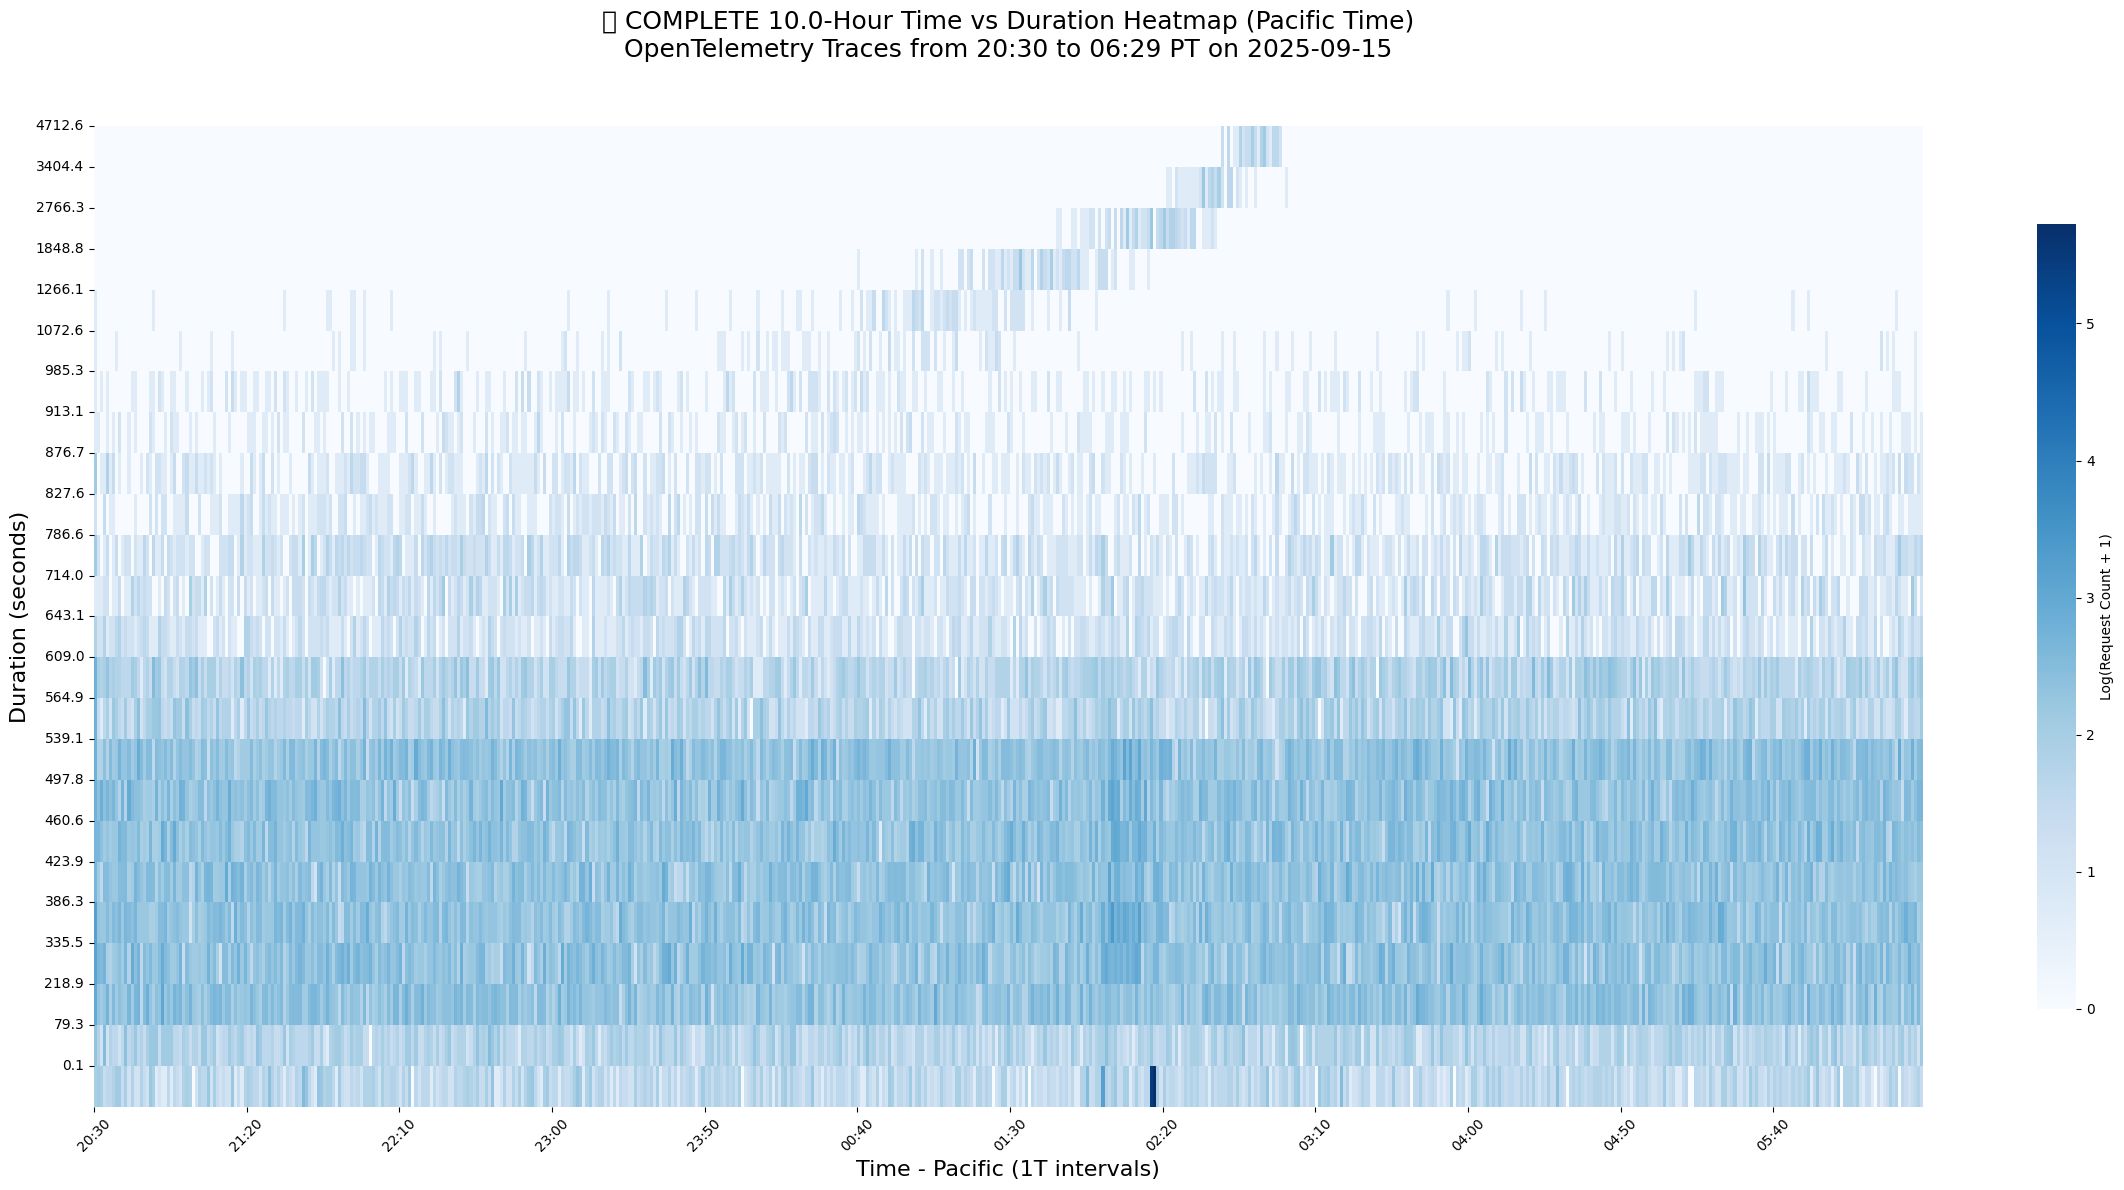


✅ COMPLETE HEATMAP GENERATED!
   ⏱️ Full 9.98 hours of data visualized
   📊 56,233 total spans
   🔥 600 time intervals
   📈 Complete temporal patterns revealed!


In [68]:
from datetime import timezone

efficient_columns=['TimeGenerated', 'Name', 'ServiceName', 'DurationMs', 'StatusCode', 'Success', 'TraceId', 'SpanId', 'ParentSpanId', 'Attributes']
min_columns=['TimeGenerated', 'DurationMs']
table_name='OTelSpans'
start_ago_hours=48
end_ago_hours=40
additional_filters="| where DurationMs > 0 and isnotempty(ServiceName) and ParentSpanId == '' | summarize DurationMs=max(DurationMs) by bin(TimeGenerated, 1m), ServiceName, Name, Attributes=tostring(Attributes), StatusCode, Success"
projection_columns=['TimeGenerated', 'DurationMs', 'ServiceName', 'Name', 'Attributes', 'StatusCode', 'Success']
max_total_rows=None  # NO LIMIT - get ALL data!

# Calculate time range from ago
# end_time = datetime.now(timezone.utc) - timedelta(hours=end_ago_hours)
# start_time = datetime.now(timezone.utc) - timedelta(hours=start_ago_hours)

# Set specific Pacific time range: 09/15 20:30 to 09/16 06:30 Pacific
pacific_start = pacific_tz.localize(datetime(2025, 9, 15, 20, 30, 0))
pacific_end = pacific_tz.localize(datetime(2025, 9, 16, 6, 30, 0))

# Convert to UTC for the query
start_time = pacific_start.astimezone(timezone.utc)
end_time = pacific_end.astimezone(timezone.utc)

print(f"   🌊 Pacific time range: {pacific_start.strftime('%Y-%m-%d %H:%M:%S %Z')} to {pacific_end.strftime('%Y-%m-%d %H:%M:%S %Z')}")
print(f"   🌍 UTC time range: {start_time.strftime('%Y-%m-%d %H:%M:%S %Z')} to {end_time.strftime('%Y-%m-%d %H:%M:%S %Z')}")

print(f"   🕒 Querying from {start_time.strftime('%Y-%m-%d %H:%M:%S')} to {end_time.strftime('%Y-%m-%d %H:%M:%S')}")

# Generate time batches
df = queryOTel(table_name, start_time, end_time, additional_filters, projection_columns)
print(df.head())

if not df.empty:
    create_heatmap(df)
else:
    print(f"\n⚠️ Complete query returned empty results")
    

In [69]:
df = parse_attributes_to_columns(df).copy()

🔧 PARSING ATTRIBUTES JSON INTO SEPARATE COLUMNS
📊 Working with dataset: 56,233 spans
📋 Current columns: ['TimeGenerated', 'DurationMs', 'ServiceName', 'Name', 'Attributes', 'StatusCode', 'Success', 'TimeGenerated_Pacific', 'time_bin', 'duration_bin']
✅ Found 'Attributes' column

🔍 ANALYZING ATTRIBUTES COLUMN:
📝 Sample attributes:
   1. {"net.sock.peer.addr":"10.244.2.171","net.sock.peer.port":45002,"http.method":"GET","http.target":"/...
   2. {"net.sock.peer.addr":"10.244.2.171","net.sock.peer.port":45002,"http.method":"POST","http.target":"...
   3. {"net.sock.peer.addr":"10.244.2.171","net.sock.peer.port":45002,"http.method":"GET","http.target":"/...
   4. {"net.sock.peer.addr":"10.244.2.171","net.sock.peer.port":44992,"http.method":"POST","http.target":"...
   5. {"net.sock.peer.addr":"10.244.2.171","net.sock.peer.port":44992,"http.method":"GET","http.target":"/...

🔄 Parsing 56,233 attribute entries...
   📈 Processed 0 / 56,233 entries (0.0%)
   📈 Processed 50,000 / 56,233 entries

### Choose Anomaly Window

We will compare traces within the anomaly period (23:30-3:30 Pacific time, 1420-96150 seconds duration) against baseline traces to identify the root cause dimensions.

In [70]:
# Define anomaly criteria based on the identified pattern
print("🔍 DEFINING ANOMALY CRITERIA")
print("=" * 50)

# Anomaly time period: 23:30 to 3:30 Pacific time (spans midnight)
# Anomaly duration range: 1420 to 96150 seconds (23.67 minutes to 26.7 hours)

# Convert duration thresholds from seconds to milliseconds for our data
anomaly_duration_min_ms = 1156 * 1000  # 1,420 seconds = 1,420,000 ms
anomaly_duration_max_ms = 4712 * 1000  # 96,150 seconds = 96,150,000 ms

print(f"🕐 Anomaly Time Window: 23:30 - 03:30 Pacific Time")
print(f"⏱️ Anomaly Duration Range: {anomaly_duration_min_ms:,} - {anomaly_duration_max_ms:,} ms")
print(f"   ({anomaly_duration_min_ms/1000/60:.1f} - {anomaly_duration_max_ms/1000/60:.1f} minutes)")

# Function to check if a time falls within the anomaly window (handles midnight crossing)
def is_in_anomaly_time_window(timestamp):
    hour = timestamp.hour
    minute = timestamp.minute
    time_decimal = hour + minute/60.0
    
    # 00:16 = 0.267, 02:56 = 2.933
    # Time is anomalous if: 0.267 <= time <= 2.933
    return 0.267 <= time_decimal <= 2.933

🔍 DEFINING ANOMALY CRITERIA
🕐 Anomaly Time Window: 23:30 - 03:30 Pacific Time
⏱️ Anomaly Duration Range: 1,156,000 - 4,712,000 ms
   (19.3 - 78.5 minutes)


In [71]:
df_anomaly, df_baseline = segment_anomaly_baseline(df, is_in_anomaly_time_window)

📊 SEGMENTING DATA: ANOMALY vs BASELINE
✅ Processing 56,233 spans

🎯 Applying anomaly criteria...
   ⏱️ Duration range: 1156.0 - 4712.0 seconds
🎯 SAMPLING: Baseline dataset sampled from 55,862 to 1,000 traces

📈 DATA SEGMENTATION RESULTS:
   🔴 Anomaly traces: 371 (0.7%)
   🟢 Baseline traces: 1,000 (1.8%)
   📊 Total traces: 56,233

🔍 ANOMALY GROUP CHARACTERISTICS:
   ⏱️ Duration range: 1156.3 - 4470.7 seconds
   🕐 Time range: 00:22 - 02:55 PT
   🏗️ Unique services: 1
   📝 Unique operations: 2

🔍 BASELINE GROUP CHARACTERISTICS:
   ⏱️ Duration range: 0.0 - 1117.3 seconds
   🕐 Time range: 20:32 - 06:28 PT
   🏗️ Unique services: 2
   📝 Unique operations: 7

✅ Data successfully segmented for analysis!


### Generate Analysis Charts

We'll create paired histograms comparing the distribution of each dimension between anomaly traces and baseline traces.

#### General Dimensions Analysis

📊 CREATING PAIRED HISTOGRAMS
\n🎨 Creating paired histograms...
📊 Data available: 371 anomaly traces, 1000 baseline traces
\n📋 1. SERVICE NAME ANALYSIS


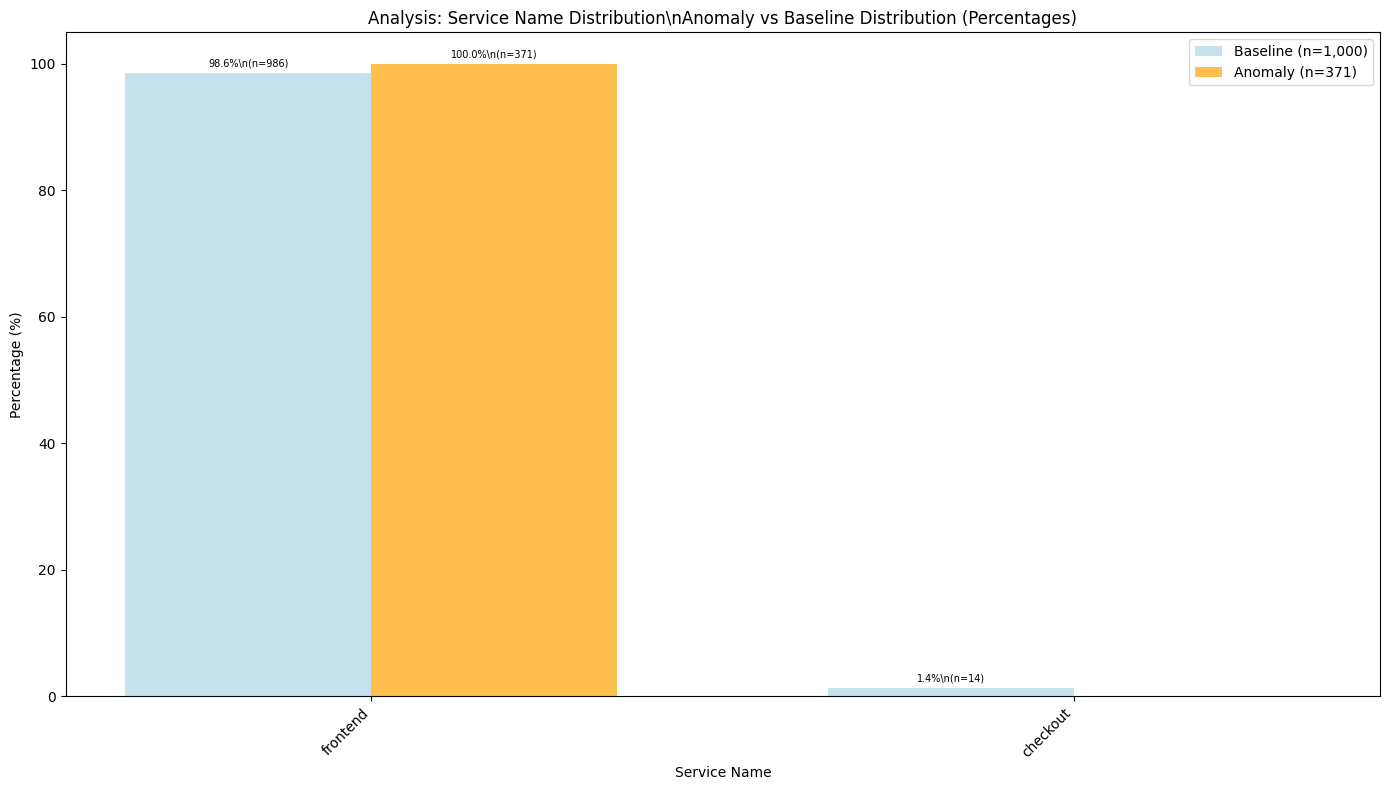

\n🔍 Service Name Analysis:
   📊 Total anomaly instances: 371
   📊 Total baseline instances: 1,000
   🚨 Values over-represented in anomaly group:
      • frontend: 100.0% of anomalies vs 98.6% of baseline (27.3% of this value is anomalous)
   🟢 Values over-represented in baseline group:
      • checkout: 1.4% of baseline vs 0.0% of anomalies (100.0% of this value is baseline)
\n📋 2. OPERATION NAME ANALYSIS


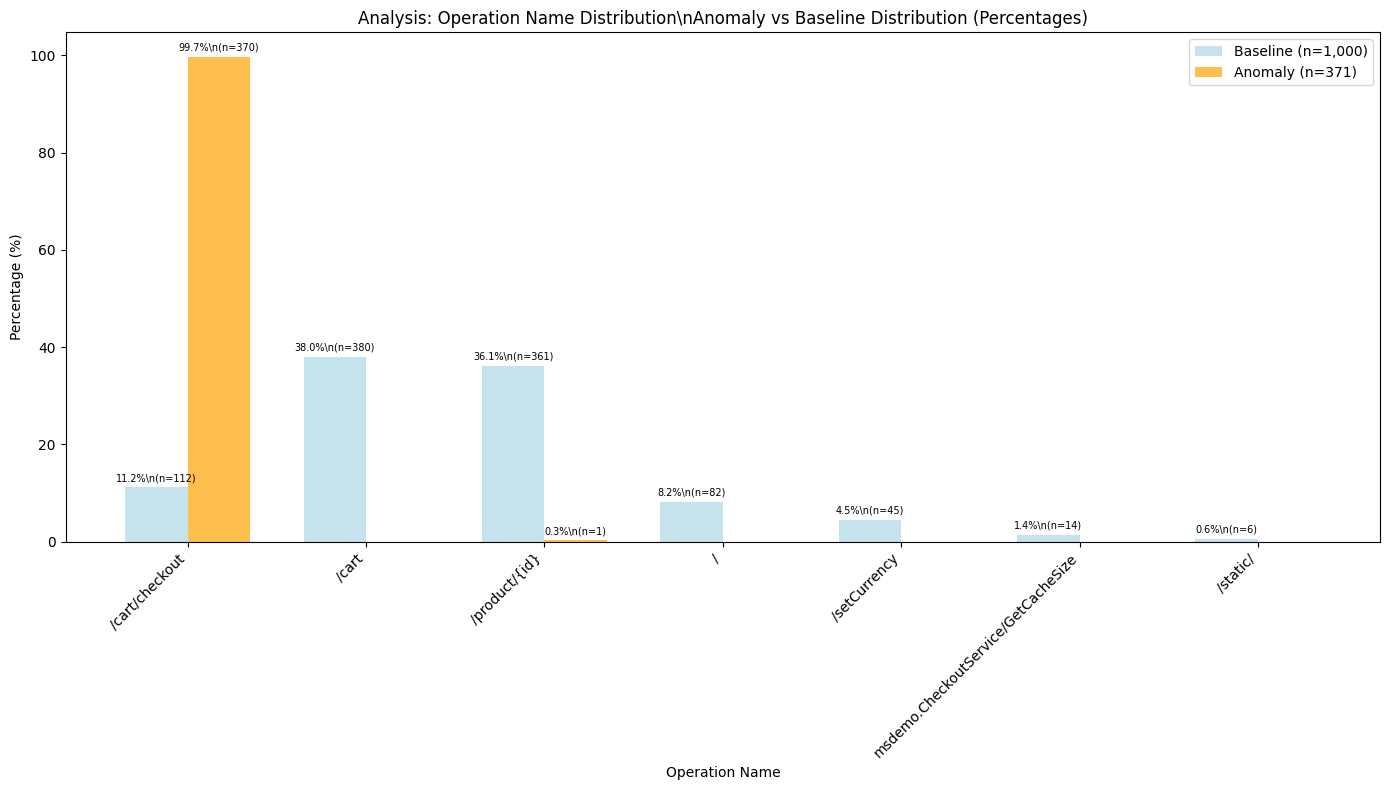

\n🔍 Operation Name Analysis:
   📊 Total anomaly instances: 371
   📊 Total baseline instances: 1,000
   🚨 Values over-represented in anomaly group:
      • /cart/checkout: 99.7% of anomalies vs 11.2% of baseline (76.8% of this value is anomalous)
   🟢 Values over-represented in baseline group:
      • /cart: 38.0% of baseline vs 0.0% of anomalies (100.0% of this value is baseline)
      • /product/{id}: 36.1% of baseline vs 0.3% of anomalies (99.7% of this value is baseline)
      • /: 8.2% of baseline vs 0.0% of anomalies (100.0% of this value is baseline)
\n📋 3. STATUS CODE ANALYSIS


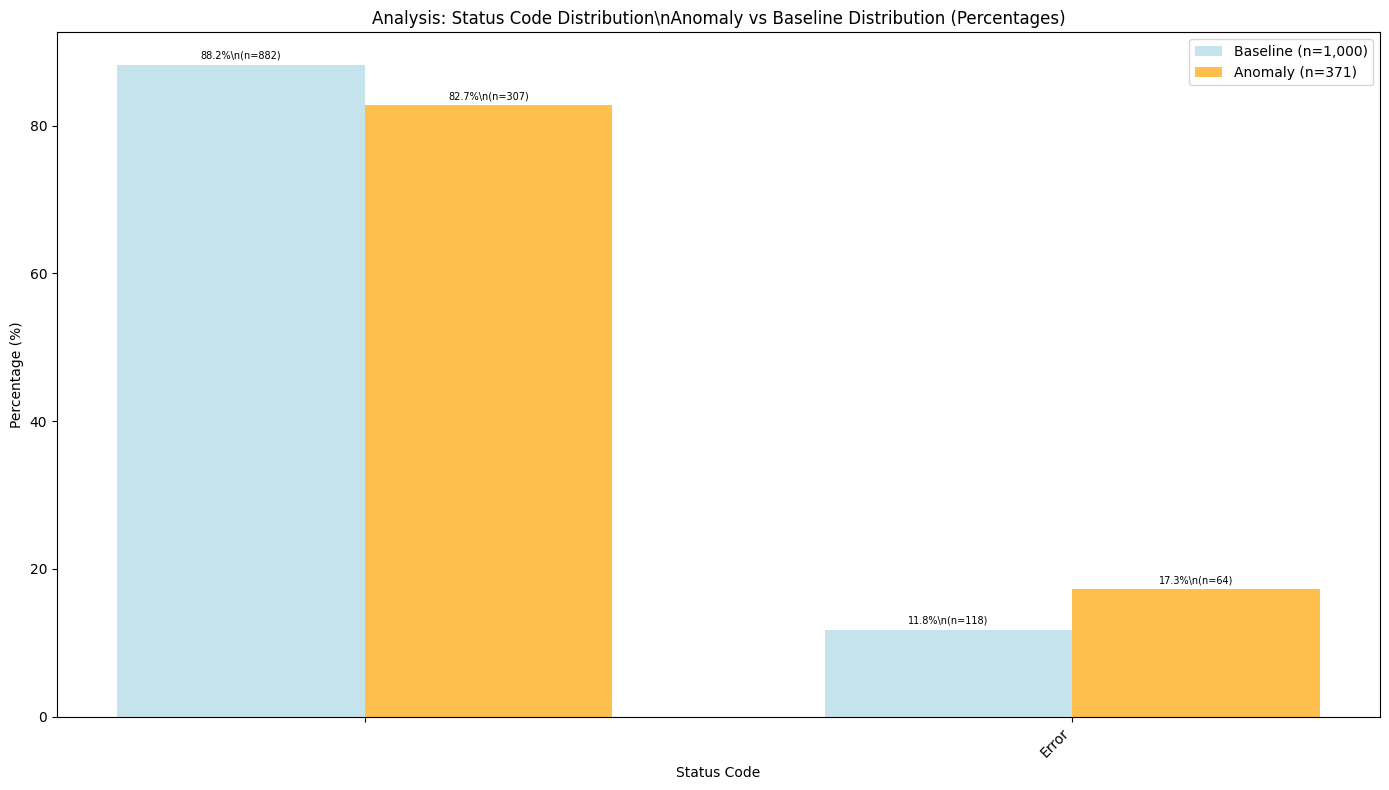

\n🔍 Status Code Analysis:
   📊 Total anomaly instances: 371
   📊 Total baseline instances: 1,000
   🚨 Values over-represented in anomaly group:
      • Error: 17.3% of anomalies vs 11.8% of baseline (35.2% of this value is anomalous)
\n📋 4. SUCCESS FLAG ANALYSIS


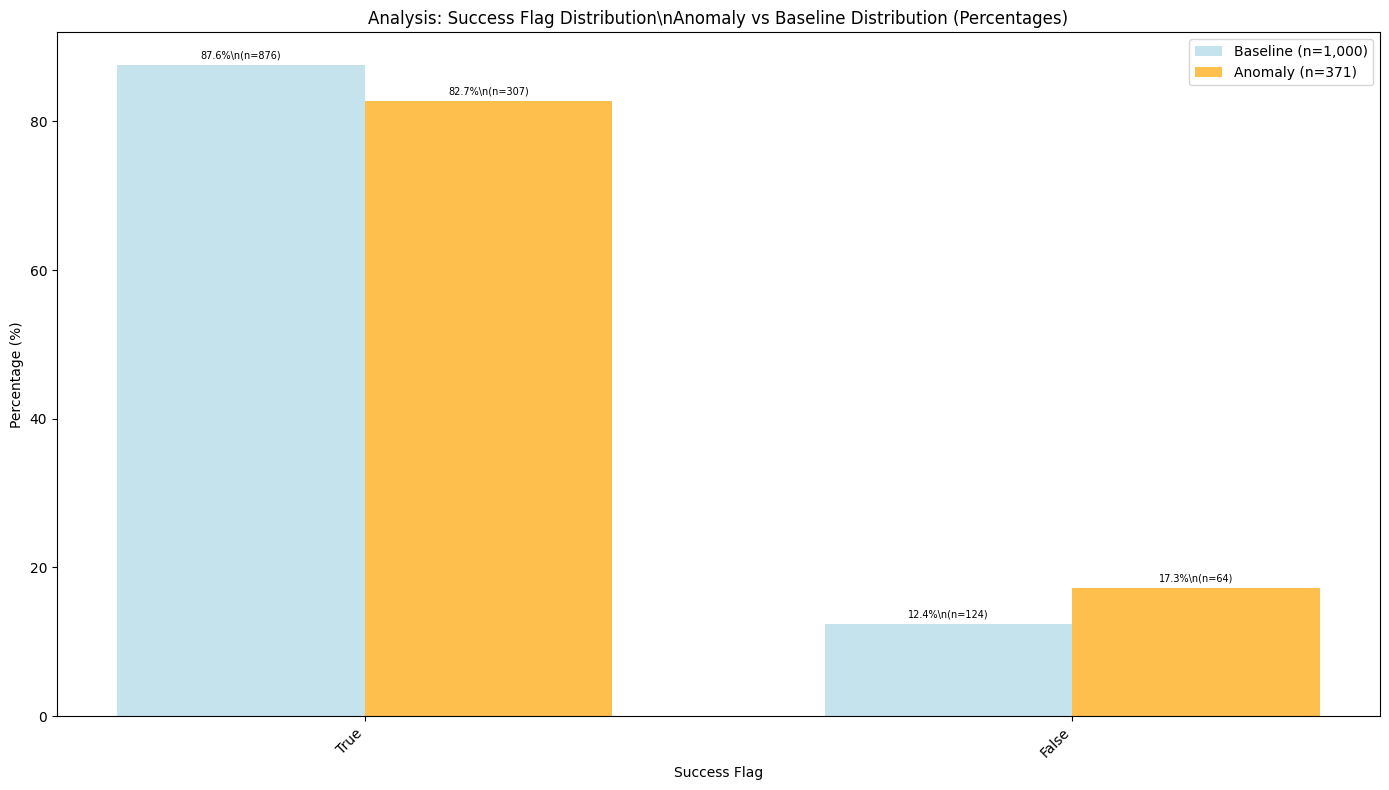

\n🔍 Success Flag Analysis:
   📊 Total anomaly instances: 371
   📊 Total baseline instances: 1,000
   🚨 Values over-represented in anomaly group:
      • False: 17.3% of anomalies vs 12.4% of baseline (34.0% of this value is anomalous)
\n✅ Paired histograms completed!


In [72]:
# Create paired histograms
print("📊 CREATING PAIRED HISTOGRAMS")
print("=" * 50)

import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

def create_anomaly_histogram(dimension_name, anomaly_values, baseline_values, title, max_categories=15):
    """
    Create a paired histogram comparing anomaly vs baseline distributions using percentages
    """
    # Get value counts for both groups
    anomaly_counts = Counter(anomaly_values)
    baseline_counts = Counter(baseline_values)
    
    # Calculate total counts for percentage calculation
    total_anomaly = sum(anomaly_counts.values())
    total_baseline = sum(baseline_counts.values())
    
    # Get all unique values and limit to top categories
    all_values = set(anomaly_counts.keys()) | set(baseline_counts.keys())
    
    # Sort by total frequency to show most important categories
    value_totals = {val: anomaly_counts.get(val, 0) + baseline_counts.get(val, 0) for val in all_values}
    top_values = sorted(value_totals.keys(), key=lambda x: value_totals[x], reverse=True)[:max_categories]
    
    # Prepare data for plotting (convert to percentages)
    categories = []
    anomaly_data = []
    baseline_data = []
    anomaly_counts_raw = []
    baseline_counts_raw = []
    
    for value in top_values:
        categories.append(str(value))
        
        # Raw counts for annotations
        anomaly_count = anomaly_counts.get(value, 0)
        baseline_count = baseline_counts.get(value, 0)
        anomaly_counts_raw.append(anomaly_count)
        baseline_counts_raw.append(baseline_count)
        
        # Convert to percentages
        anomaly_pct = (anomaly_count / total_anomaly * 100) if total_anomaly > 0 else 0
        baseline_pct = (baseline_count / total_baseline * 100) if total_baseline > 0 else 0
        
        anomaly_data.append(anomaly_pct)
        baseline_data.append(baseline_pct)
    
    # Create the paired bar chart
    x = np.arange(len(categories))
    width = 0.35
    
    fig, ax = plt.subplots(figsize=(14, 8))
    
    bars1 = ax.bar(x - width/2, baseline_data, width, label=f'Baseline (n={total_baseline:,})', color='lightblue', alpha=0.7)
    bars2 = ax.bar(x + width/2, anomaly_data, width, label=f'Anomaly (n={total_anomaly:,})', color='orange', alpha=0.7)
    
    ax.set_xlabel(dimension_name)
    ax.set_ylabel('Percentage (%)')
    ax.set_title(f'Analysis: {title}\\nAnomaly vs Baseline Distribution (Percentages)')
    ax.set_xticks(x)
    ax.set_xticklabels(categories, rotation=45, ha='right')
    ax.legend()
    
    # Add percentage and count labels on bars
    for i, bar in enumerate(bars1):
        height = bar.get_height()
        if height > 0:
            ax.annotate(f'{height:.1f}%\\n(n={baseline_counts_raw[i]})',
                       xy=(bar.get_x() + bar.get_width() / 2, height),
                       xytext=(0, 3),  # 3 points vertical offset
                       textcoords="offset points",
                       ha='center', va='bottom', fontsize=7)
    
    for i, bar in enumerate(bars2):
        height = bar.get_height()
        if height > 0:
            ax.annotate(f'{height:.1f}%\\n(n={anomaly_counts_raw[i]})',
                       xy=(bar.get_x() + bar.get_width() / 2, height),
                       xytext=(0, 3),  # 3 points vertical offset
                       textcoords="offset points",
                       ha='center', va='bottom', fontsize=7)
    
    plt.tight_layout()
    plt.show()
    
    # Print insights
    print(f"\\n🔍 {dimension_name} Analysis:")
    print(f"   📊 Total anomaly instances: {total_anomaly:,}")
    print(f"   📊 Total baseline instances: {total_baseline:,}")
    
    # Identify values that are more prominent in anomaly vs baseline
    anomaly_dominant = []
    baseline_dominant = []
    
    for i, value in enumerate(top_values):
        anomaly_count = anomaly_counts_raw[i]
        baseline_count = baseline_counts_raw[i]
        anomaly_pct = anomaly_data[i]
        baseline_pct = baseline_data[i]
        
        total = anomaly_count + baseline_count
        if total > 0:
            # Calculate what percentage of this value's total occurrences are anomalous
            anomaly_share = (anomaly_count / total) * 100
            
            # Check if this value is over-represented in anomaly group
            if anomaly_pct > baseline_pct and anomaly_share > 20:
                anomaly_dominant.append((value, anomaly_pct, baseline_pct, anomaly_share, anomaly_count, baseline_count))
            # Check if this value is over-represented in baseline group  
            elif baseline_pct > anomaly_pct and (100 - anomaly_share) > 80:
                baseline_dominant.append((value, baseline_pct, anomaly_pct, 100 - anomaly_share, baseline_count, anomaly_count))
    
    if anomaly_dominant:
        print(f"   🚨 Values over-represented in anomaly group:")
        for value, a_pct, b_pct, share, a_count, b_count in sorted(anomaly_dominant, key=lambda x: x[1], reverse=True):
            print(f"      • {value}: {a_pct:.1f}% of anomalies vs {b_pct:.1f}% of baseline ({share:.1f}% of this value is anomalous)")
    
    if baseline_dominant:
        print(f"   🟢 Values over-represented in baseline group:")
        for value, b_pct, a_pct, share, b_count, a_count in sorted(baseline_dominant, key=lambda x: x[1], reverse=True)[:3]:  # Top 3
            print(f"      • {value}: {b_pct:.1f}% of baseline vs {a_pct:.1f}% of anomalies ({share:.1f}% of this value is baseline)")
    
    return fig

# Now creating paired histograms for each dimension
print(f"\\n🎨 Creating paired histograms...")
print(f"📊 Data available: {len(df_anomaly)} anomaly traces, {len(df_baseline)} baseline traces")

if len(df_anomaly) > 0 and len(df_baseline) > 0:
    
    # 1. SERVICE NAME Analysis
    print(f"\\n📋 1. SERVICE NAME ANALYSIS")
    create_anomaly_histogram(
        'Service Name',
        df_anomaly['ServiceName'].fillna('NULL'),
        df_baseline['ServiceName'].fillna('NULL'),
        'Service Name Distribution'
    )
    
    # 2. OPERATION NAME Analysis (limit to top 10 for readability)
    print(f"\\n📋 2. OPERATION NAME ANALYSIS")
    create_anomaly_histogram(
        'Operation Name',
        df_anomaly['Name'].fillna('NULL'),
        df_baseline['Name'].fillna('NULL'),
        'Operation Name Distribution',
        max_categories=10
    )
    
    # 3. STATUS CODE Analysis
    if 'StatusCode' in df_anomaly.columns:
        print(f"\\n📋 3. STATUS CODE ANALYSIS")
        create_anomaly_histogram(
            'Status Code',
            df_anomaly['StatusCode'].fillna('NULL'),
            df_baseline['StatusCode'].fillna('NULL'),
            'Status Code Distribution'
        )
    
    # 4. SUCCESS FLAG Analysis
    if 'Success' in df_anomaly.columns:
        print(f"\\n📋 4. SUCCESS FLAG ANALYSIS")
        create_anomaly_histogram(
            'Success Flag',
            df_anomaly['Success'].fillna('NULL'),
            df_baseline['Success'].fillna('NULL'),
            'Success Flag Distribution'
        )

    print(f"\\n✅ Paired histograms completed!")
    
else:
    print(f"⚠️ Insufficient data for histogram analysis")
    print(f"   Anomaly traces: {len(df_anomaly) if 'df_anomaly' in locals() else 0}")
    print(f"   Baseline traces: {len(df_baseline) if 'df_baseline' in locals() else 0}")

#### Attributes Analysis
Now let's analyze the individual attributes to identify differences between anomaly and baseline groups

In [73]:
def analyze_attribute_columns(df_anomaly, df_baseline):
    """
    Analyze attribute columns for comparison between anomaly and baseline datasets.
    
    Parameters:
    df_anomaly (pd.DataFrame): Anomaly dataset
    df_baseline (pd.DataFrame): Baseline dataset
    
    Returns:
    list: Selected attribute columns for detailed analysis
    """
    print("🔍 ANALYZING ATTRIBUTE COLUMNS")
    print("=" * 50)

    # Find all attribute columns
    if df_anomaly is not None and df_baseline is not None:
        # Get all columns that start with 'attr_' but avoid duplicates
        attr_columns = [col for col in df_anomaly.columns if col.startswith('attr_')]
        
        # Remove duplicates by using unique column names only
        unique_attr_columns = []
        seen_columns = set()
        for col in attr_columns:
            if col not in seen_columns:
                unique_attr_columns.append(col)
                seen_columns.add(col)
        
        print(f"📊 Found {len(attr_columns)} attribute columns ({len(unique_attr_columns)} unique)")
        
        if len(unique_attr_columns) > 0:
            # Analyze coverage and variance for each attribute
            print(f"\n📈 ATTRIBUTE COVERAGE ANALYSIS:")
            attr_stats = []
            
            for attr_col in unique_attr_columns:
                try:
                    # Get the first occurrence of the column if there are duplicates
                    anomaly_series = df_anomaly[attr_col]
                    baseline_series = df_baseline[attr_col]
                    
                    # If we get a DataFrame due to duplicate columns, take the first column
                    if isinstance(anomaly_series, pd.DataFrame):
                        anomaly_series = anomaly_series.iloc[:, 0]
                    if isinstance(baseline_series, pd.DataFrame):
                        baseline_series = baseline_series.iloc[:, 0]
                    
                    # Calculate coverage in both groups  
                    anomaly_coverage = (anomaly_series.notna().sum() / len(df_anomaly) * 100)
                    baseline_coverage = (baseline_series.notna().sum() / len(df_baseline) * 100)
                    
                    # Calculate unique values
                    anomaly_unique = anomaly_series.dropna().nunique()
                    baseline_unique = baseline_series.dropna().nunique()
                    
                    # Calculate total non-null values
                    anomaly_count = anomaly_series.notna().sum()
                    baseline_count = baseline_series.notna().sum()
                    total_values = anomaly_count + baseline_count
                
                    attr_stats.append({
                        'attribute': attr_col,
                        'anomaly_coverage': anomaly_coverage,
                        'baseline_coverage': baseline_coverage,
                        'anomaly_unique': anomaly_unique,
                        'baseline_unique': baseline_unique,
                        'total_values': total_values,
                        'coverage_diff': abs(anomaly_coverage - baseline_coverage)
                    })
                except Exception as e:
                    print(f"   ⚠️ Error processing {attr_col}: {e}")
                    continue
            
            # Sort by total values (data richness) and coverage difference
            if len(attr_stats) > 0:
                attr_stats.sort(key=lambda x: (x['total_values'], x['coverage_diff']), reverse=True)
                
                print(f"   {'Attribute':<35} | {'Anomaly Cov':<12} | {'Baseline Cov':<13} | {'A Unique':<9} | {'B Unique':<9} | {'Total Values':<12}")
                print(f"   {'-'*35} | {'-'*12} | {'-'*13} | {'-'*9} | {'-'*9} | {'-'*12}")
                
                top_attributes = []
                for i, stat in enumerate(attr_stats):  # Show attributes
                    attr_name = stat['attribute'].replace('attr_', '')[:50]
                    print(f"   {attr_name:<35} | {stat['anomaly_coverage']:>9.1f}% | {stat['baseline_coverage']:>10.1f}% | {stat['anomaly_unique']:>9} | {stat['baseline_unique']:>9} | {stat['total_values']:>12,}")
                    
                    # Select attributes with good coverage and reasonable unique values for analysis
                    if (stat['anomaly_unique'] > 1):  # Has variety
                        top_attributes.append(stat['attribute'])
                
                print(f"\n🎯 Selected {len(top_attributes)} attributes for detailed analysis:")
                for i, attr in enumerate(top_attributes[:15], 1):  # Limit to top 15 for performance
                    attr_display = attr.replace('attr_', '')
                    print(f"   {i}. {attr_display}")
                    
                # Store for use in visualization
                actual_attr_columns = top_attributes[:15]  # Limit to prevent too many charts
                print(f"\n✅ Ready to create visualizations for {len(actual_attr_columns)} key attributes")
            else:
                print("⚠️ No valid attribute statistics could be calculated")
                actual_attr_columns = []
            
        else:
            print("⚠️ No attribute columns found in the dataset")
            actual_attr_columns = []
    else:
        print("⚠️ Anomaly and baseline datasets not provided.")
        actual_attr_columns = []
    
    return actual_attr_columns

In [74]:
# Call the function with existing dataframes
actual_attr_columns = analyze_attribute_columns(df_anomaly, df_baseline)

🔍 ANALYZING ATTRIBUTE COLUMNS
📊 Found 20 attribute columns (20 unique)

📈 ATTRIBUTE COVERAGE ANALYSIS:
   Attribute                           | Anomaly Cov  | Baseline Cov  | A Unique  | B Unique  | Total Values
   ----------------------------------- | ------------ | ------------- | --------- | --------- | ------------
   net_sock_peer_addr                  |     100.0% |      100.0% |         1 |         6 |        1,371
   net_sock_peer_port                  |     100.0% |      100.0% |         5 |        18 |        1,371
   http_method                         |     100.0% |       98.6% |         2 |         2 |        1,357
   http_target                         |     100.0% |       98.6% |         2 |        23 |        1,357
   http_status_code                    |     100.0% |       98.6% |         2 |         4 |        1,357
   http_scheme                         |     100.0% |       98.6% |         1 |         1 |        1,357
   net_host_name                       |     100.

📊 CREATING ATTRIBUTE PAIRED HISTOGRAMS
🎨 Creating paired histograms for 9 attributes...
📊 Data available: 371 anomaly traces, 1000 baseline traces

📋 1. NET SOCK PEER PORT ANALYSIS


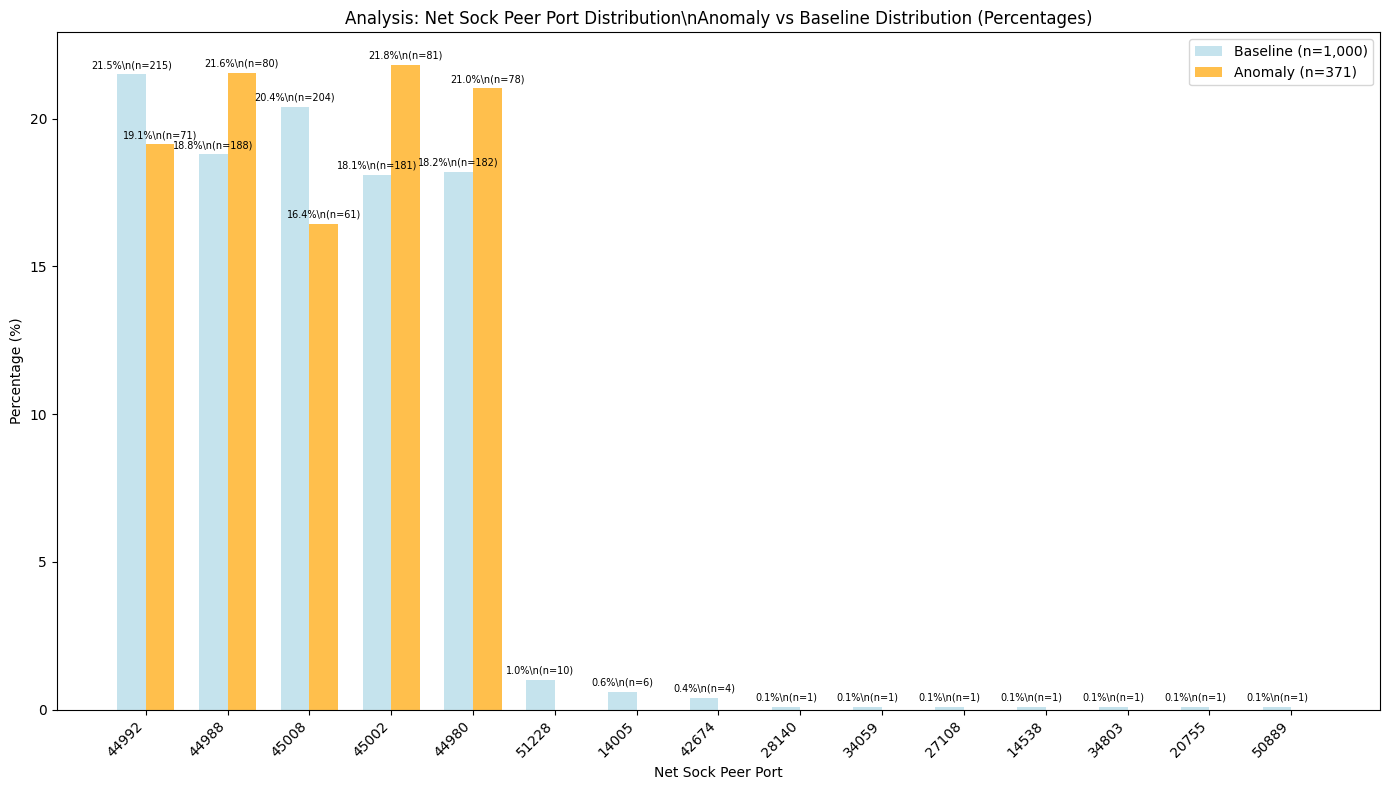

\n🔍 Net Sock Peer Port Analysis:
   📊 Total anomaly instances: 371
   📊 Total baseline instances: 1,000
   🚨 Values over-represented in anomaly group:
      • 45002: 21.8% of anomalies vs 18.1% of baseline (30.9% of this value is anomalous)
      • 44988: 21.6% of anomalies vs 18.8% of baseline (29.9% of this value is anomalous)
      • 44980: 21.0% of anomalies vs 18.2% of baseline (30.0% of this value is anomalous)
   🟢 Values over-represented in baseline group:
      • 51228: 1.0% of baseline vs 0.0% of anomalies (100.0% of this value is baseline)
      • 14005: 0.6% of baseline vs 0.0% of anomalies (100.0% of this value is baseline)
      • 42674: 0.4% of baseline vs 0.0% of anomalies (100.0% of this value is baseline)

📋 2. HTTP METHOD ANALYSIS


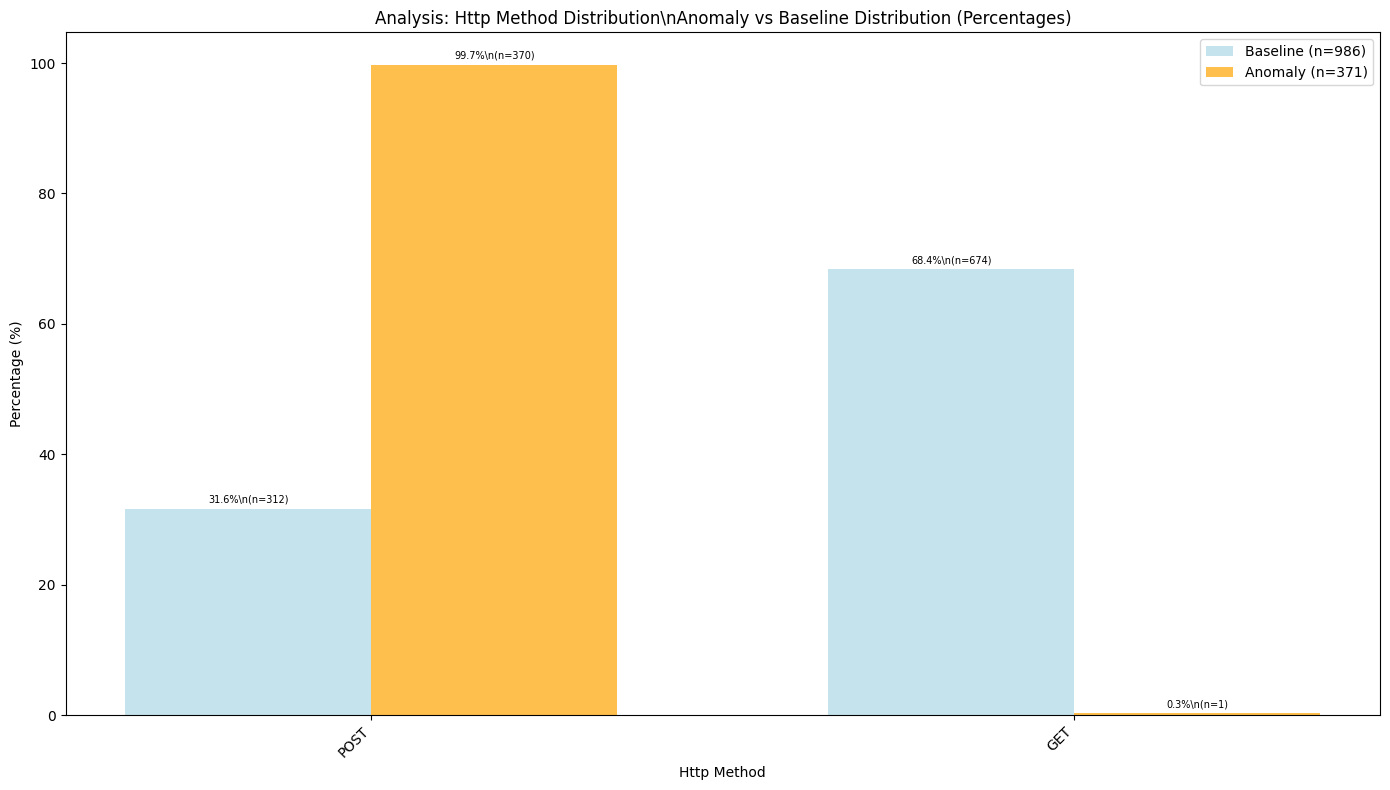

\n🔍 Http Method Analysis:
   📊 Total anomaly instances: 371
   📊 Total baseline instances: 986
   🚨 Values over-represented in anomaly group:
      • POST: 99.7% of anomalies vs 31.6% of baseline (54.3% of this value is anomalous)
   🟢 Values over-represented in baseline group:
      • GET: 68.4% of baseline vs 0.3% of anomalies (99.9% of this value is baseline)

📋 3. HTTP TARGET ANALYSIS
   📊 Found 23 unique values for Http Target. Showing top 20 by frequency.
   🔝 Using top 20 values (representing 1,354 total instances)


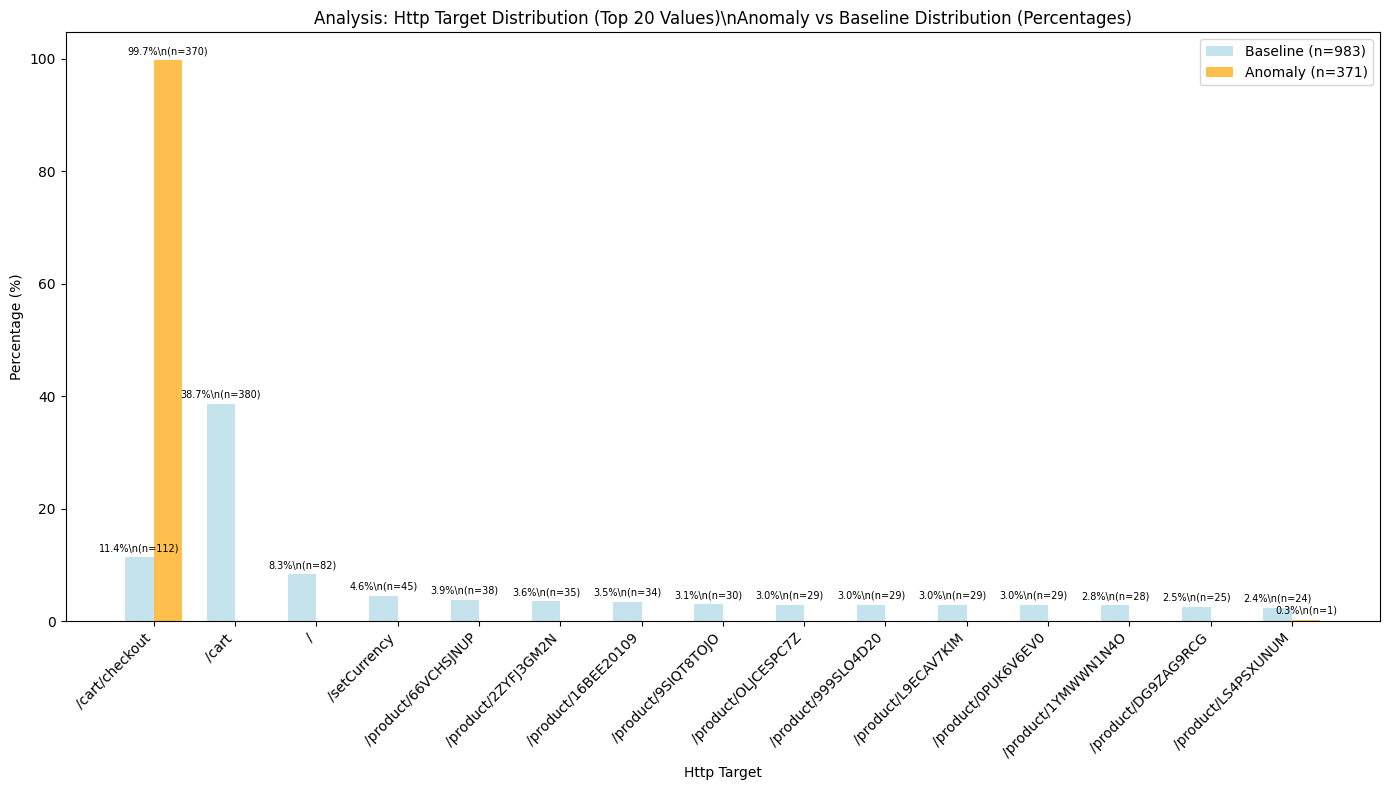

\n🔍 Http Target Analysis:
   📊 Total anomaly instances: 371
   📊 Total baseline instances: 983
   🚨 Values over-represented in anomaly group:
      • /cart/checkout: 99.7% of anomalies vs 11.4% of baseline (76.8% of this value is anomalous)
   🟢 Values over-represented in baseline group:
      • /cart: 38.7% of baseline vs 0.0% of anomalies (100.0% of this value is baseline)
      • /: 8.3% of baseline vs 0.0% of anomalies (100.0% of this value is baseline)
      • /setCurrency: 4.6% of baseline vs 0.0% of anomalies (100.0% of this value is baseline)

📋 4. HTTP STATUS CODE ANALYSIS


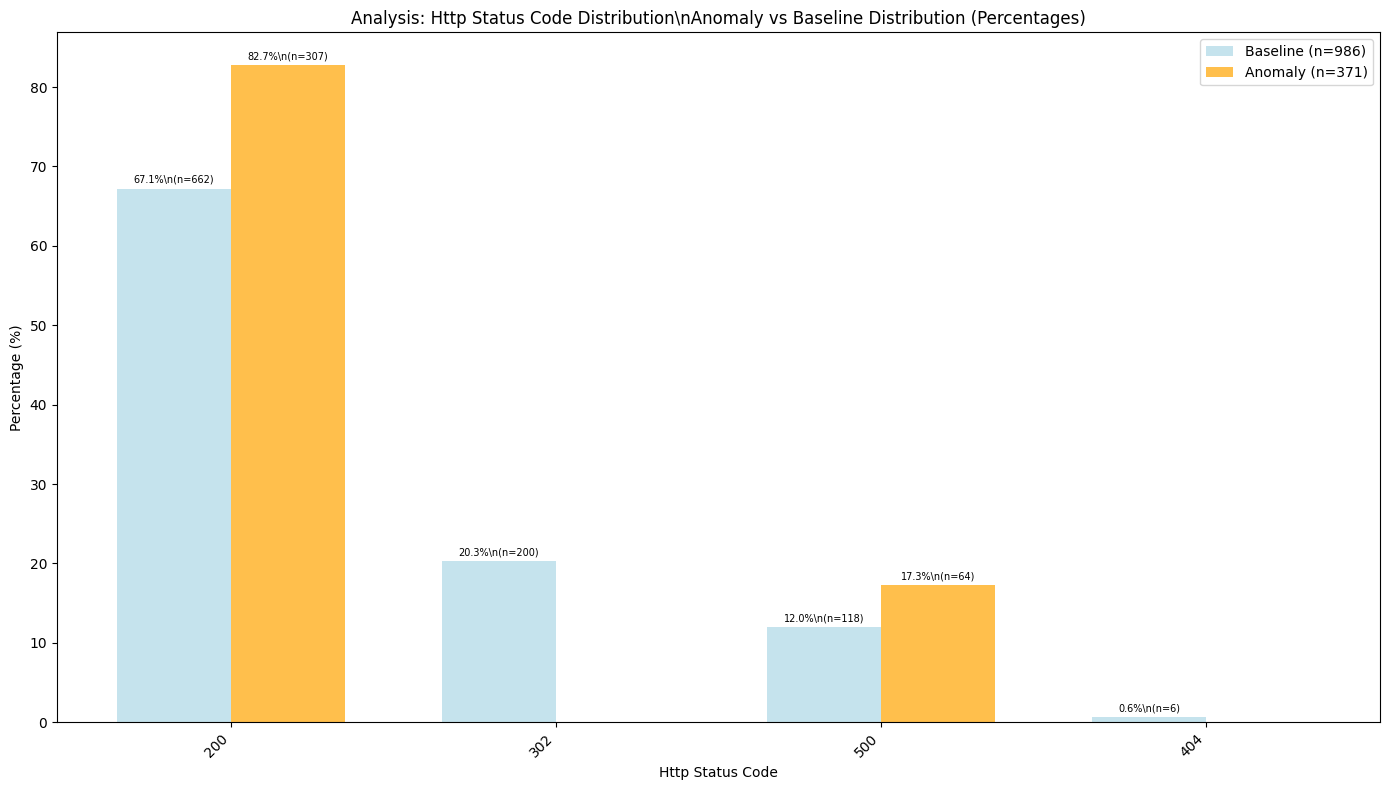

\n🔍 Http Status Code Analysis:
   📊 Total anomaly instances: 371
   📊 Total baseline instances: 986
   🚨 Values over-represented in anomaly group:
      • 200: 82.7% of anomalies vs 67.1% of baseline (31.7% of this value is anomalous)
      • 500: 17.3% of anomalies vs 12.0% of baseline (35.2% of this value is anomalous)
   🟢 Values over-represented in baseline group:
      • 302: 20.3% of baseline vs 0.0% of anomalies (100.0% of this value is baseline)
      • 404: 0.6% of baseline vs 0.0% of anomalies (100.0% of this value is baseline)

📋 5. HTTP ROUTE ANALYSIS


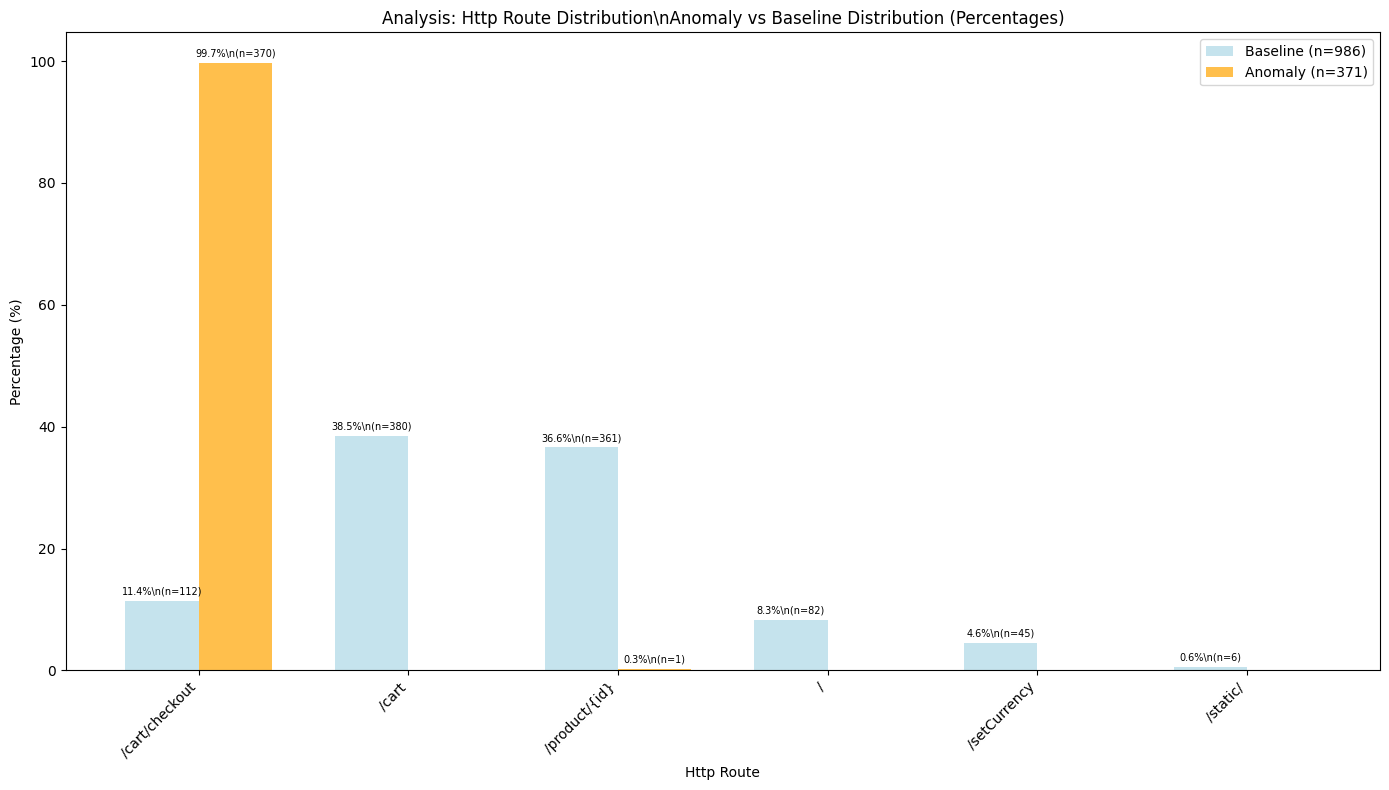

\n🔍 Http Route Analysis:
   📊 Total anomaly instances: 371
   📊 Total baseline instances: 986
   🚨 Values over-represented in anomaly group:
      • /cart/checkout: 99.7% of anomalies vs 11.4% of baseline (76.8% of this value is anomalous)
   🟢 Values over-represented in baseline group:
      • /cart: 38.5% of baseline vs 0.0% of anomalies (100.0% of this value is baseline)
      • /product/{id}: 36.6% of baseline vs 0.3% of anomalies (99.7% of this value is baseline)
      • /: 8.3% of baseline vs 0.0% of anomalies (100.0% of this value is baseline)

📋 6. APP USER ID ANALYSIS
   📊 Found 948 unique values for App User Id. Showing top 20 by frequency.
   🔝 Using top 20 values (representing 392 total instances)


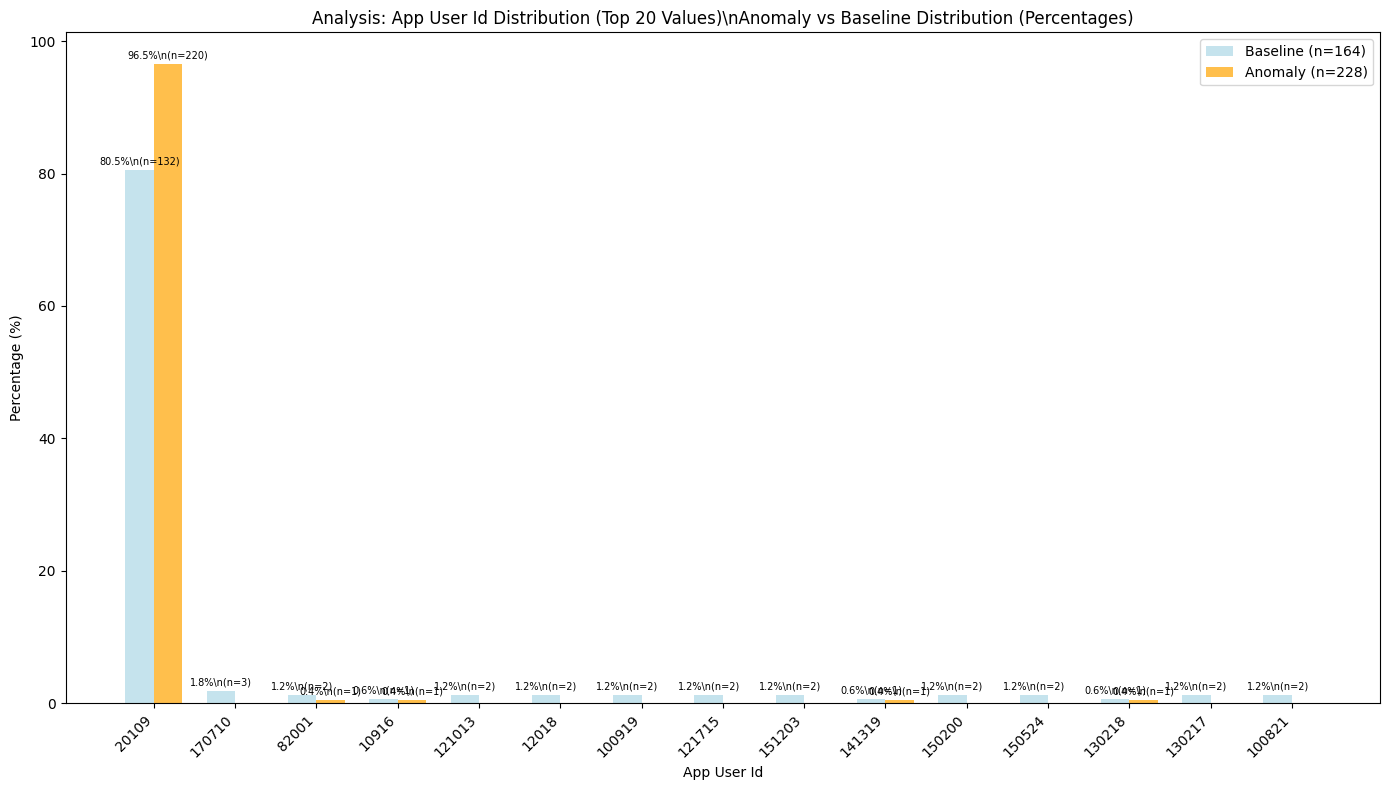

\n🔍 App User Id Analysis:
   📊 Total anomaly instances: 228
   📊 Total baseline instances: 164
   🚨 Values over-represented in anomaly group:
      • 20109: 96.5% of anomalies vs 80.5% of baseline (62.5% of this value is anomalous)
   🟢 Values over-represented in baseline group:
      • 170710: 1.8% of baseline vs 0.0% of anomalies (100.0% of this value is baseline)
      • 121013: 1.2% of baseline vs 0.0% of anomalies (100.0% of this value is baseline)
      • 12018: 1.2% of baseline vs 0.0% of anomalies (100.0% of this value is baseline)

📋 7. APP REQUEST ID ANALYSIS
   📊 Found 1351 unique values for App Request Id. Showing top 20 by frequency.
   🔝 Using top 20 values (representing 20 total instances)


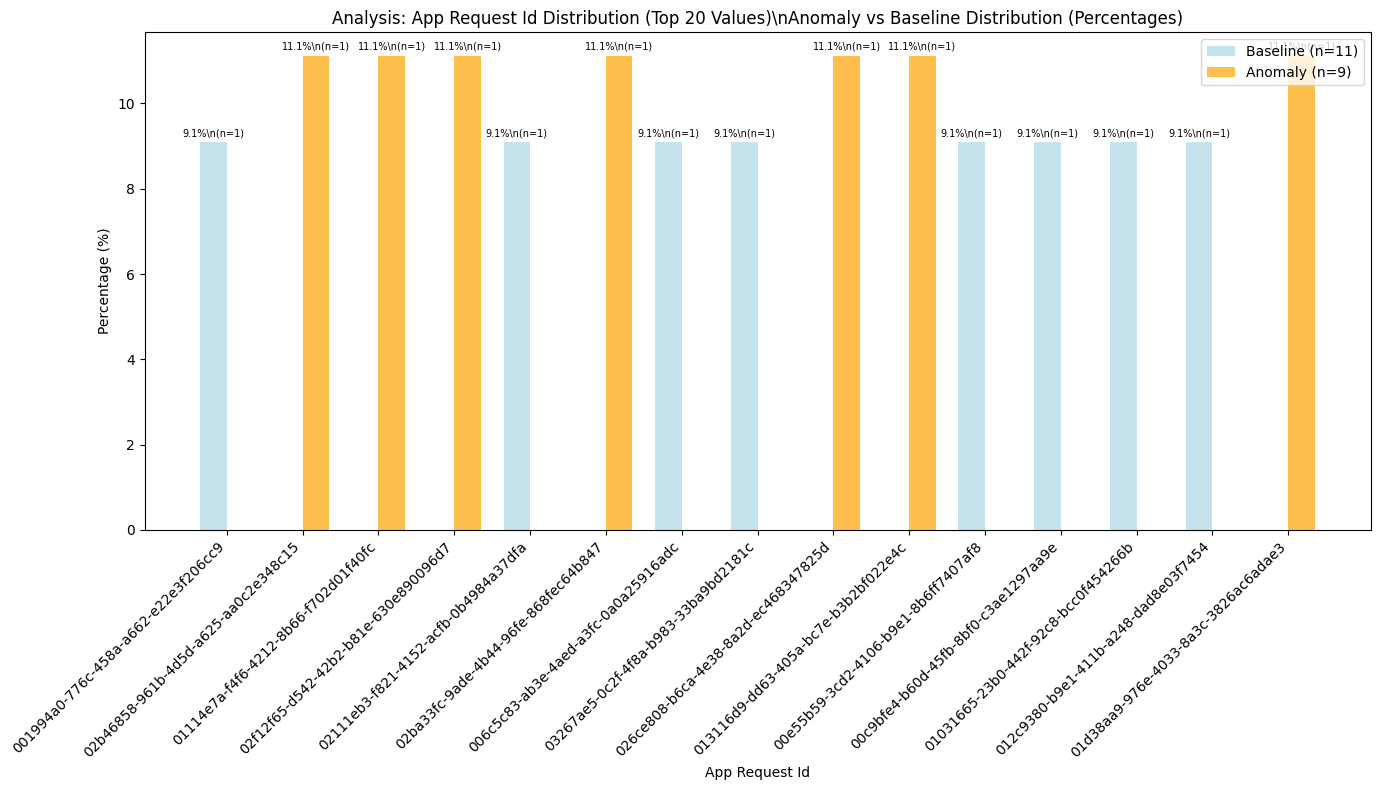

\n🔍 App Request Id Analysis:
   📊 Total anomaly instances: 9
   📊 Total baseline instances: 11
   🚨 Values over-represented in anomaly group:
      • 02b46858-961b-4d5d-a625-aa0c2e348c15: 11.1% of anomalies vs 0.0% of baseline (100.0% of this value is anomalous)
      • 01114e7a-f4f6-4212-8b66-f702d01f40fc: 11.1% of anomalies vs 0.0% of baseline (100.0% of this value is anomalous)
      • 02f12f65-d542-42b2-b81e-630e890096d7: 11.1% of anomalies vs 0.0% of baseline (100.0% of this value is anomalous)
      • 02ba33fc-9ade-4b44-96fe-868fec64b847: 11.1% of anomalies vs 0.0% of baseline (100.0% of this value is anomalous)
      • 026ce808-b6ca-4e38-8a2d-ec468347825d: 11.1% of anomalies vs 0.0% of baseline (100.0% of this value is anomalous)
      • 013116d9-dd63-405a-bc7e-b3b2bf022e4c: 11.1% of anomalies vs 0.0% of baseline (100.0% of this value is anomalous)
      • 01d38aa9-976e-4033-8a3c-3826ac6adae3: 11.1% of anomalies vs 0.0% of baseline (100.0% of this value is anomalous)
   🟢 Values

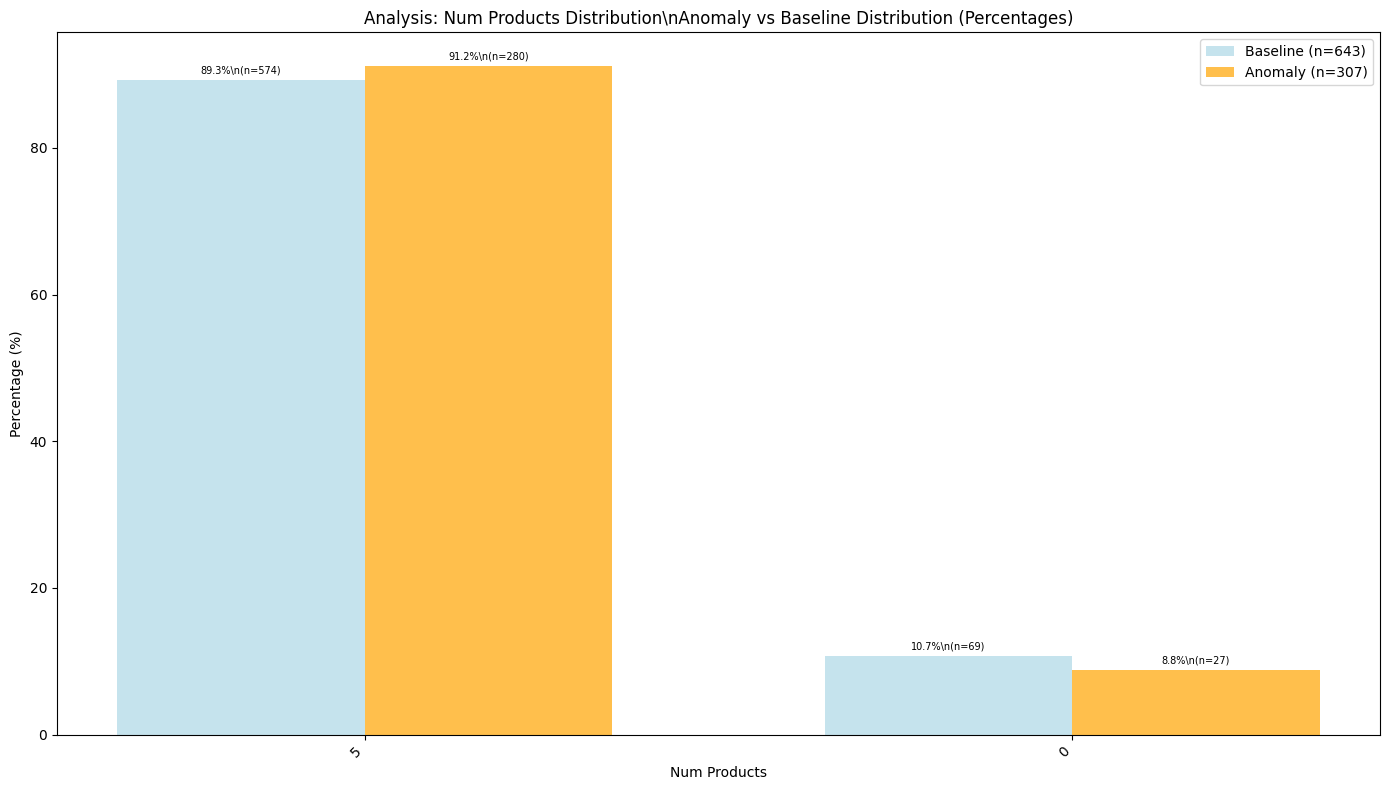

\n🔍 Num Products Analysis:
   📊 Total anomaly instances: 307
   📊 Total baseline instances: 643
   🚨 Values over-represented in anomaly group:
      • 5: 91.2% of anomalies vs 89.3% of baseline (32.8% of this value is anomalous)

📋 9. APP CART TOTAL ANALYSIS
   📊 Found 136 unique values for App Cart Total. Showing top 20 by frequency.
   🔝 Using top 20 values (representing 203 total instances)


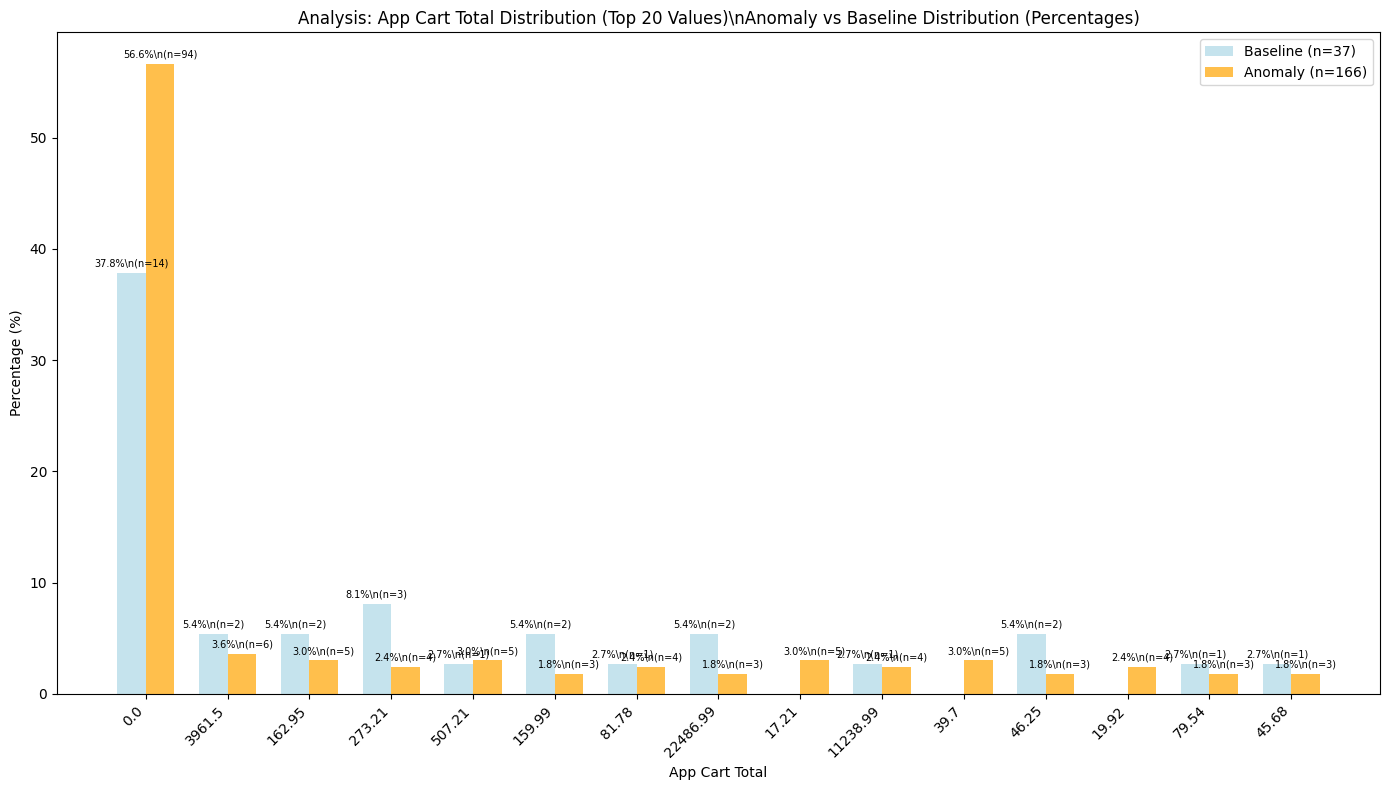

\n🔍 App Cart Total Analysis:
   📊 Total anomaly instances: 166
   📊 Total baseline instances: 37
   🚨 Values over-represented in anomaly group:
      • 0.0: 56.6% of anomalies vs 37.8% of baseline (87.0% of this value is anomalous)
      • 507.21: 3.0% of anomalies vs 2.7% of baseline (83.3% of this value is anomalous)
      • 17.21: 3.0% of anomalies vs 0.0% of baseline (100.0% of this value is anomalous)
      • 39.7: 3.0% of anomalies vs 0.0% of baseline (100.0% of this value is anomalous)
      • 19.92: 2.4% of anomalies vs 0.0% of baseline (100.0% of this value is anomalous)

✅ Attribute analysis completed!
   📊 Created 9 attribute comparison charts


In [75]:
result = create_attribute_paired_histograms(df_anomaly, df_baseline, actual_attr_columns)

In [ ]:
import os
import base64
from openai import AzureOpenAI
from azure.identity import DefaultAzureCredential, get_bearer_token_provider
import json
      
endpoint = "https://bubbleup.openai.azure.com"
deployment = "gpt-oss-120b"
      
# Initialize Azure OpenAI client with Entra ID authentication
token_provider = get_bearer_token_provider(
    DefaultAzureCredential(),
    "https://cognitiveservices.azure.com/.default"
)

client = AzureOpenAI(
    azure_endpoint=endpoint,
    azure_ad_token_provider=token_provider,
    api_version="2025-01-01-preview",
)

# Prepare the ranked_tables data for sending
ranked_tables_json = json.dumps(ranked_tables, default=str)

chat_prompt = [
    {
        "role": "system",
        "content": "You are a system that investigate an anomaly in a web application. You have access to telemetry data which user will share. The telemety data will be in a tabular format which will contain an Attribute_name along with the anomaly time period data and the baseline time period data where the system was working fine. You need to analyze the data for each attribute and provide insights on which attribute is most likely causing the issue. You should also provide insights on why you think that attribute is causing the issue. You should also provide insights on what other attributes might be related to the issue. Return the results in a markdown format which python's print function can render properly."
    },
    {
        "role": "user",
        "content": f"Here is the ranked attribute analysis data:\n{ranked_tables_json}"
    }
]

# Include speech result if speech is enabled
messages = chat_prompt

completion = client.chat.completions.create(
    model=deployment,
    messages=messages,
    max_tokens=2048,
    temperature=0.7,
    top_p=0.95,
    frequency_penalty=0,
    presence_penalty=0,
    stop=None,
    stream=False
)

display(Markdown(completion.choices[0].message.content))



In [ ]:
# Rank paired histograms by usefulness for identifying anomaly causes
# Criteria: anomaly-only values and large percentage differences between anomaly/baseline

def rank_histograms(df_anom, df_base, attributes=None, top_n=20):
    import math
    # Determine attributes list
    if attributes is None:
        # prefer parsed attr columns if available
        attrs = [c for c in df_anom.columns if c.startswith('attr_')]
        # include service/operation if present
        for c in ['ServiceName', 'OperationName']:
            if c in df_anom.columns and c not in attrs:
                attrs.insert(0, c)
    else:
        attrs = list(attributes)

    rows = []
    total_anom = len(df_anom)
    total_base = len(df_base)

    for attr in attrs:
        if attr not in df_anom.columns or attr not in df_base.columns:
            continue

        a = df_anom[attr]
        b = df_base[attr]
        # handle duplicate-column DataFrame cases
        if isinstance(a, pd.DataFrame):
            a = a.iloc[:, 0]
        if isinstance(b, pd.DataFrame):
            b = b.iloc[:, 0]

        a = a.dropna()
        b = b.dropna()
        if len(a) == 0 and len(b) == 0:
            continue

        a_counts = a.value_counts()
        b_counts = b.value_counts()
        a_total = len(a)
        b_total = len(b)

        # combined unique values
        vals = set(a_counts.index) | set(b_counts.index)
        if len(vals) == 0:
            continue

        anomaly_only = 0
        max_pct_diff = 0.0
        weighted_diff_sum = 0.0

        for v in vals:
            apct = (a_counts.get(v, 0) / a_total * 100) if a_total>0 else 0.0
            bpct = (b_counts.get(v, 0) / b_total * 100) if b_total>0 else 0.0
            if apct > 0 and bpct == 0:
                anomaly_only += 1
            diff = abs(apct - bpct)
            max_pct_diff = max(max_pct_diff, diff)
            # weight diffs by prevalence in anomaly group
            weighted_diff_sum += diff * (a_counts.get(v,0) / (a_total if a_total>0 else 1))

        # coverage = percent of anomaly rows that have any non-null value for this attr
        coverage_pct = (a_total / total_anom * 100) if total_anom>0 else 0.0

        # scoring - tuned to prefer anomaly-only values first, then big diffs, then coverage
        score = 0.0
        score += anomaly_only * 200.0            # big bonus per anomaly-only value
        score += min(200.0, max_pct_diff * 4.0)  # big differences up to cap
        score += min(60.0, coverage_pct * 0.6)   # modest bonus for coverage
        score += min(40.0, weighted_diff_sum*2.0) # reward consistently different attrs

        rows.append({
            'attribute': attr,
            'anomaly_only_values': anomaly_only,
            'max_pct_diff': round(max_pct_diff,1),
            'weighted_diff': round(weighted_diff_sum,2),
            'coverage_pct': round(coverage_pct,1),
            'unique_values': len(vals),
            'anomaly_count': a_total,
            'baseline_count': b_total,
            'score': round(score,1)
        })

    if not rows:
        print('No comparable attributes found to rank.')
        return pd.DataFrame()

    df_rank = pd.DataFrame(rows).sort_values('score', ascending=False).reset_index(drop=True)
    df_rank.index += 1

    display_cols = ['attribute','score','anomaly_only_values','max_pct_diff','coverage_pct','unique_values','anomaly_count','baseline_count']
    print('\nTop ranked histograms (higher score = more useful to find anomaly causes):\n')
    display(df_rank[display_cols].head(top_n))

    # visualize top 12
    top_vis = df_rank.head(12)
    plt.figure(figsize=(10,6))
    sns.barplot(x='score', y='attribute', data=top_vis, palette='viridis')
    plt.title('Ranked Paired-Histogram Usefulness for Anomaly Root-Cause')
    plt.xlabel('Usefulness Score')
    plt.ylabel('Attribute')
    plt.tight_layout()
    plt.show()

    return df_rank

def rank_attributes_comprehensive(df_anom, df_base):
    """
    Rank all attributes by their usefulness for identifying anomaly causes.
    
    Scoring methodology:
    - Anomaly-exclusive values: 100 points per value only in anomaly group
    - Large percentage differences: up to 80 points based on magnitude
    - Coverage: up to 30 points based on anomaly data coverage
    - Statistical significance: up to 20 points for clear patterns
    """
    
    # Get all available attributes
    service_ops = ['ServiceName', 'OperationName']
    attr_cols = [col for col in df_anom.columns if col.startswith('attr_')]
    all_attrs = service_ops + attr_cols
    
    rankings = []
    
    print("🔍 ANALYZING ALL PAIRED HISTOGRAMS FOR ANOMALY DETECTION USEFULNESS")
    print("=" * 70)
    
    for attr in all_attrs:
        if attr not in df_anom.columns or attr not in df_base.columns:
            continue
            
        # Handle potential duplicate columns (DataFrame vs Series)
        anom_series = df_anom[attr]
        base_series = df_base[attr]
        
        if isinstance(anom_series, pd.DataFrame):
            anom_series = anom_series.iloc[:, 0]
        if isinstance(base_series, pd.DataFrame):
            base_series = base_series.iloc[:, 0]
            
        # Clean data
        anom_clean = anom_series.dropna()
        base_clean = base_series.dropna()
        
        if len(anom_clean) == 0 or len(base_clean) == 0:
            continue
            
        # Get value distributions
        anom_counts = anom_clean.value_counts()
        base_counts = base_clean.value_counts()
        
        anom_total = len(anom_clean)
        base_total = len(base_clean)
        
        # Calculate percentages
        anom_pct = (anom_counts / anom_total * 100)
        base_pct = (base_counts / base_total * 100)
        
        # Get all unique values across both groups
        all_values = set(anom_counts.index) | set(base_counts.index)
        
        if len(all_values) == 0:
            continue
            
        # Initialize scoring components
        score = 0
        anom_exclusive = 0
        base_exclusive = 0
        max_pct_diff = 0
        significant_diffs = []
        
        # Analyze each value for anomaly detection utility
        for value in all_values:
            anom_pct_val = anom_pct.get(value, 0)
            base_pct_val = base_pct.get(value, 0)
            
            # CRITICAL: Values only in anomaly group (smoking guns!)
            if anom_pct_val > 0 and base_pct_val == 0:
                # Only consider as anomaly-exclusive if there aren't too many unique values
                # This prevents noise from high-cardinality attributes like request IDs
                if len(all_values) <= 10:  # Threshold for meaningful categorical data
                    anom_exclusive += 1
                    score += 100  # High score for anomaly-exclusive values
                    significant_diffs.append({
                    'value': str(value)[:50],  # truncate long values
                    'type': 'ANOMALY_ONLY',
                    'anom_pct': anom_pct_val,
                    'base_pct': base_pct_val,
                    'impact': 'CRITICAL'
                    })
                # Values only in baseline group (reverse indicators)
                elif anom_pct_val == 0 and base_pct_val > 0:
                    if len(all_values) <= 10:
                        base_exclusive += 1
                        score += 50  # Moderate score for baseline-exclusive values
                        significant_diffs.append({
                        'value': str(value)[:50],
                        'type': 'BASELINE_ONLY',
                        'anom_pct': anom_pct_val,
                        'base_pct': base_pct_val,
                        'impact': 'HIGH'
                        })
                # Large percentage differences (important patterns)
                else:
                    pct_diff = abs(anom_pct_val - base_pct_val)
                    max_pct_diff = max(max_pct_diff, pct_diff)
                    
                    if pct_diff > 5:  # Significant difference threshold
                        diff_score = min(80, pct_diff * 3)  # Up to 80 points
                        score += diff_score
                        
                        impact = 'HIGH' if pct_diff > 30 else 'MEDIUM' if pct_diff > 15 else 'LOW'
                        significant_diffs.append({
                            'value': str(value)[:50],
                            'type': 'LARGE_DIFF',
                            'anom_pct': anom_pct_val,
                            'base_pct': base_pct_val,
                            'diff': pct_diff,
                            'impact': impact
                        })
            
        # Coverage bonus: How much of anomaly data does this attribute explain?
        coverage = (len(anom_clean) / len(df_anom)) * 100
        coverage_score = min(30, coverage * 0.4)  # Up to 30 points
        score += coverage_score
        
        # Statistical significance bonus
        if len(all_values) > 1 and (anom_exclusive > 0 or max_pct_diff > 15):
            score += 20  # Bonus for clear, actionable patterns
        elif max_pct_diff > 8:
            score += 10  # Smaller bonus for moderate patterns
        
        # Create display name
        display_name = attr.replace('attr_', '').replace('_', ' ').title()
        if attr == 'ServiceName':
            display_name = 'Service Name'
        elif attr == 'OperationName':
            display_name = 'Operation Name'
            
        rankings.append({
            'attribute': attr,
            'display_name': display_name,
            'usefulness_score': round(score, 1),
            'anomaly_exclusive_values': anom_exclusive,
            'baseline_exclusive_values': base_exclusive,
            'max_percentage_difference': round(max_pct_diff, 1),
            'coverage_percent': round(coverage, 1),
            'total_unique_values': len(all_values),
            'anomaly_data_points': len(anom_clean),
            'baseline_data_points': len(base_clean),
            'key_differences': significant_diffs[:3]  # Top 3 most significant
        })
    
    # Sort by usefulness score (highest first)
    rankings.sort(key=lambda x: x['usefulness_score'], reverse=True)
    
    return rankings

def display_ranking_results_detailed(rankings):
    """Display comprehensive ranking results with actionable insights"""
    
    print("\n🏆 PAIRED HISTOGRAM USEFULNESS RANKING")
    print("=" * 80)
    print("📈 Ranked by effectiveness for identifying anomaly root causes")
    print("🎯 Higher scores = More useful for finding what's wrong")
    print()
    
    # Show top 12 most useful attributes
    for i, ranking in enumerate(rankings[:12], 1):
        print(f"#{i:2d}. {ranking['display_name']}")
        print(f"     🎯 Usefulness Score: {ranking['usefulness_score']:.1f}/230")
        
        # Key indicators that make this useful
        indicators = []
        if ranking['anomaly_exclusive_values'] > 0:
            indicators.append(f"🚨 {ranking['anomaly_exclusive_values']} ANOMALY-ONLY values")
        if ranking['max_percentage_difference'] > 40:
            indicators.append(f"📊 {ranking['max_percentage_difference']:.1f}% max difference")
        elif ranking['max_percentage_difference'] > 20:
            indicators.append(f"📈 {ranking['max_percentage_difference']:.1f}% max difference")
        elif ranking['max_percentage_difference'] > 10:
            indicators.append(f"📉 {ranking['max_percentage_difference']:.1f}% difference")
        
        if indicators:
            print(f"     {' | '.join(indicators)}")
        
        # Coverage and data details
        print(f"     📋 Coverage: {ranking['coverage_percent']:.1f}% of anomaly data | "
              f"Values: {ranking['total_unique_values']} | "
              f"Data: {ranking['anomaly_data_points']:,} anom, {ranking['baseline_data_points']:,} base")
        
        # Show most significant findings
        if ranking['key_differences']:
            print(f"     🔍 Key Findings:")
            for diff in ranking['key_differences']:
                if diff['type'] == 'ANOMALY_ONLY':
                    print(f"        • '{diff['value']}': ⚠️  ONLY in anomalies ({diff['anom_pct']:.1f}%)")
                else:
                    direction = "↗️" if diff['anom_pct'] > diff['base_pct'] else "↘️"
                    print(f"        • '{diff['value']}': {direction} {diff['anom_pct']:.1f}% anom vs {diff['base_pct']:.1f}% base")
        
        print()
    
    # Summary insights and recommendations
    print("\n💡 KEY INSIGHTS FOR ANOMALY INVESTIGATION:")
    print("-" * 50)
    
    top_5 = rankings[:5]
    critical_attrs = [r for r in rankings if r['anomaly_exclusive_values'] > 0]
    high_impact_attrs = [r for r in rankings if r['max_percentage_difference'] > 30]
    
    print(f"🥇 TOP 5 MOST USEFUL: {', '.join([r['display_name'] for r in top_5])}")
    
    if critical_attrs:
        print(f"\n🚨 CRITICAL INDICATORS ({len(critical_attrs)} attributes with anomaly-only values):")
        for attr in critical_attrs[:3]:
            print(f"   • {attr['display_name']}: {attr['anomaly_exclusive_values']} exclusive values")
    
    if high_impact_attrs:
        print(f"\n📊 HIGH IMPACT DIFFERENCES ({len(high_impact_attrs)} attributes with >30% differences):")
        for attr in high_impact_attrs[:3]:
            print(f"   • {attr['display_name']}: {attr['max_percentage_difference']:.1f}% max difference")
    
    # Actionable recommendations
    print(f"\n🎯 INVESTIGATION PRIORITY:")
    print(f"   1. Start with: {rankings[0]['display_name']} (Score: {rankings[0]['usefulness_score']:.1f})")
    if len(rankings) > 1:
        print(f"   2. Then examine: {rankings[1]['display_name']} (Score: {rankings[1]['usefulness_score']:.1f})")
    if len(rankings) > 2:
        print(f"   3. Also check: {rankings[2]['display_name']} (Score: {rankings[2]['usefulness_score']:.1f})")

def create_ranking_visualization_chart(rankings):
    """Create visual charts showing the ranking results"""
    
    # Prepare data for top 10 attributes
    top_10 = rankings[:10]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
    
    # Left plot: Overall usefulness scores with color coding
    names = [r['display_name'] for r in top_10]
    scores = [r['usefulness_score'] for r in top_10]
    
    # Color by score level (red=critical, orange=high, green=medium, blue=low)
    colors = []
    for s in scores:
        if s >= 180:
            colors.append('#d32f2f')  # Critical - red
        elif s >= 120:
            colors.append('#f57c00')  # High - orange  
        elif s >= 60:
            colors.append('#388e3c')  # Medium - green
        else:
            colors.append('#1976d2')  # Low - blue
    
    bars1 = ax1.barh(range(len(names)), scores, color=colors, alpha=0.8)
    ax1.set_yticks(range(len(names)))
    ax1.set_yticklabels(names)
    ax1.set_xlabel('Usefulness Score (Higher = More Useful)')
    ax1.set_title('🏆 Top 10 Most Useful Paired Histograms\nfor Anomaly Root Cause Analysis', 
                  fontsize=14, fontweight='bold')
    ax1.grid(axis='x', alpha=0.3)
    
    # Add score labels on bars
    for i, (bar, score) in enumerate(zip(bars1, scores)):
        ax1.text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2, 
                f'{score:.0f}', ha='left', va='center', fontweight='bold', fontsize=10)
    
    # Right plot: Score composition breakdown
    exclusive_scores = [r['anomaly_exclusive_values'] * 100 for r in top_10]  # 100 pts each
    diff_scores = [min(80, r['max_percentage_difference'] * 3) for r in top_10]  # up to 80 pts
    other_scores = [max(0, r['usefulness_score'] - ex - diff) 
                   for r, ex, diff in zip(top_10, exclusive_scores, diff_scores)]
    
    # Stacked horizontal bar chart
    bars2 = ax2.barh(range(len(names)), exclusive_scores, 
                     color='#d32f2f', alpha=0.8, label='Anomaly-Only Values (100 pts each)')
    bars3 = ax2.barh(range(len(names)), diff_scores, left=exclusive_scores,
                     color='#f57c00', alpha=0.8, label='Large Differences (up to 80 pts)')
    bars4 = ax2.barh(range(len(names)), other_scores, 
                     left=[ex + diff for ex, diff in zip(exclusive_scores, diff_scores)],
                     color='#388e3c', alpha=0.8, label='Coverage & Significance (up to 50 pts)')
    
    ax2.set_yticks(range(len(names)))
    ax2.set_yticklabels(names)
    ax2.set_xlabel('Score Breakdown')
    ax2.set_title('📊 What Makes Each Attribute Useful\n(Score Component Analysis)', 
                  fontsize=14, fontweight='bold')
    ax2.legend(loc='lower right', fontsize=9)
    ax2.grid(axis='x', alpha=0.3)
    
    # Invert y-axis to match ranking order (best at top)
    ax1.invert_yaxis()
    ax2.invert_yaxis()
    
    plt.tight_layout()
    plt.show()
    
    return fig

def create_ranked_bubble_up_histograms(df_anom, df_base, rankings, max_charts=15):
    """
    Create bubble-up histograms for attributes in order of their usefulness ranking.
    This ensures the most important anomaly indicators are shown first.
    """
    
    print("📊 CREATING RANKED BUBBLE-UP HISTOGRAMS")
    print("=" * 60)
    print(f"🎯 Generating charts for top {max_charts} most useful attributes")
    print(f"📈 Ordered by anomaly detection usefulness score")
    print()
    
    charts_created = 0
    
    for i, ranking in enumerate(rankings[:max_charts], 1):
        attr = ranking['attribute']
        display_name = ranking['display_name']
        score = ranking['usefulness_score']
        
        print(f"#{i:2d}. {display_name} (Score: {score:.1f})")
        
        # Get the data for this attribute
        if attr not in df_anom.columns or attr not in df_base.columns:
            print(f"     ❌ Attribute '{attr}' not found in data")
            continue
            
        # Handle potential duplicate columns
        anom_series = df_anom[attr]
        base_series = df_base[attr]
        
        if isinstance(anom_series, pd.DataFrame):
            anom_series = anom_series.iloc[:, 0]
        if isinstance(base_series, pd.DataFrame):
            base_series = base_series.iloc[:, 0]
            
        # Clean the data
        anom_clean = anom_series.dropna()
        base_clean = base_series.dropna()
        
        if len(anom_clean) == 0 or len(base_clean) == 0:
            print(f"     ⚠️  No data available for {display_name}")
            continue
            
        # Get value counts and percentages
        anom_counts = anom_clean.value_counts()
        base_counts = base_clean.value_counts()
        
        anom_total = len(anom_clean)
        base_total = len(base_clean)
        
        # Calculate percentages
        anom_pct = (anom_counts / anom_total * 100)
        base_pct = (base_counts / base_total * 100)
        
        # Get combined values, limit to top 20 for readability
        all_values = list(set(anom_counts.index) | set(base_counts.index))
        
        # For high-cardinality attributes, show top values by frequency
        if len(all_values) > 20:
            # Calculate total frequency for sorting
            total_freq = {}
            for val in all_values:
                total_freq[val] = anom_counts.get(val, 0) + base_counts.get(val, 0)
            
            # Get top 20 by frequency
            sorted_values = sorted(total_freq.items(), key=lambda x: x[1], reverse=True)
            all_values = [val for val, _ in sorted_values[:20]]
            print(f"     🔝 Showing top 20 values (out of {len(total_freq)} total)")
        
        # Create single chart with side-by-side bars
        fig, ax = plt.subplots(1, 1, figsize=(15, 8))
        
        # Prepare data for plotting
        plot_values = all_values[:20]  # Ensure we don't exceed chart limits
        anom_percentages = [anom_pct.get(val, 0) for val in plot_values]
        base_percentages = [base_pct.get(val, 0) for val in plot_values]
        
        # Create bar positions
        x_pos = np.arange(len(plot_values))
        width = 0.35
        
        # Plot both groups side-by-side
        bars1 = ax.bar(x_pos - width/2, anom_percentages, width, 
                      color='#d32f2f', alpha=0.8, label=f'Anomaly Group ({anom_total:,} points)')
        bars2 = ax.bar(x_pos + width/2, base_percentages, width,
                      color='#1976d2', alpha=0.8, label=f'Baseline Group ({base_total:,} points)')
        
        # Formatting
        ax.set_xlabel('Attribute Values', fontweight='bold')
        ax.set_ylabel('Percentage of Group', fontweight='bold')
        ax.set_title(f'Paired Comparison: {display_name}\n(Anomaly vs Baseline Distribution)', 
                    fontweight='bold', fontsize=14)
        ax.set_xticks(x_pos)
        ax.set_xticklabels([str(v)[:15] + '...' if len(str(v)) > 15 else str(v) 
                          for v in plot_values], rotation=45, ha='right')
        ax.grid(axis='y', alpha=0.3)
        legend = ax.legend(loc='upper right')
        for text in legend.get_texts():
            text.set_fontweight('bold')
        
        # Add percentage labels on bars
        for j, (bar1, bar2, ap, bp) in enumerate(zip(bars1, bars2, anom_percentages, base_percentages)):
            if ap > 0.5:  # Only label if percentage is significant
                ax.text(bar1.get_x() + bar1.get_width()/2, bar1.get_height() + max(max(anom_percentages), max(base_percentages)) * 0.01,
                       f'{ap:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')
            if bp > 0.5:
                ax.text(bar2.get_x() + bar2.get_width()/2, bar2.get_height() + max(max(anom_percentages), max(base_percentages)) * 0.01,
                       f'{bp:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')
        
        # Adjust layout
        plt.tight_layout()
        plt.show()

        # Add a small title for the table
        print(f"\033[1m\033[94m🔢 Value Distribution Table for {display_name}\033[0m")
        # Show the plotted data as a table below the chart
        table_data = pd.DataFrame({
            'Value': plot_values,
            'Anomaly %': anom_percentages,
            'Baseline %': base_percentages
        })
        display(table_data)

        # Add the value distribution table and display_name to a list for later use
        ranked_tables.append({'Attribute_name': display_name, 'table': table_data})
        
        # Print key insights for this attribute
        print_attribute_insights(anom_pct, base_pct, display_name, ranking)
        
        charts_created += 1
        print()
    
    print(f"✅ RANKED ANALYSIS COMPLETE")
    print(f"📊 Created {charts_created} charts ordered by usefulness")
    print(f"🎯 Focus on the top-ranked attributes for fastest anomaly resolution")
    
    return charts_created

def print_attribute_insights(anom_pct, base_pct, display_name, ranking):
    """Print key insights for an attribute based on the ranking analysis"""
    
    print(f"     🔍 Key Insights for {display_name}:")
    
    # Show anomaly-exclusive values
    if ranking['anomaly_exclusive_values'] > 0:
        exclusive_values = []
        for val in anom_pct.index:
            if anom_pct[val] > 0 and base_pct.get(val, 0) == 0:
                exclusive_values.append(f"'{val}' ({anom_pct[val]:.1f}%)")
        
        if exclusive_values:
            print(f"        🚨 ANOMALY-ONLY values: {', '.join(exclusive_values[:3])}")
    
    # Show large differences
    large_diffs = []
    for val in set(anom_pct.index) | set(base_pct.index):
        ap = anom_pct.get(val, 0)
        bp = base_pct.get(val, 0)
        diff = abs(ap - bp)
        if diff > 10:  # Significant difference
            direction = "higher" if ap > bp else "lower"
            large_diffs.append(f"'{val}': {diff:.1f}% {direction} in anomalies")
    
    if large_diffs:
        print(f"        📊 LARGE differences: {', '.join(large_diffs[:2])}")
    
    # Coverage and importance
    print(f"        📋 Coverage: {ranking['coverage_percent']:.1f}% | " +
          f"Usefulness Score: {ranking['usefulness_score']:.1f}")

In [ ]:
import os
import base64
from openai import AzureOpenAI
from azure.identity import DefaultAzureCredential, get_bearer_token_provider
import json

def display_ai_analysis(ranked_tables):
    endpoint = "https://bubbleup.openai.azure.com"
    deployment = "gpt-oss-120b"
        
    # Initialize Azure OpenAI client with Entra ID authentication
    token_provider = get_bearer_token_provider(
        DefaultAzureCredential(),
        "https://cognitiveservices.azure.com/.default"
    )

    client = AzureOpenAI(
        azure_endpoint=endpoint,
        azure_ad_token_provider=token_provider,
        api_version="2025-01-01-preview",
    )

    # Prepare the ranked_tables data for sending
    ranked_tables_json = json.dumps(ranked_tables, default=str)

    chat_prompt = [
        {
            "role": "system",
            "content": "You are a system that investigate an anomaly in a web application. You have access to telemetry data which user will share. The telemety data will be in a tabular format which will contain an Attribute_name along with the anomaly time period data and the baseline time period data where the system was working fine. You need to analyze the data for each attribute and provide insights on which attribute is most likely causing the issue. You should also provide insights on why you think that attribute is causing the issue. You should also provide insights on what other attributes might be related to the issue. Return the results in a markdown format which python's display function can render properly."
        },
        {
            "role": "user",
            "content": f"Here is the ranked attribute analysis data:\n{ranked_tables_json}"
        }
    ]

    # Include speech result if speech is enabled
    messages = chat_prompt

    completion = client.chat.completions.create(
        model=deployment,
        messages=messages,
        max_tokens=2048,
        temperature=0.7,
        top_p=0.95,
        frequency_penalty=0,
        presence_penalty=0,
        stop=None,
        stream=False
    )

    display(Markdown(completion.choices[0].message.content))


## 2. Status Code Anomaly Analysis

In [76]:

def create_chart(df, key):
    print(f"\n🎉 COMPLETE QUERY SUCCESS!")
    print(f"   📊 Retrieved: {len(df):,} spans (NO LIMITS)")
    print(f"   🏗️ Shape: {df.shape}")

    # Convert TimeGenerated to datetime and Pacific timezone
    df['TimeGenerated'] = pd.to_datetime(df['TimeGenerated'])

    
    # Check if already timezone-aware and convert appropriately
    if df['TimeGenerated'].dt.tz is None:
        # Not timezone-aware, assume UTC and localize first
        df['TimeGenerated_Pacific'] = df['TimeGenerated'].dt.tz_localize('UTC').dt.tz_convert(pacific_tz)
    else:
        # Already timezone-aware, convert directly
        df['TimeGenerated_Pacific'] = df['TimeGenerated'].dt.tz_convert(pacific_tz)

    # Check the ACTUAL time range in Pacific time
    time_min_complete = df['TimeGenerated_Pacific'].min()
    time_max_complete = df['TimeGenerated_Pacific'].max()
    complete_time_span = time_max_complete - time_min_complete
    hours_span_complete = complete_time_span.total_seconds() / 3600
    
    print(f"\n📅 COMPLETE time range (Pacific): {time_min_complete.strftime('%Y-%m-%d %H:%M:%S %Z')} to {time_max_complete.strftime('%Y-%m-%d %H:%M:%S %Z')}")
    print(f"⏱️ COMPLETE span: {hours_span_complete:.2f} hours")
    print(f"🔥 This should show the FULL 4+ hours!")
    
    # Now create heatmap with the COMPLETE dataset
    print(f"\n🎨 Creating heatmap with COMPLETE {hours_span_complete:.1f} hour dataset...")
    
    # Use appropriate time bins for the full range
    if hours_span_complete > 48:
        freq = '10T'  # 10-minute bins for 4+ hours
        print(f"🔧 Using 10-minute bins for {hours_span_complete:.1f} hour span")
    elif hours_span_complete > 24:
        freq = '5T'  # 5-minute bins
        print(f"🔧 Using 5-minute bins for {hours_span_complete:.1f} hour span")
    else:
        freq = '1T'   # 1-minute bins
        print(f"🔧 Using 1-minute bins for {hours_span_complete:.1f} hour span")

    # Create time bins for the COMPLETE range using Pacific time
    time_bins_complete = pd.date_range(start=time_min_complete, end=time_max_complete, freq=freq)
    print(f"📦 Created {len(time_bins_complete)} time bins for complete range")
    
    # Get unique values for the key
    unique_values = df[key].unique()
    num_unique = len(unique_values)

    print(f"📊 Analysis for '{key}' column:")
    print(f"   🔢 Found {num_unique:,} unique values")

    if num_unique <= 20:
        print(f"   📋 All unique values: {sorted(unique_values)}")
    else:
        print(f"   📋 Sample values: {sorted(unique_values[:10])}")
        print(f"   📊 Value range: {min(unique_values)} to {max(unique_values)}")

    # Get value counts for distribution analysis
    value_counts = df[key].value_counts()
    print(f"   📈 Top 10 most frequent values:")
    for val, count in value_counts.head(10).items():
        print(f"      {val}: {count:,} occurrences ({count/len(df)*100:.1f}%)")

    # Create a stacked bar chart showing key values over time
    if num_unique <= 50:  # Only create chart if reasonable number of categories
        # Bin the data by time for better visualization
        df['time_bin'] = pd.cut(df['TimeGenerated_Pacific'], bins=time_bins_complete, include_lowest=True)
        
        # Create pivot table for stacked bar chart
        pivot_data = df.groupby(['time_bin', key]).size().unstack(fill_value=0)
        
        # Create the stacked bar chart
        fig, ax = plt.subplots(figsize=(20, 8))
        
        # Plot stacked bars
        pivot_data.plot(kind='bar', stacked=True, ax=ax, width=0.8)
        
        # Customize the chart
        ax.set_title(f'Distribution of {key} Values Over Time\n'
                     f'Time Range: {time_min_complete.strftime("%H:%M")} - {time_max_complete.strftime("%H:%M")} PT', 
                     fontsize=16, pad=20)
        ax.set_xlabel('Time (Pacific)', fontsize=14)
        ax.set_ylabel('Count of Spans', fontsize=14)

        # Format time labels
        label_freq = max(1, len(time_bins_complete)//12)  # Show ~12 labels
        time_labels_complete = [t.strftime('%H:%M') for t in time_bins_complete[::label_freq]]
        plt.xticks(range(0, len(time_bins_complete), label_freq), time_labels_complete, rotation=45)
    
        
        # Add legend
        if num_unique <= 10:
            ax.legend(title=key, bbox_to_anchor=(1.05, 1), loc='upper left')
        else:
            ax.legend(title=f'{key} (top values)', bbox_to_anchor=(1.05, 1), loc='upper left', 
                     ncol=max(1, num_unique//15))
        
        plt.tight_layout()
        plt.show()
        
        print(f"✅ Stacked bar chart created for {key}")
        print(f"   📊 Shows distribution of {num_unique} unique values across {len(time_bins_complete)} time intervals")
        
    else:
        print(f"⚠️ Too many unique values ({num_unique}) for meaningful visualization")
        print(f"   💡 Consider filtering to top values or using a different approach")
        
        # Show top 10 values in a simple bar chart instead
        top_values = value_counts.head(10)
        
        fig, ax = plt.subplots(figsize=(12, 6))
        top_values.plot(kind='bar', ax=ax)
        ax.set_title(f'Top 10 Most Frequent {key} Values', fontsize=16)
        ax.set_xlabel(key, fontsize=14)
        ax.set_ylabel('Count', fontsize=14)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
        
        print(f"✅ Top 10 values bar chart created for {key}")

### Iniial Query and Visualization

   🌊 Pacific time range: 2025-09-15 14:00:00 PDT to 2025-09-15 20:00:00 PDT
   🌍 UTC time range: 2025-09-15 21:00:00 UTC to 2025-09-16 03:00:00 UTC
   🕒 Querying from 2025-09-15 21:00:00 to 2025-09-16 03:00:00
📊 Querying 09/15 21:00 to 09/16 03:00...
🔍 Query details:
   • Table: OTelSpans
   • Time range: 6.00 hours
   • Limit: 500,000 rows
   • Filters: | where isnotempty(ServiceName) and StatusCode != '' | summarize count() by bin(TimeGenerated, 1m), ServiceName, Name, Attributes=tostring(Attributes), DurationMs, Success, StatusCode
   • Columns: TimeGenerated, DurationMs, ServiceName, Name, Attributes, StatusCode, Success
   • KQL Query:
      1: OTelSpans
      2:         | where TimeGenerated >= datetime('2025-09-15T21:00:00+00:00')
      3:         | where TimeGenerated < datetime('2025-09-16T03:00:00+00:00')
      4:         | where isnotempty(ServiceName) and StatusCode != '' | summarize count() by bin(TimeGenerated, 1m), ServiceName, Name, Attributes=tostring(Attributes), Dura

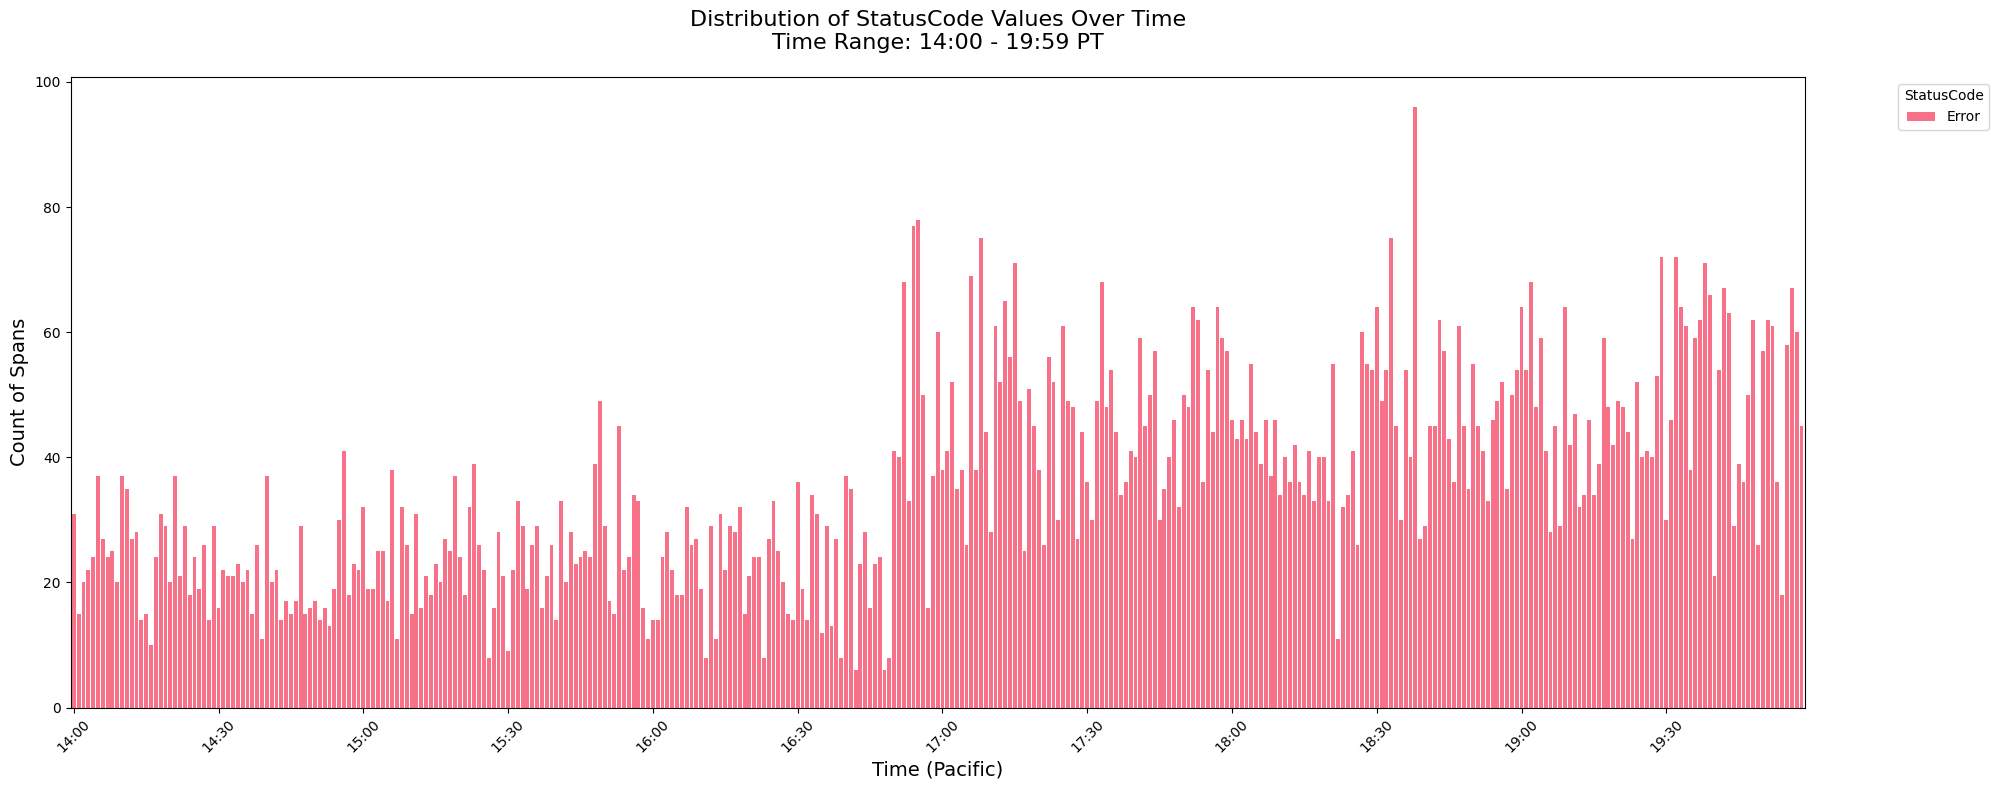

✅ Stacked bar chart created for StatusCode
   📊 Shows distribution of 1 unique values across 360 time intervals


In [77]:

efficient_columns=['TimeGenerated', 'Name', 'ServiceName', 'DurationMs', 'StatusCode', 'Success', 'TraceId', 'SpanId', 'ParentSpanId', 'Attributes']
min_columns=['TimeGenerated', 'DurationMs']
table_name='OTelSpans'
start_ago_hours=48
end_ago_hours=0
additional_filters="| where isnotempty(ServiceName) and StatusCode != '' | summarize count() by bin(TimeGenerated, 1m), ServiceName, Name, Attributes=tostring(Attributes), DurationMs, Success, StatusCode"
projection_columns=['TimeGenerated', 'DurationMs', 'ServiceName', 'Name', 'Attributes', 'StatusCode', 'Success']
max_total_rows=None  # NO LIMIT - get ALL data!

# Calculate time range
# end_time = datetime.now(timezone.utc) - timedelta(hours=end_ago_hours)
# start_time = datetime.now(timezone.utc) - timedelta(hours=start_ago_hours)

# Set specific Pacific time range: 09/15 20:30 to 09/16 06:30 Pacific
pacific_start = pacific_tz.localize(datetime(2025, 9, 15, 14, 0, 0))
pacific_end = pacific_tz.localize(datetime(2025, 9, 15, 20, 00, 0))

# Convert to UTC for the query
start_time = pacific_start.astimezone(timezone.utc)
end_time = pacific_end.astimezone(timezone.utc)

print(f"   🌊 Pacific time range: {pacific_start.strftime('%Y-%m-%d %H:%M:%S %Z')} to {pacific_end.strftime('%Y-%m-%d %H:%M:%S %Z')}")
print(f"   🌍 UTC time range: {start_time.strftime('%Y-%m-%d %H:%M:%S %Z')} to {end_time.strftime('%Y-%m-%d %H:%M:%S %Z')}")

print(f"   🕒 Querying from {start_time.strftime('%Y-%m-%d %H:%M:%S')} to {end_time.strftime('%Y-%m-%d %H:%M:%S')}")

# Generate time batches
df = queryOTel(table_name, start_time, end_time, additional_filters, projection_columns)
print(df.head())

if not df.empty:
    create_chart(df, 'StatusCode')
else:
    print(f"\n⚠️ Complete query returned empty results")

In [78]:
df = parse_attributes_to_columns(df).copy()

🔧 PARSING ATTRIBUTES JSON INTO SEPARATE COLUMNS
📊 Working with dataset: 12,742 spans
📋 Current columns: ['TimeGenerated', 'DurationMs', 'ServiceName', 'Name', 'Attributes', 'StatusCode', 'Success', 'TimeGenerated_Pacific', 'time_bin']
✅ Found 'Attributes' column

🔍 ANALYZING ATTRIBUTES COLUMN:
📝 Sample attributes:
   1. {"net.peer.port":"44598","rpc.service":"msdemo.RecommendationService","rpc.method":"ListRecommendati...
   2. {"db.statement":"SELECT * FROM products WHERE category IN (?)","db.name":"recommendation"}
   3. {"net.sock.peer.addr":"10.244.2.171","net.sock.peer.port":44980,"http.method":"GET","http.target":"/...
   4. {"rpc.service":"msdemo.RecommendationService","rpc.method":"ListRecommendations","rpc.system":"grpc"...
   5. {"net.peer.port":"44598","rpc.service":"msdemo.RecommendationService","rpc.method":"ListRecommendati...

🔄 Parsing 12,742 attribute entries...
   📈 Processed 0 / 12,742 entries (0.0%)
   ✅ Completed parsing all 12,742 entries

📊 CREATING EXPANDED ATTR

### Choose Anomaly Window

In [79]:
# Define the anomaly time window starting from 9/15 at 16:00 Pacific time
print("🔍 DEFINING ANOMALY CRITERIA FOR INCIDENT INVESTIGATION")
print("=" * 60)

# Anomaly time period: Starting from 9/15 at 16:00 Pacific time onwards
print(f"🕐 Anomaly Time Window: Starting from 9/15 at 16:00 Pacific Time onwards")
print(f"📅 This captures the full incident period from when it began")

# Function to check if a time falls within the anomaly window
def is_in_status_code_anomaly_time_window(timestamp):
    """
    Check if timestamp is in the anomaly window (9/15 16:00 PT onwards)
    """
    # Define the start of the anomaly period in Pacific time
    anomaly_start = pd.Timestamp('2025-09-15 16:00:00', tz=pacific_tz)
    
    # Ensure the input timestamp is timezone-aware
    if timestamp.tz is None:
        # Assume UTC if no timezone
        timestamp = timestamp.tz_localize('UTC').tz_convert(pacific_tz)
    elif timestamp.tz != pacific_tz:
        # Convert to Pacific time
        timestamp = timestamp.tz_convert(pacific_tz)
    
    # Return True if timestamp is at or after the anomaly start time
    return timestamp >= anomaly_start

df_anomaly, df_baseline = segment_anomaly_baseline(df, is_in_status_code_anomaly_time_window, anomaly_duration_min_ms=0, anomaly_duration_max_ms=4712000000)

🔍 DEFINING ANOMALY CRITERIA FOR INCIDENT INVESTIGATION
🕐 Anomaly Time Window: Starting from 9/15 at 16:00 Pacific Time onwards
📅 This captures the full incident period from when it began
📊 SEGMENTING DATA: ANOMALY vs BASELINE
✅ Processing 12,742 spans

🎯 Applying anomaly criteria...
   ⏱️ Duration range: 0.0 - 4712000.0 seconds

🎯 SAMPLING: Anomaly dataset sampled from 9,943 to 1,000 traces
🎯 SAMPLING: Baseline dataset sampled from 2,799 to 1,000 traces

📈 DATA SEGMENTATION RESULTS:
   🔴 Anomaly traces: 1,000 (7.8%)
   🟢 Baseline traces: 1,000 (7.8%)
   📊 Total traces: 12,742

🔍 ANOMALY GROUP CHARACTERISTICS:
   ⏱️ Duration range: 0.2 - 809.8 seconds
   🕐 Time range: 16:01 - 19:59 PT
   🏗️ Unique services: 4
   📝 Unique operations: 10

🔍 BASELINE GROUP CHARACTERISTICS:
   ⏱️ Duration range: 0.1 - 544.0 seconds
   🕐 Time range: 14:00 - 15:59 PT
   🏗️ Unique services: 2
   📝 Unique operations: 6

✅ Data successfully segmented for analysis!


### Generate Analysis Charts

#### General Dimensions Analysis

\n🎨 Creating paired histograms...
📊 Data available: 1000 anomaly traces, 1000 baseline traces
\n📋 1. SERVICE NAME ANALYSIS


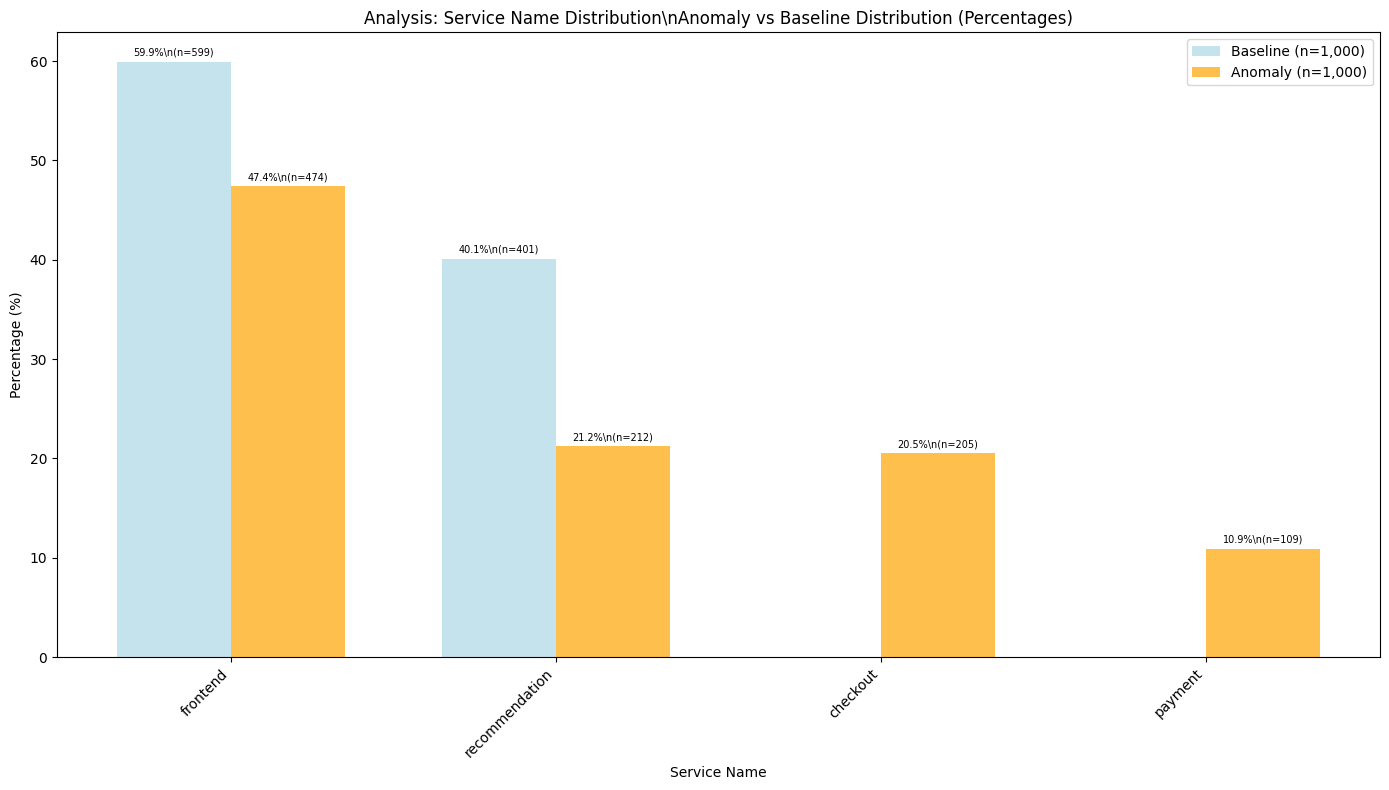

\n🔍 Service Name Analysis:
   📊 Total anomaly instances: 1,000
   📊 Total baseline instances: 1,000
   🚨 Values over-represented in anomaly group:
      • checkout: 20.5% of anomalies vs 0.0% of baseline (100.0% of this value is anomalous)
      • payment: 10.9% of anomalies vs 0.0% of baseline (100.0% of this value is anomalous)
\n📋 2. OPERATION NAME ANALYSIS


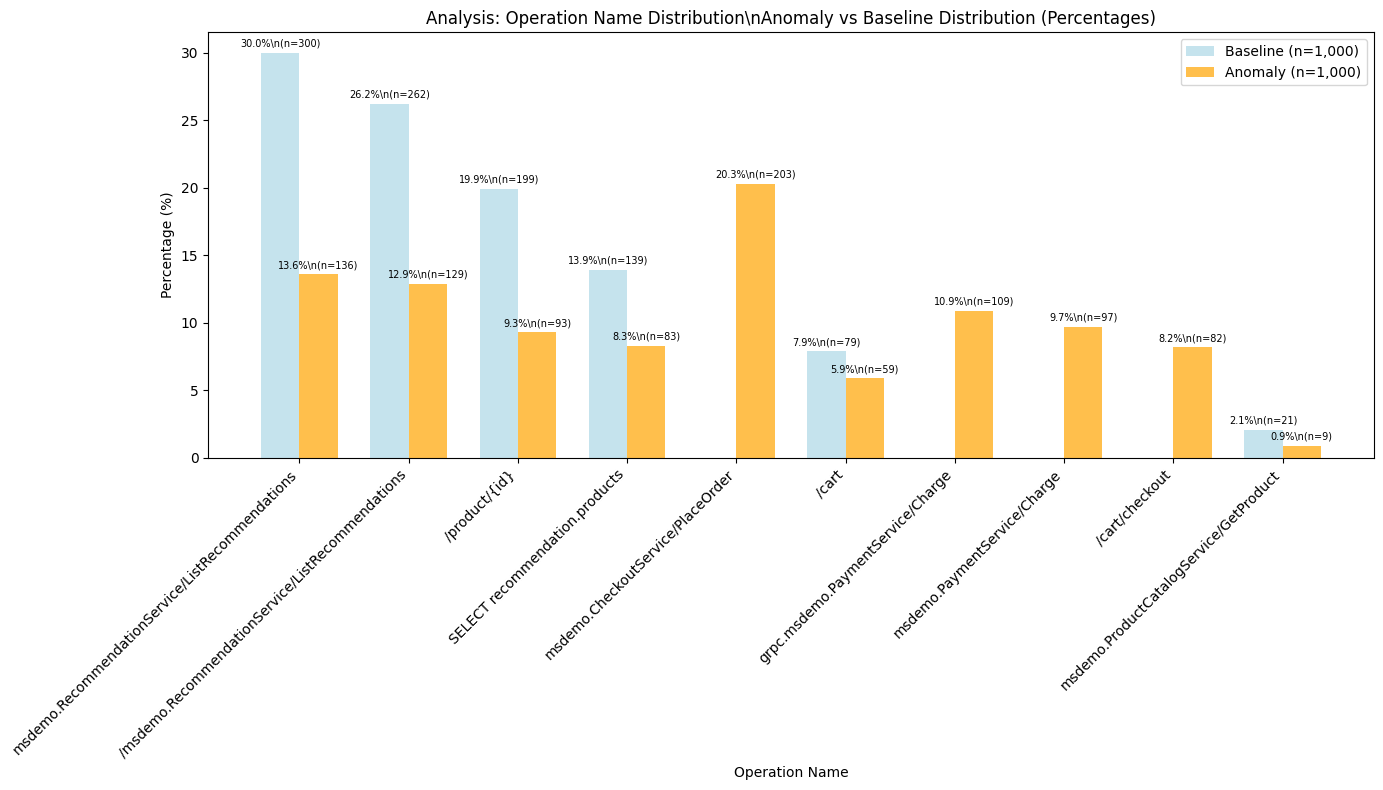

\n🔍 Operation Name Analysis:
   📊 Total anomaly instances: 1,000
   📊 Total baseline instances: 1,000
   🚨 Values over-represented in anomaly group:
      • msdemo.CheckoutService/PlaceOrder: 20.3% of anomalies vs 0.0% of baseline (100.0% of this value is anomalous)
      • grpc.msdemo.PaymentService/Charge: 10.9% of anomalies vs 0.0% of baseline (100.0% of this value is anomalous)
      • msdemo.PaymentService/Charge: 9.7% of anomalies vs 0.0% of baseline (100.0% of this value is anomalous)
      • /cart/checkout: 8.2% of anomalies vs 0.0% of baseline (100.0% of this value is anomalous)
\n📋 3. STATUS CODE ANALYSIS


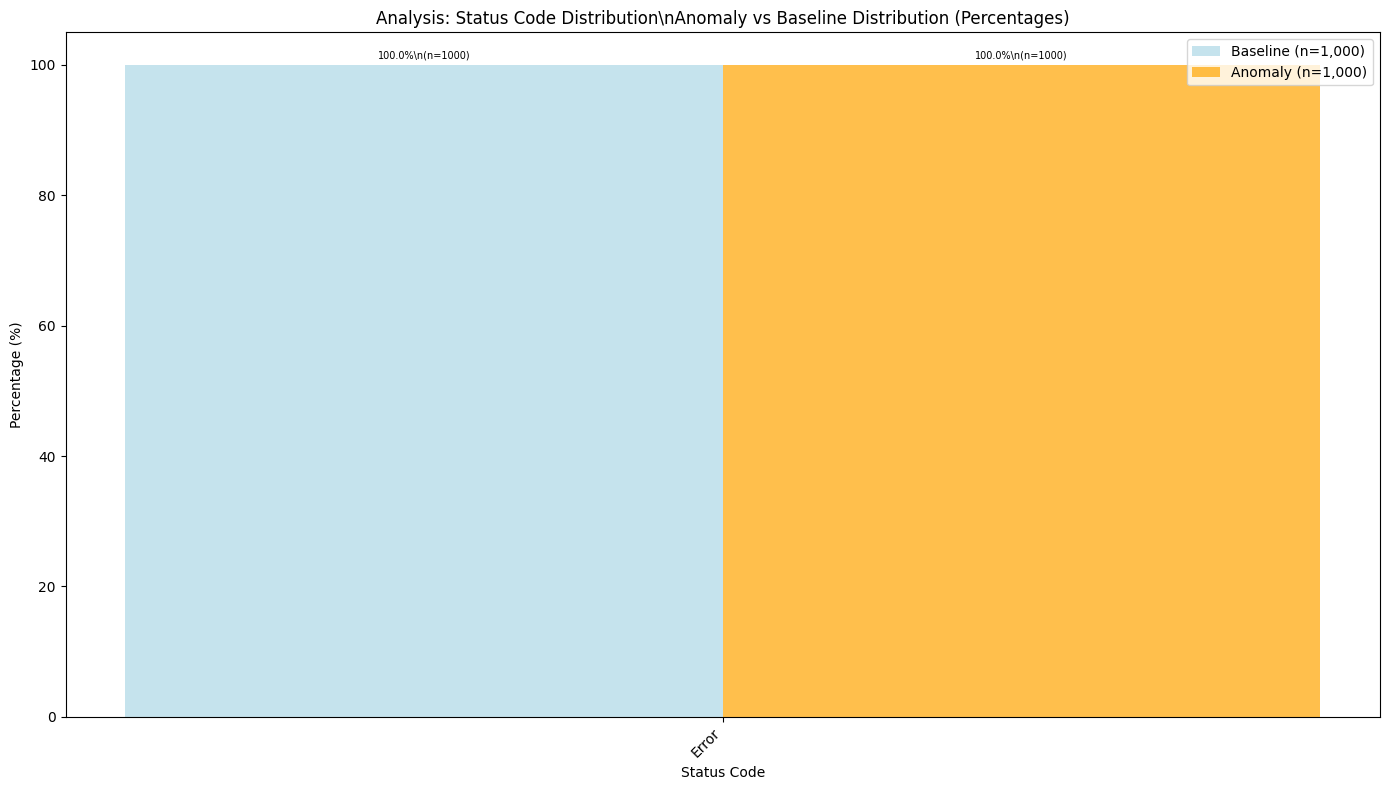

\n🔍 Status Code Analysis:
   📊 Total anomaly instances: 1,000
   📊 Total baseline instances: 1,000
\n📋 4. SUCCESS FLAG ANALYSIS


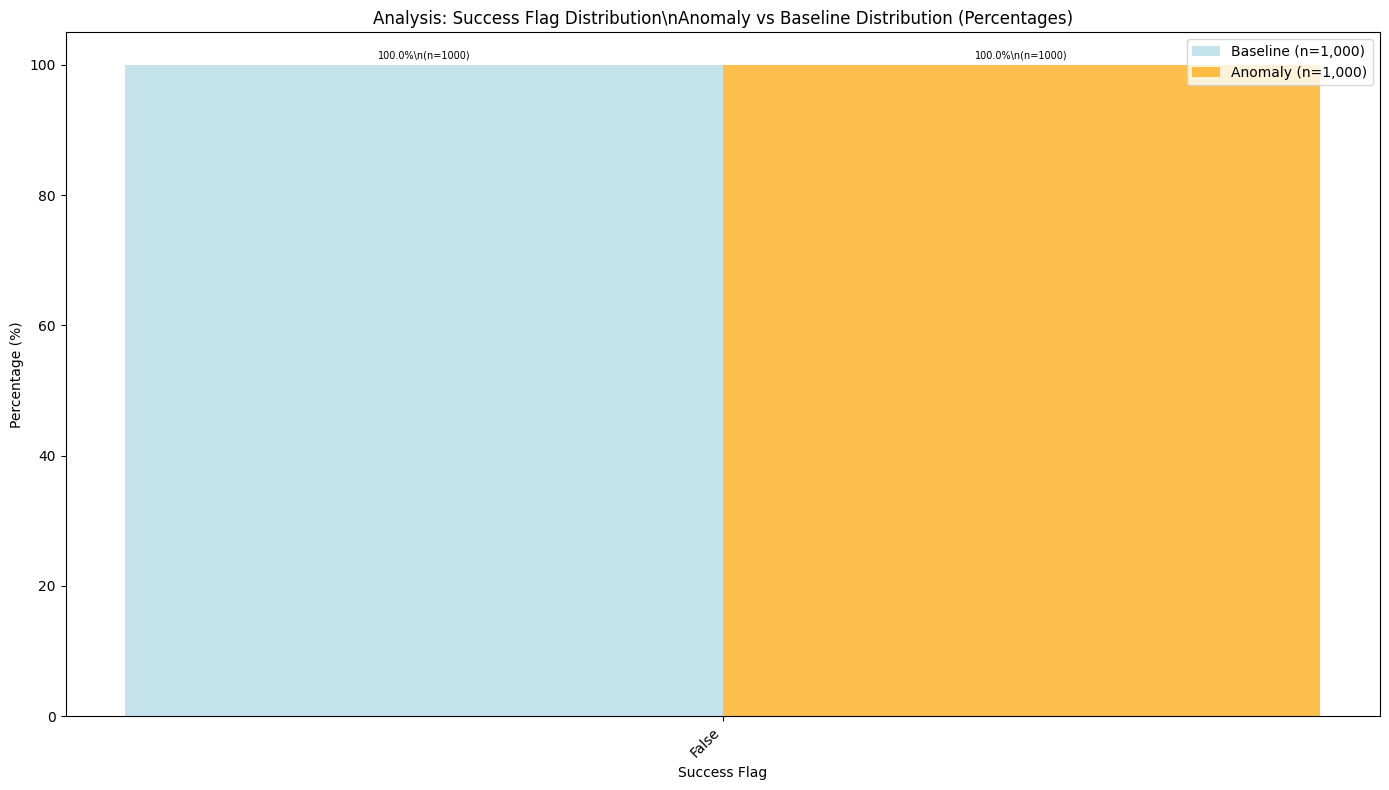

\n🔍 Success Flag Analysis:
   📊 Total anomaly instances: 1,000
   📊 Total baseline instances: 1,000
\n✅ Paired histograms completed!


In [80]:

# Now creating paired histograms for each dimension
print(f"\\n🎨 Creating paired histograms...")
print(f"📊 Data available: {len(df_anomaly)} anomaly traces, {len(df_baseline)} baseline traces")

if len(df_anomaly) > 0 and len(df_baseline) > 0:
    
    # 1. SERVICE NAME Analysis
    print(f"\\n📋 1. SERVICE NAME ANALYSIS")
    create_anomaly_histogram(
        'Service Name',
        df_anomaly['ServiceName'].fillna('NULL'),
        df_baseline['ServiceName'].fillna('NULL'),
        'Service Name Distribution'
    )
    
    # 2. OPERATION NAME Analysis (limit to top 10 for readability)
    print(f"\\n📋 2. OPERATION NAME ANALYSIS")
    create_anomaly_histogram(
        'Operation Name',
        df_anomaly['Name'].fillna('NULL'),
        df_baseline['Name'].fillna('NULL'),
        'Operation Name Distribution',
        max_categories=10
    )
    
    # 3. STATUS CODE Analysis
    if 'StatusCode' in df_anomaly.columns:
        print(f"\\n📋 3. STATUS CODE ANALYSIS")
        create_anomaly_histogram(
            'Status Code',
            df_anomaly['StatusCode'].fillna('NULL'),
            df_baseline['StatusCode'].fillna('NULL'),
            'Status Code Distribution'
        )
    
    # 4. SUCCESS FLAG Analysis
    if 'Success' in df_anomaly.columns:
        print(f"\\n📋 4. SUCCESS FLAG ANALYSIS")
        create_anomaly_histogram(
            'Success Flag',
            df_anomaly['Success'].fillna('NULL'),
            df_baseline['Success'].fillna('NULL'),
            'Success Flag Distribution'
        )

    print(f"\\n✅ Paired histograms completed!")
    
else:
    print(f"⚠️ Insufficient data for histogram analysis")
    print(f"   Anomaly traces: {len(df_anomaly) if 'df_anomaly' in locals() else 0}")
    print(f"   Baseline traces: {len(df_baseline) if 'df_baseline' in locals() else 0}")

#### Attributes Analysis

🔍 ANALYZING ATTRIBUTE COLUMNS
📊 Found 30 attribute columns (30 unique)

📈 ATTRIBUTE COVERAGE ANALYSIS:
   Attribute                           | Anomaly Cov  | Baseline Cov  | A Unique  | B Unique  | Total Values
   ----------------------------------- | ------------ | ------------- | --------- | --------- | ------------
   rpc_service                         |      68.3% |       58.3% |         4 |         2 |        1,266
   rpc_method                          |      68.3% |       58.3% |         4 |         2 |        1,266
   rpc_system                          |      68.3% |       58.3% |         1 |         1 |        1,266
   rpc_grpc_status_code                |      68.3% |       58.3% |         3 |         3 |        1,266
   net_sock_peer_addr                  |      57.1% |       59.9% |         5 |         3 |        1,170
   net_sock_peer_port                  |      57.1% |       59.9% |         9 |         7 |        1,170
   app_user_id                         |      34.

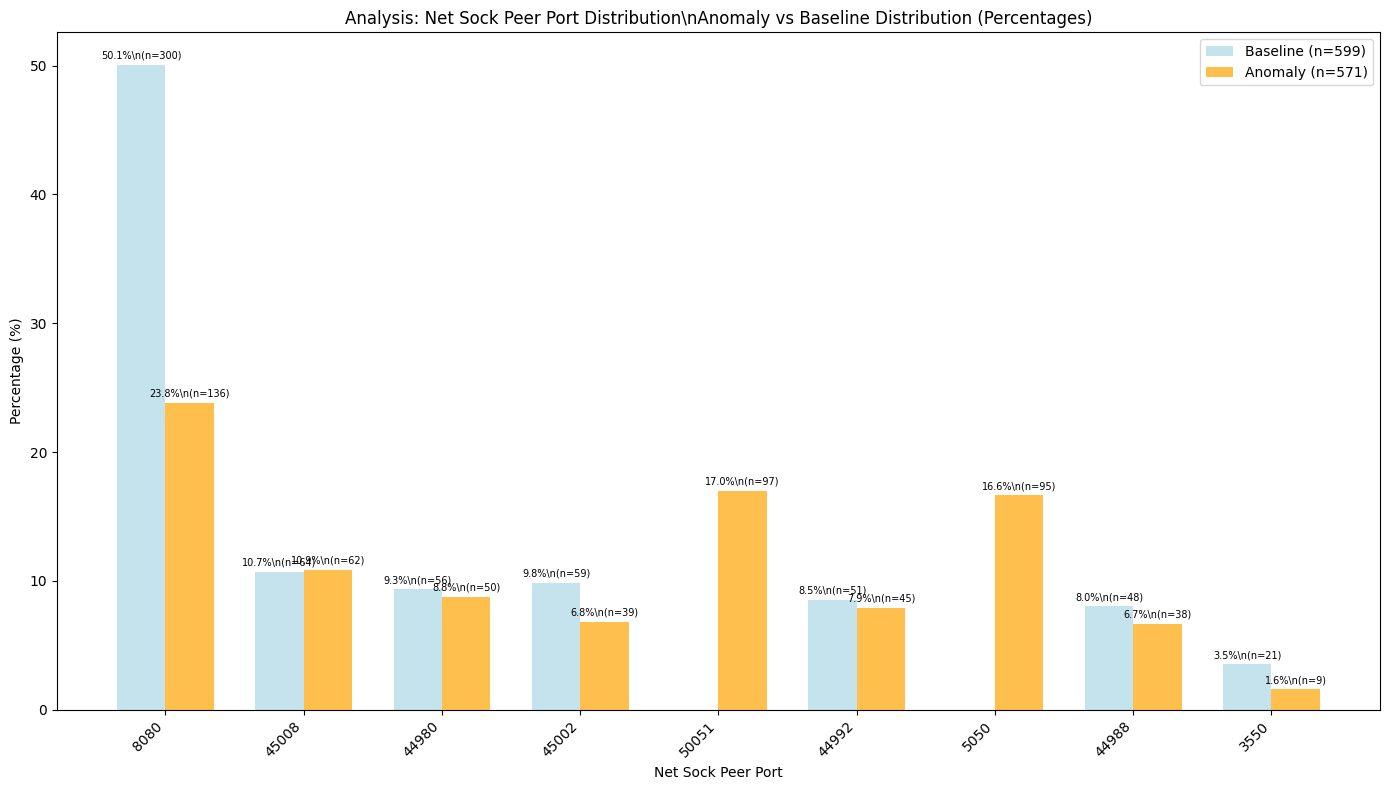

\n🔍 Net Sock Peer Port Analysis:
   📊 Total anomaly instances: 571
   📊 Total baseline instances: 599
   🚨 Values over-represented in anomaly group:
      • 50051: 17.0% of anomalies vs 0.0% of baseline (100.0% of this value is anomalous)
      • 5050: 16.6% of anomalies vs 0.0% of baseline (100.0% of this value is anomalous)
      • 45008: 10.9% of anomalies vs 10.7% of baseline (49.2% of this value is anomalous)

📋 2. HTTP METHOD ANALYSIS


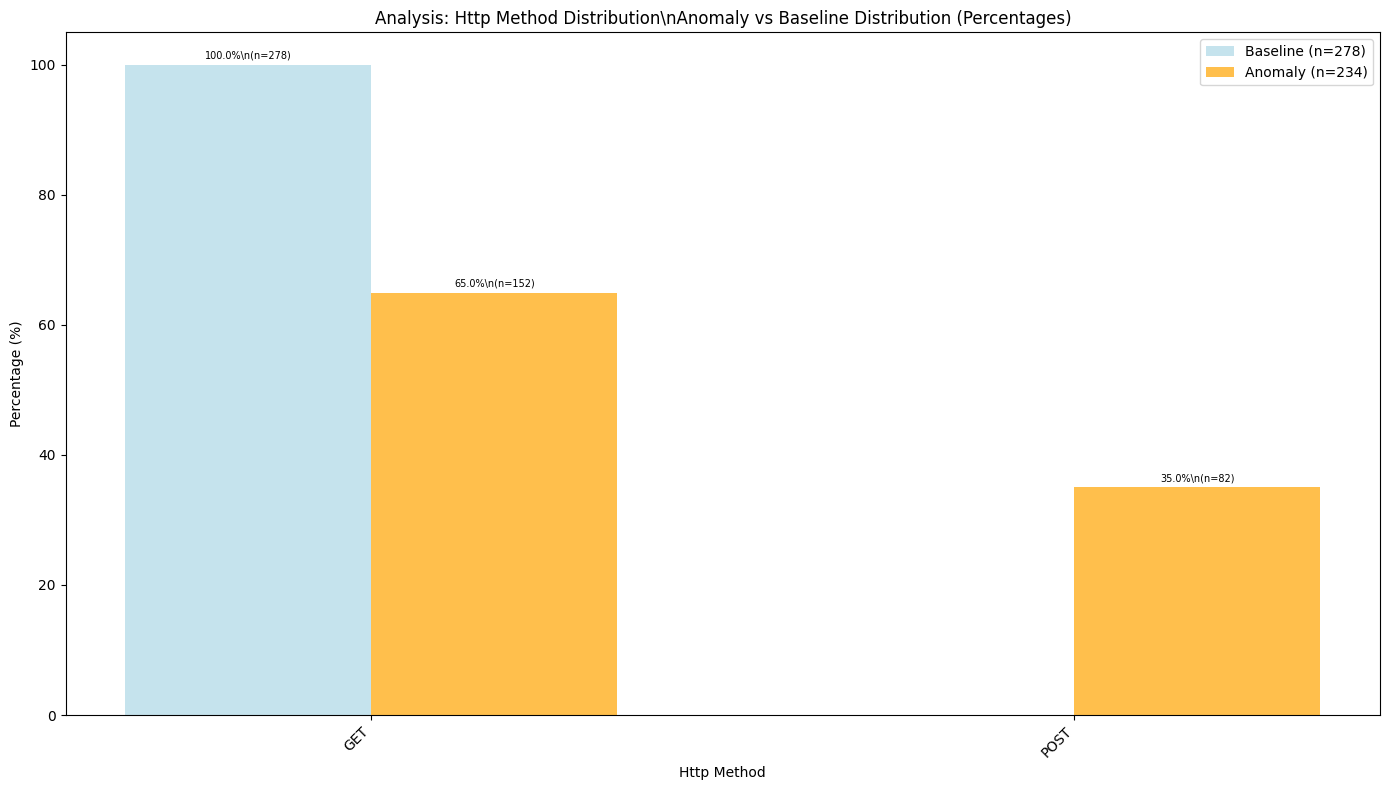

\n🔍 Http Method Analysis:
   📊 Total anomaly instances: 234
   📊 Total baseline instances: 278
   🚨 Values over-represented in anomaly group:
      • POST: 35.0% of anomalies vs 0.0% of baseline (100.0% of this value is anomalous)

📋 3. HTTP TARGET ANALYSIS


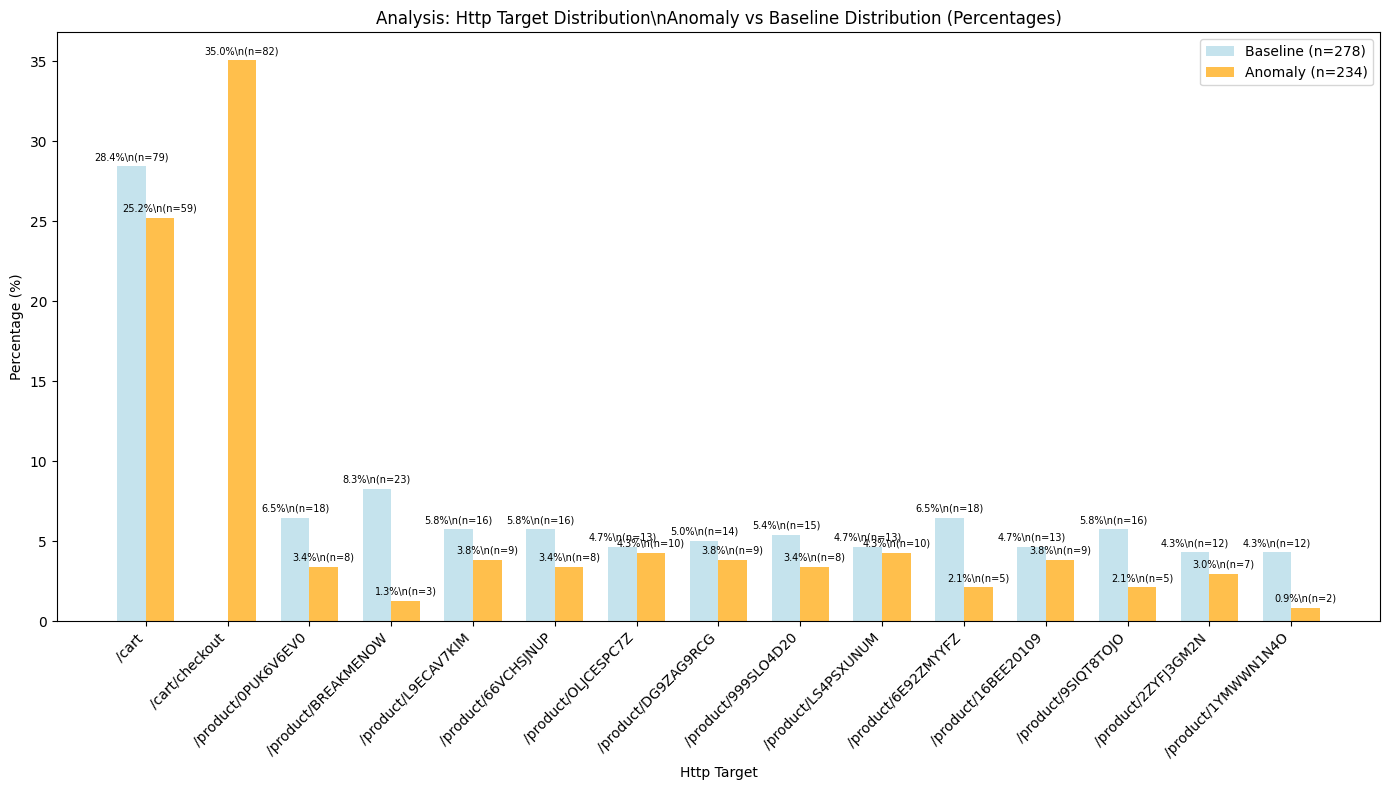

\n🔍 Http Target Analysis:
   📊 Total anomaly instances: 234
   📊 Total baseline instances: 278
   🚨 Values over-represented in anomaly group:
      • /cart/checkout: 35.0% of anomalies vs 0.0% of baseline (100.0% of this value is anomalous)
   🟢 Values over-represented in baseline group:
      • /product/BREAKMENOW: 8.3% of baseline vs 1.3% of anomalies (88.5% of this value is baseline)
      • /product/1YMWWN1N4O: 4.3% of baseline vs 0.9% of anomalies (85.7% of this value is baseline)

📋 4. HTTP STATUS CODE ANALYSIS


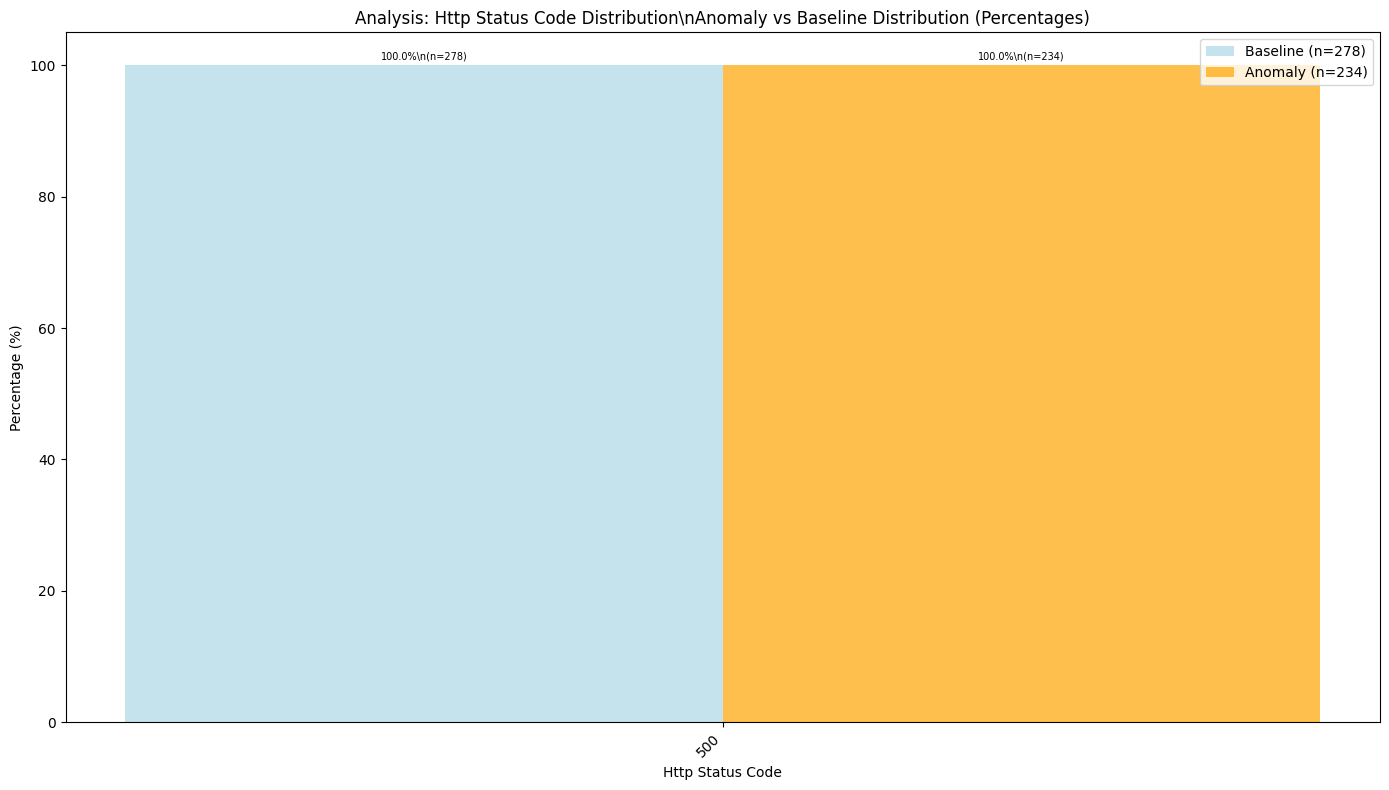

\n🔍 Http Status Code Analysis:
   📊 Total anomaly instances: 234
   📊 Total baseline instances: 278

📋 5. HTTP ROUTE ANALYSIS


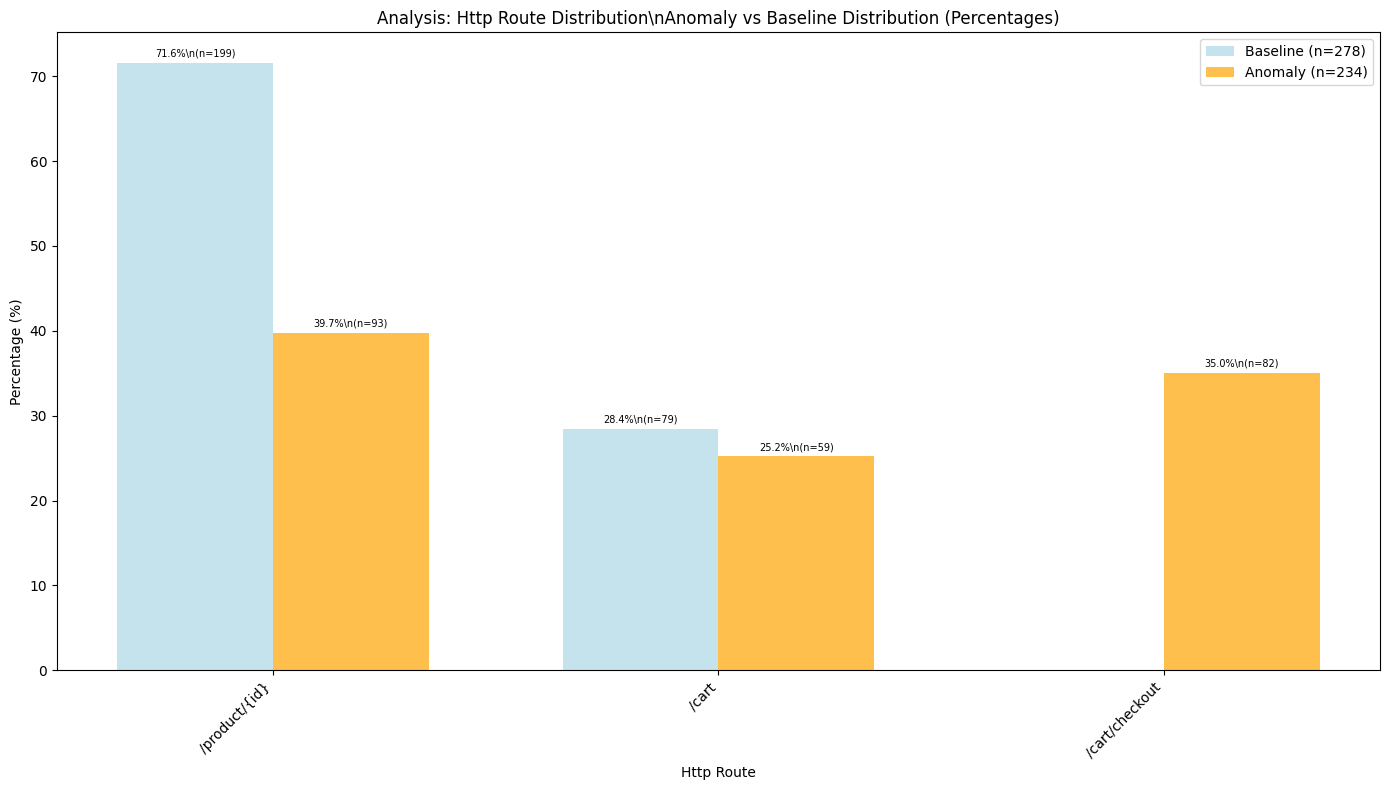

\n🔍 Http Route Analysis:
   📊 Total anomaly instances: 234
   📊 Total baseline instances: 278
   🚨 Values over-represented in anomaly group:
      • /cart/checkout: 35.0% of anomalies vs 0.0% of baseline (100.0% of this value is anomalous)

📋 6. APP USER ID ANALYSIS
   📊 Found 515 unique values for App User Id. Showing top 20 by frequency.
   🔝 Using top 20 values (representing 123 total instances)


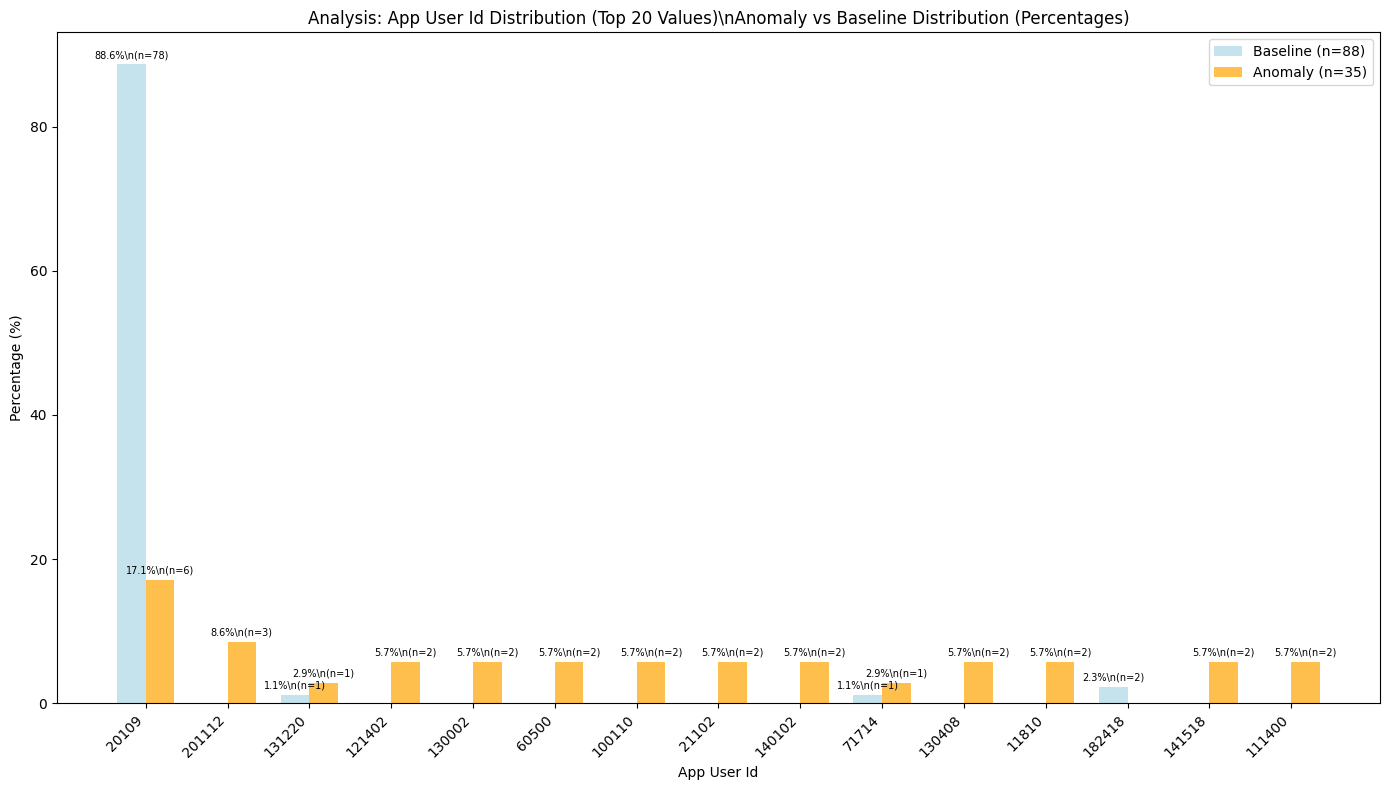

\n🔍 App User Id Analysis:
   📊 Total anomaly instances: 35
   📊 Total baseline instances: 88
   🚨 Values over-represented in anomaly group:
      • 201112: 8.6% of anomalies vs 0.0% of baseline (100.0% of this value is anomalous)
      • 121402: 5.7% of anomalies vs 0.0% of baseline (100.0% of this value is anomalous)
      • 130002: 5.7% of anomalies vs 0.0% of baseline (100.0% of this value is anomalous)
      • 60500: 5.7% of anomalies vs 0.0% of baseline (100.0% of this value is anomalous)
      • 100110: 5.7% of anomalies vs 0.0% of baseline (100.0% of this value is anomalous)
      • 21102: 5.7% of anomalies vs 0.0% of baseline (100.0% of this value is anomalous)
      • 140102: 5.7% of anomalies vs 0.0% of baseline (100.0% of this value is anomalous)
      • 130408: 5.7% of anomalies vs 0.0% of baseline (100.0% of this value is anomalous)
      • 11810: 5.7% of anomalies vs 0.0% of baseline (100.0% of this value is anomalous)
      • 141518: 5.7% of anomalies vs 0.0% of baseline

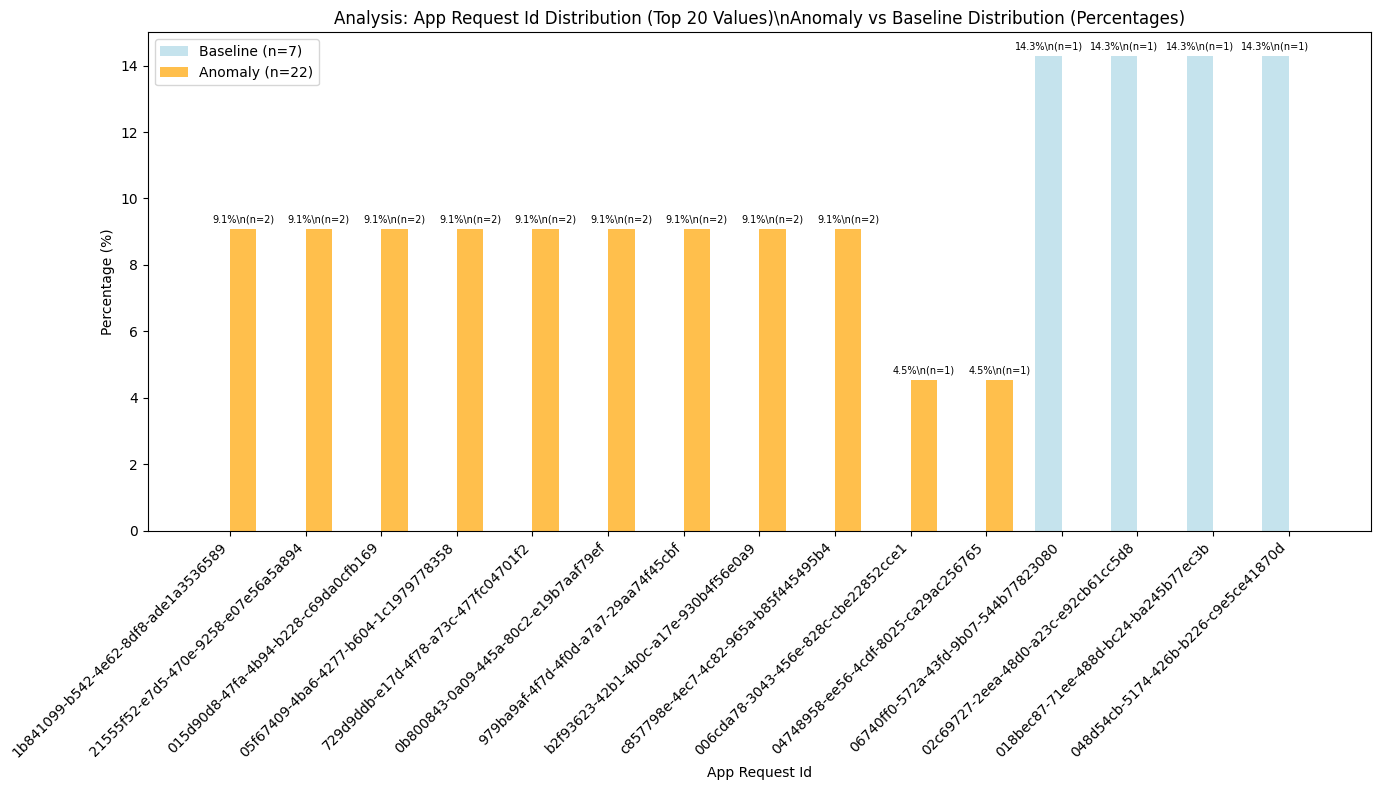

\n🔍 App Request Id Analysis:
   📊 Total anomaly instances: 22
   📊 Total baseline instances: 7
   🚨 Values over-represented in anomaly group:
      • 1b841099-b542-4e62-8df8-ade1a3536589: 9.1% of anomalies vs 0.0% of baseline (100.0% of this value is anomalous)
      • 21555f52-e7d5-470e-9258-e07e56a5a894: 9.1% of anomalies vs 0.0% of baseline (100.0% of this value is anomalous)
      • 015d90d8-47fa-4b94-b228-c69da0cfb169: 9.1% of anomalies vs 0.0% of baseline (100.0% of this value is anomalous)
      • 05f67409-4ba6-4277-b604-1c1979778358: 9.1% of anomalies vs 0.0% of baseline (100.0% of this value is anomalous)
      • 729d9ddb-e17d-4f78-a73c-477fc04701f2: 9.1% of anomalies vs 0.0% of baseline (100.0% of this value is anomalous)
      • 0b800843-0a09-445a-80c2-e19b7aaf79ef: 9.1% of anomalies vs 0.0% of baseline (100.0% of this value is anomalous)
      • 979ba9af-4f7d-4f0d-a7a7-29aa74f45cbf: 9.1% of anomalies vs 0.0% of baseline (100.0% of this value is anomalous)
      • b2f93623-4

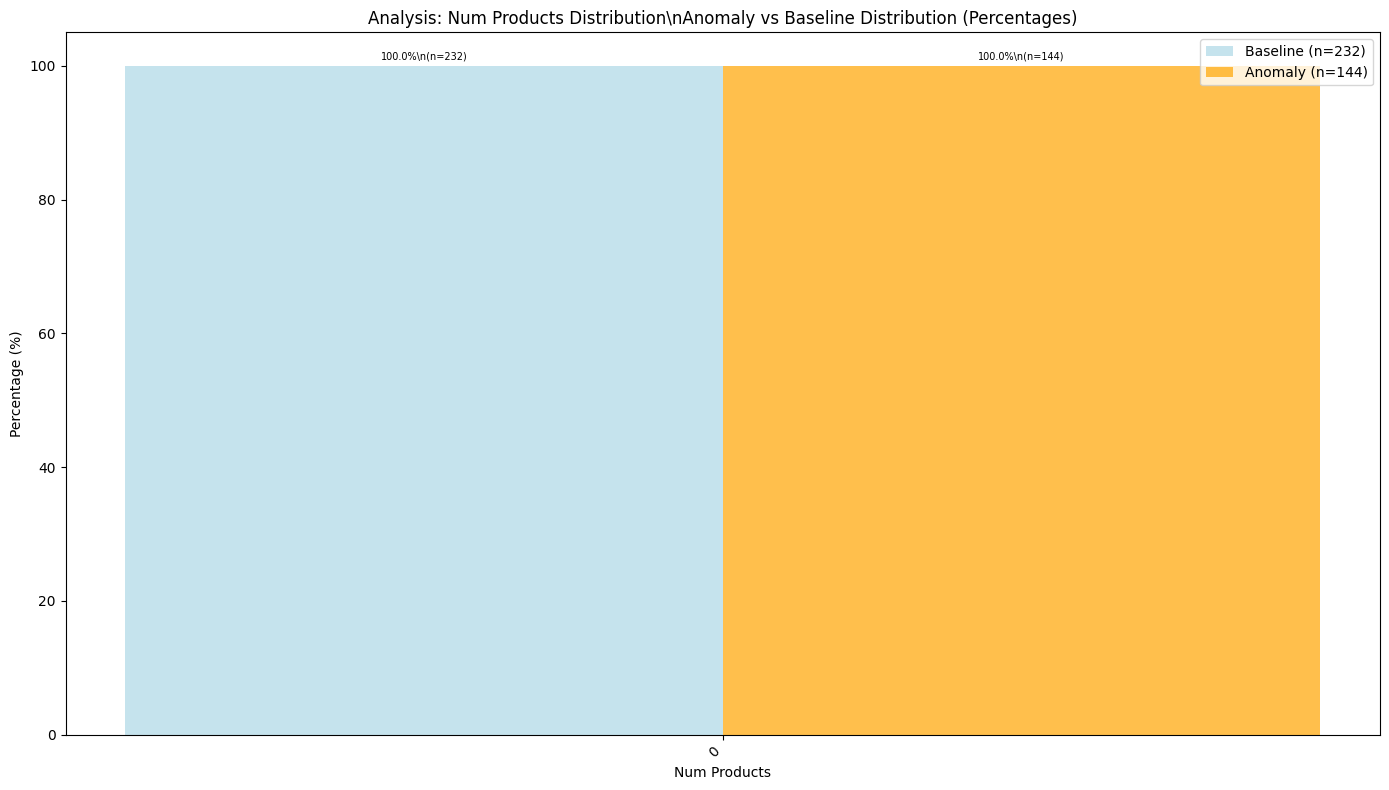

\n🔍 Num Products Analysis:
   📊 Total anomaly instances: 144
   📊 Total baseline instances: 232

📋 9. APP CART TOTAL ANALYSIS
   ❌ Error creating chart for App Cart Total: 'attr_app_cart_total'

✅ Attribute analysis completed!
   📊 Created 8 attribute comparison charts
   ⚠️ 1 errors encountered


{'figures_created': 8,
 'total_attributes': 9,
 'errors': ["Error creating chart for App Cart Total: 'attr_app_cart_total'"],
 'success_rate': 0.8888888888888888}

In [81]:
attr_columns = analyze_attribute_columns(df_anomaly, df_baseline)
create_attribute_paired_histograms(df_anomaly, df_baseline, actual_attr_columns)

## Ranking Algorithm


Top ranked histograms (higher score = more useful to find anomaly causes):



,attribute,score,anomaly_only_values,max_pct_diff,coverage_pct,unique_values,anomaly_count,baseline_count
1,attr_app_request_id,66623.5,333,0.6,34.2,611,342,278
2,attr_app_user_id,63727.3,318,26.3,34.2,515,342,278
3,attr_grpc_error_message,21615.7,108,1.8,10.9,108,109,0
4,attr_payment_user_id,21615.7,108,1.8,10.9,108,109,0
5,attr_app_cache_size,21612.0,108,0.9,10.8,108,108,0
6,attr_app_order_id,21612.0,108,0.9,10.8,108,108,0
7,attr_rpc_service,681.0,2,57.6,68.3,4,683,583
8,attr_rpc_method,681.0,2,57.6,68.3,4,683,583
9,ServiceName,572.6,2,20.5,100.0,4,1000,1000
10,attr_net_sock_peer_addr,567.7,2,26.3,57.1,5,571,599


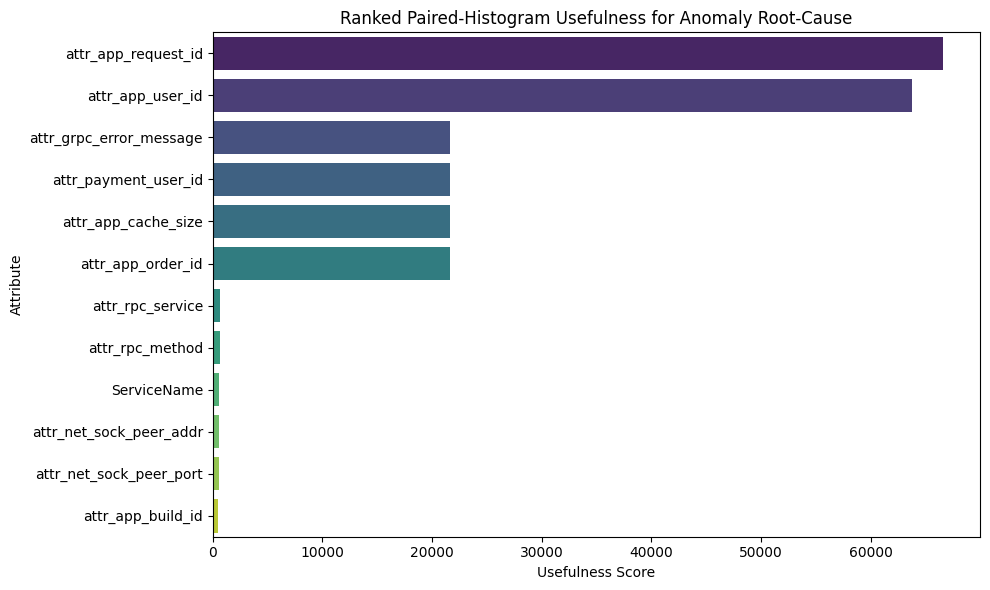


Ranking complete. Use the dataframe `enhanced_rankings` for programmatic access.


In [ ]:
# Run ranking using available dataframes
histogram_rankings = rank_histograms(df_anomaly, df_baseline, attributes=None, top_n=20)

# Save to variable for later use
enhanced_rankings = histogram_rankings
print('\nRanking complete. Use the dataframe `enhanced_rankings` for programmatic access.')

# 🏆 RANKING PAIRED HISTOGRAMS FOR ANOMALY ROOT CAUSE ANALYSIS

Now let's rank all the paired histogram graphs by their usefulness for identifying what's causing the anomaly. We'll prioritize:
1. **Anomaly-exclusive values** (values only in anomaly group, not baseline)
2. **Large percentage differences** between anomaly vs baseline distributions
3. **High coverage** of anomaly data points
4. **Statistical significance** of the differences

In [ ]:
# Run the comprehensive ranking analysis
print("📊 Running comprehensive ranking analysis...")
attribute_rankings = rank_attributes_comprehensive(df_anomaly, df_baseline)

📊 Running comprehensive ranking analysis...
🔍 ANALYZING ALL PAIRED HISTOGRAMS FOR ANOMALY DETECTION USEFULNESS


In [ ]:
# Display the detailed results
display_ranking_results_detailed(attribute_rankings)


🏆 PAIRED HISTOGRAM USEFULNESS RANKING
📈 Ranked by effectiveness for identifying anomaly root causes
🎯 Higher scores = More useful for finding what's wrong

# 1. Service Name
     🎯 Usefulness Score: 250.0/230
     🚨 2 ANOMALY-ONLY values
     📋 Coverage: 100.0% of anomaly data | Values: 4 | Data: 1,000 anom, 1,000 base
     🔍 Key Findings:
        • 'checkout': ⚠️  ONLY in anomalies (20.5%)
        • 'payment': ⚠️  ONLY in anomalies (10.9%)

# 2. Rpc Service
     🎯 Usefulness Score: 247.3/230
     🚨 2 ANOMALY-ONLY values
     📋 Coverage: 68.3% of anomaly data | Values: 4 | Data: 683 anom, 583 base
     🔍 Key Findings:
        • 'msdemo.CheckoutService': ⚠️  ONLY in anomalies (29.7%)
        • 'msdemo.PaymentService': ⚠️  ONLY in anomalies (30.2%)

# 3. Rpc Method
     🎯 Usefulness Score: 247.3/230
     🚨 2 ANOMALY-ONLY values
     📋 Coverage: 68.3% of anomaly data | Values: 4 | Data: 683 anom, 583 base
     🔍 Key Findings:
        • 'PlaceOrder': ⚠️  ONLY in anomalies (29.7%)
        

📊 Creating ranking visualization...


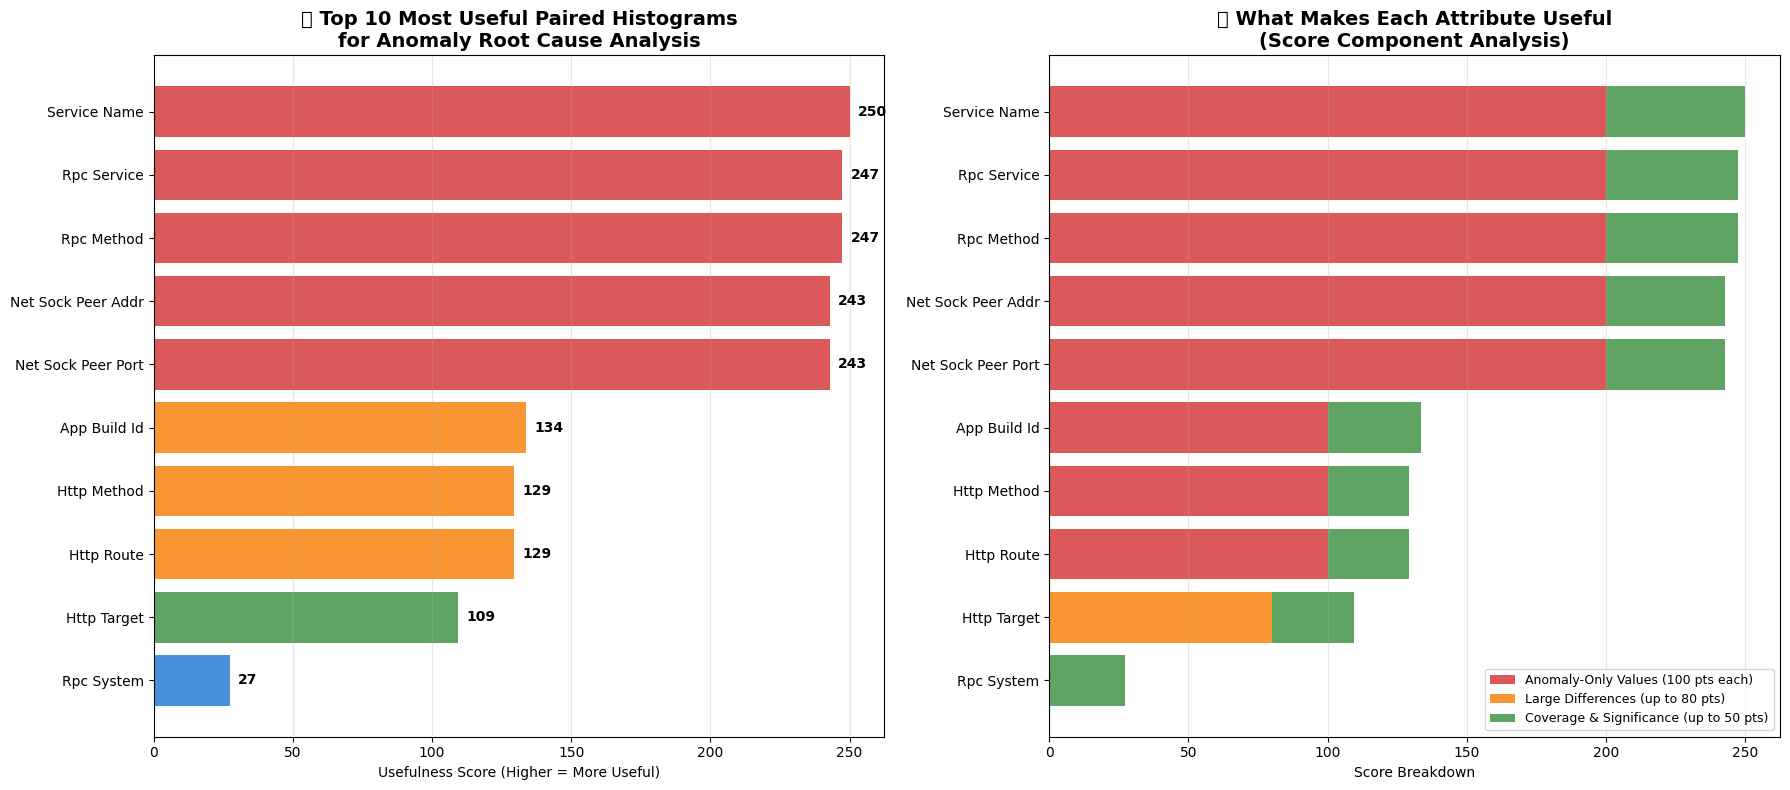


✅ Analysis complete! Ranking data saved to 'enhanced_rankings' variable.
📊 Total attributes analyzed: 23
🎯 Use the charts above to prioritize your anomaly investigation.


In [ ]:
# Create the visualization
print("📊 Creating ranking visualization...")
ranking_chart = create_ranking_visualization_chart(attribute_rankings)

# Save rankings for later reference
enhanced_rankings = pd.DataFrame(attribute_rankings)
print(f"\n✅ Analysis complete! Ranking data saved to 'enhanced_rankings' variable.")
print(f"📊 Total attributes analyzed: {len(attribute_rankings)}")
print(f"🎯 Use the charts above to prioritize your anomaly investigation.")

# 📊 RANKED ATTRIBUTE ANALYSIS - ORDERED BY USEFULNESS

Now let's regenerate the paired histogram graphs in the order of their usefulness rankings. This will show the most important attributes for identifying the anomaly cause first.

📊 CREATING RANKED BUBBLE-UP HISTOGRAMS
🎯 Generating charts for top 12 most useful attributes
📈 Ordered by anomaly detection usefulness score

# 1. Service Name (Score: 250.0)


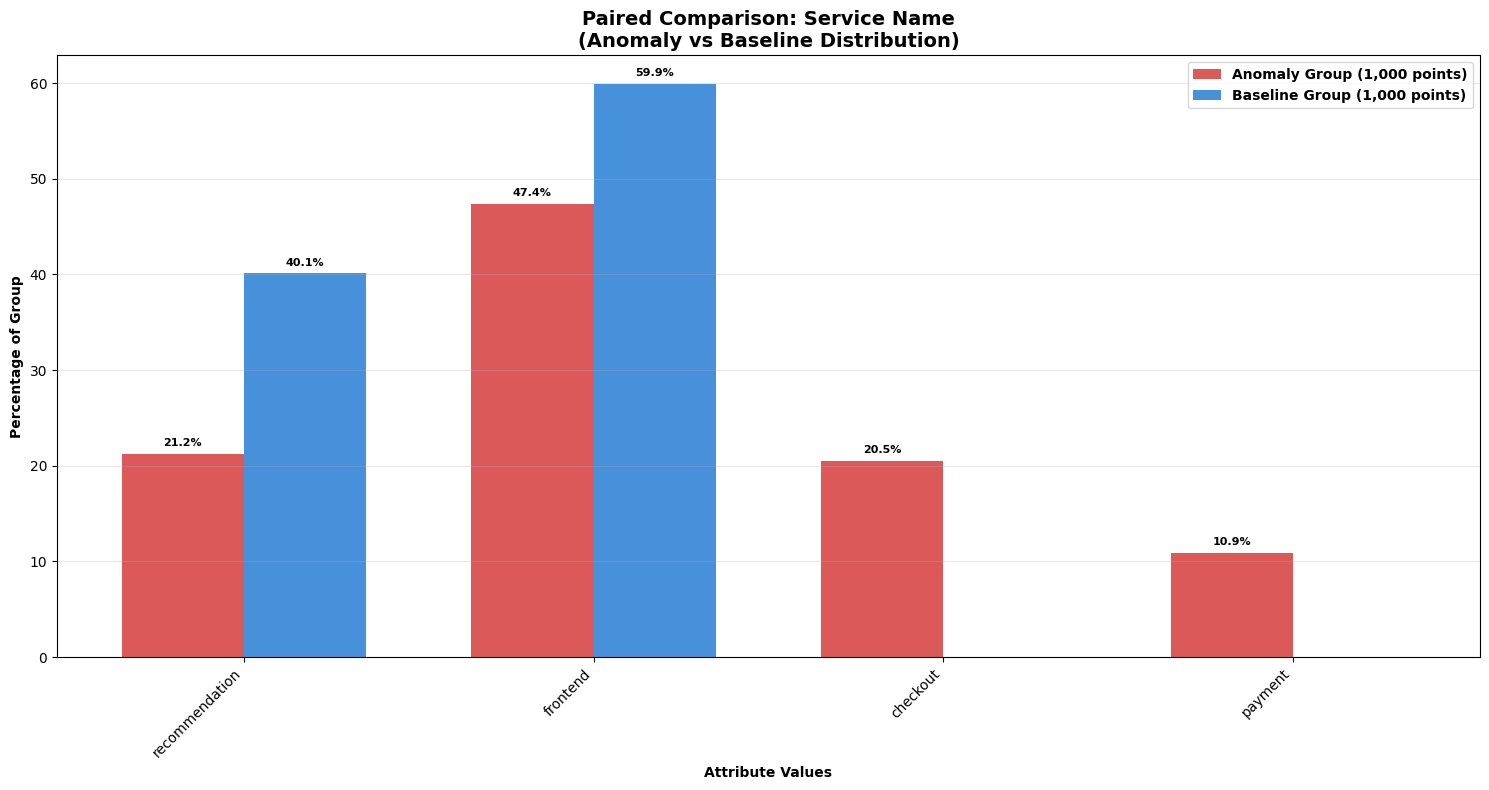

🔢 Value Distribution Table for Service Name


,Value,Anomaly %,Baseline %
0,recommendation,21.2,40.1
1,frontend,47.4,59.9
2,checkout,20.5,0.0
3,payment,10.9,0.0


     🔍 Key Insights for Service Name:
        🚨 ANOMALY-ONLY values: 'checkout' (20.5%), 'payment' (10.9%)
        📊 LARGE differences: 'recommendation': 18.9% lower in anomalies, 'frontend': 12.5% lower in anomalies
        📋 Coverage: 100.0% | Usefulness Score: 250.0

# 2. Rpc Service (Score: 247.3)


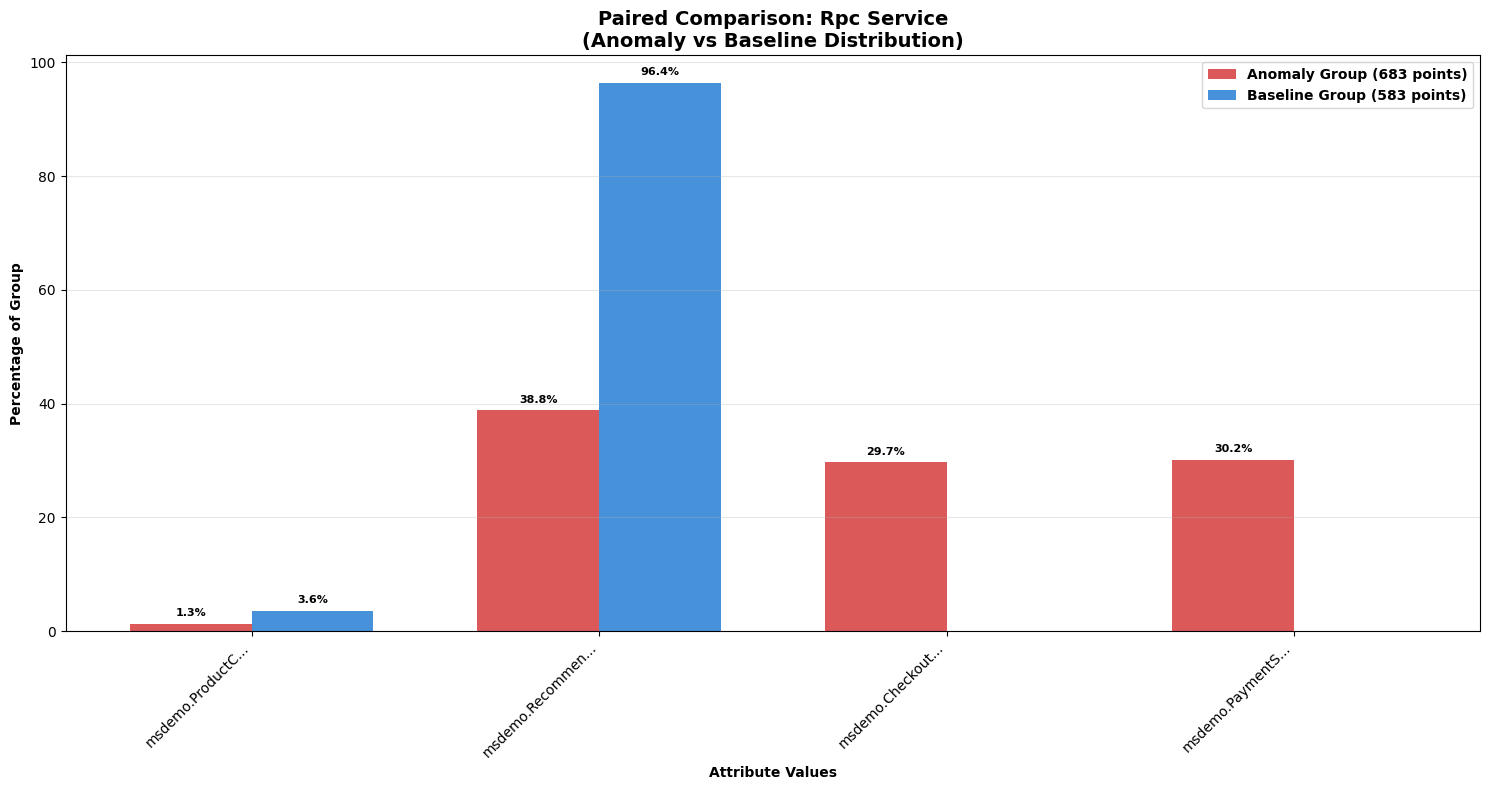

🔢 Value Distribution Table for Rpc Service


,Value,Anomaly %,Baseline %
0,msdemo.ProductCatalogService,1.317716,3.602058
1,msdemo.RecommendationService,38.799414,96.397942
2,msdemo.CheckoutService,29.721816,0.000000
3,msdemo.PaymentService,30.161054,0.000000


     🔍 Key Insights for Rpc Service:
        🚨 ANOMALY-ONLY values: 'msdemo.PaymentService' (30.2%), 'msdemo.CheckoutService' (29.7%)
        📊 LARGE differences: 'msdemo.RecommendationService': 57.6% lower in anomalies, 'msdemo.CheckoutService': 29.7% higher in anomalies
        📋 Coverage: 68.3% | Usefulness Score: 247.3

# 3. Rpc Method (Score: 247.3)


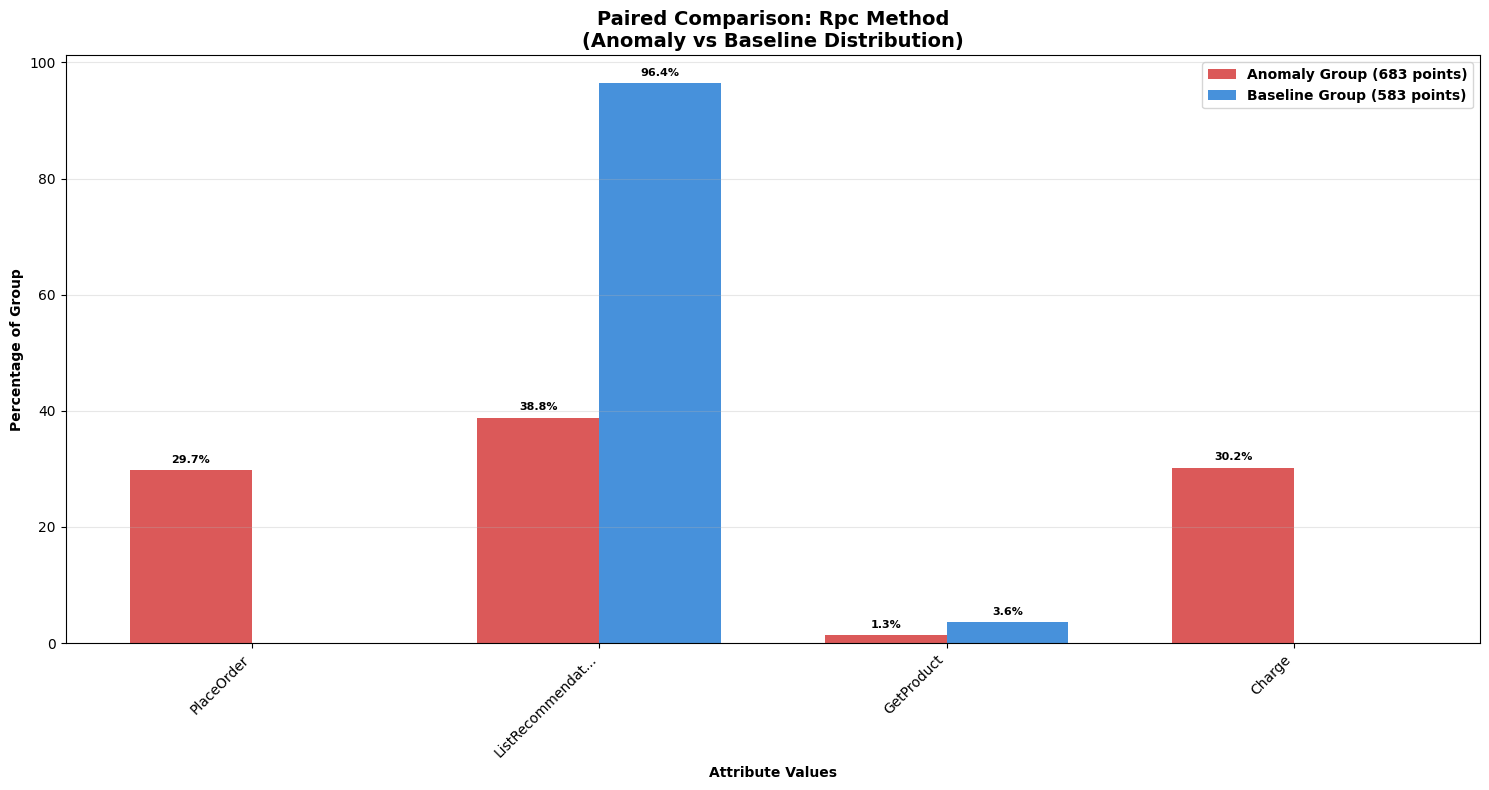

🔢 Value Distribution Table for Rpc Method


,Value,Anomaly %,Baseline %
0,PlaceOrder,29.721816,0.000000
1,ListRecommendations,38.799414,96.397942
2,GetProduct,1.317716,3.602058
3,Charge,30.161054,0.000000


     🔍 Key Insights for Rpc Method:
        🚨 ANOMALY-ONLY values: 'Charge' (30.2%), 'PlaceOrder' (29.7%)
        📊 LARGE differences: 'PlaceOrder': 29.7% higher in anomalies, 'ListRecommendations': 57.6% lower in anomalies
        📋 Coverage: 68.3% | Usefulness Score: 247.3

# 4. Net Sock Peer Addr (Score: 242.8)


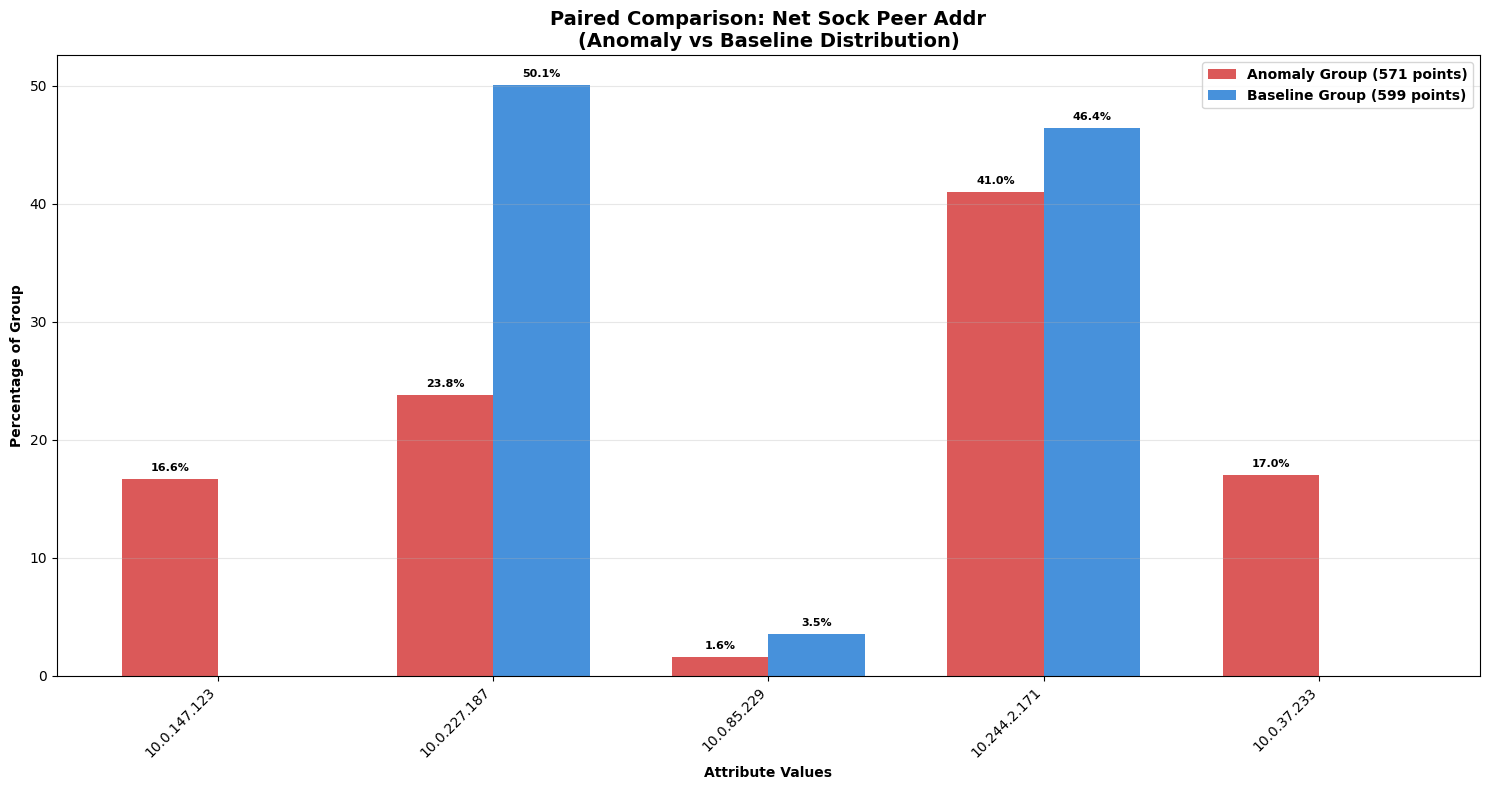

🔢 Value Distribution Table for Net Sock Peer Addr


,Value,Anomaly %,Baseline %
0,10.0.147.123,16.637478,0.000000
1,10.0.227.187,23.817863,50.083472
2,10.0.85.229,1.576182,3.505843
3,10.244.2.171,40.980736,46.410684
4,10.0.37.233,16.987741,0.000000


     🔍 Key Insights for Net Sock Peer Addr:
        🚨 ANOMALY-ONLY values: '10.0.37.233' (17.0%), '10.0.147.123' (16.6%)
        📊 LARGE differences: '10.0.147.123': 16.6% higher in anomalies, '10.0.227.187': 26.3% lower in anomalies
        📋 Coverage: 57.1% | Usefulness Score: 242.8

# 5. Net Sock Peer Port (Score: 242.8)


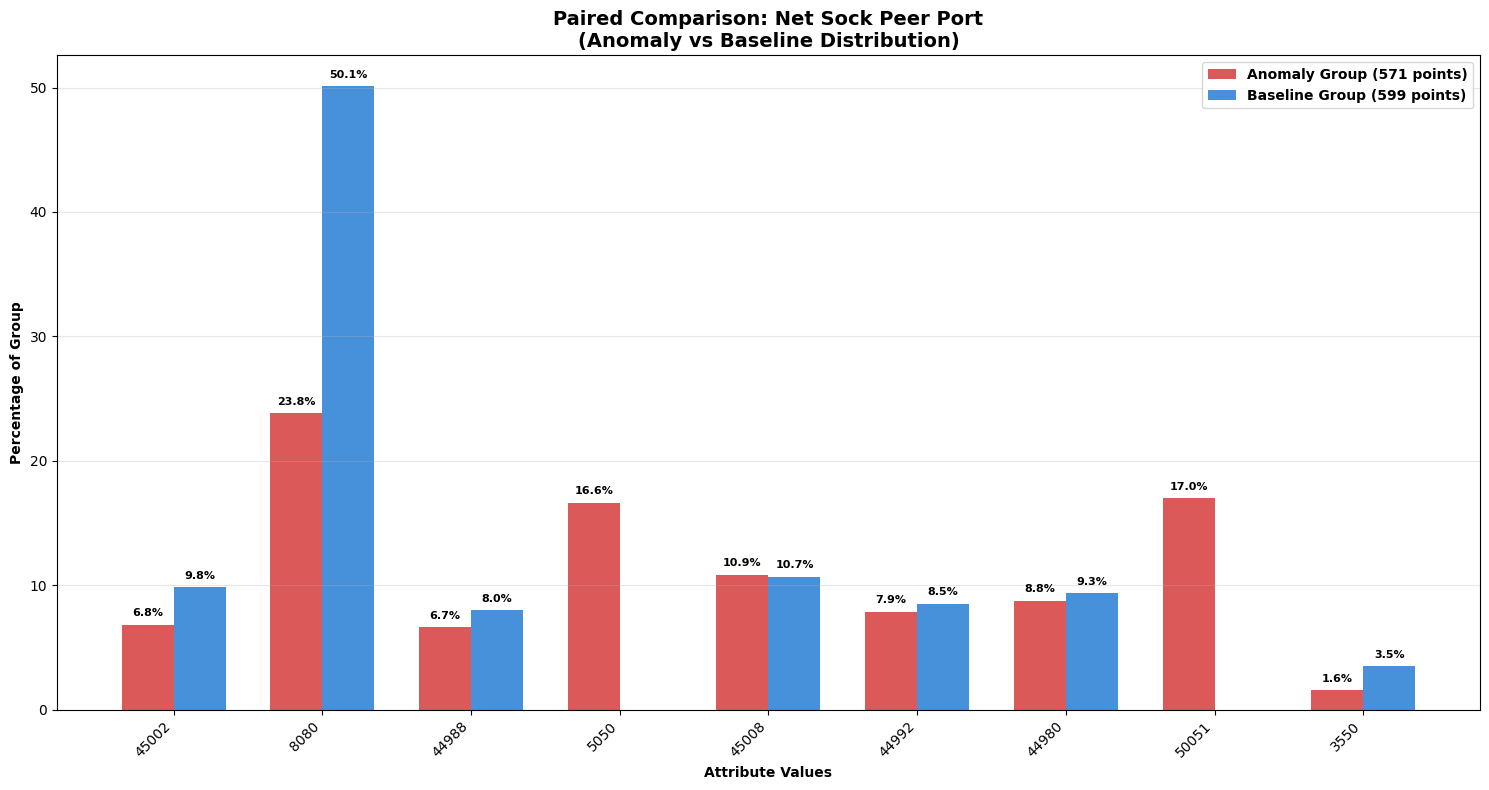

🔢 Value Distribution Table for Net Sock Peer Port


,Value,Anomaly %,Baseline %
0,45002,6.830123,9.849750
1,8080,23.817863,50.083472
2,44988,6.654991,8.013356
3,5050,16.637478,0.000000
4,45008,10.858144,10.684474
5,44992,7.880911,8.514190
6,44980,8.756567,9.348915
7,50051,16.987741,0.000000
8,3550,1.576182,3.505843


     🔍 Key Insights for Net Sock Peer Port:
        🚨 ANOMALY-ONLY values: '50051' (17.0%), '5050' (16.6%)
        📊 LARGE differences: '8080': 26.3% lower in anomalies, '5050': 16.6% higher in anomalies
        📋 Coverage: 57.1% | Usefulness Score: 242.8

# 6. App Build Id (Score: 133.7)


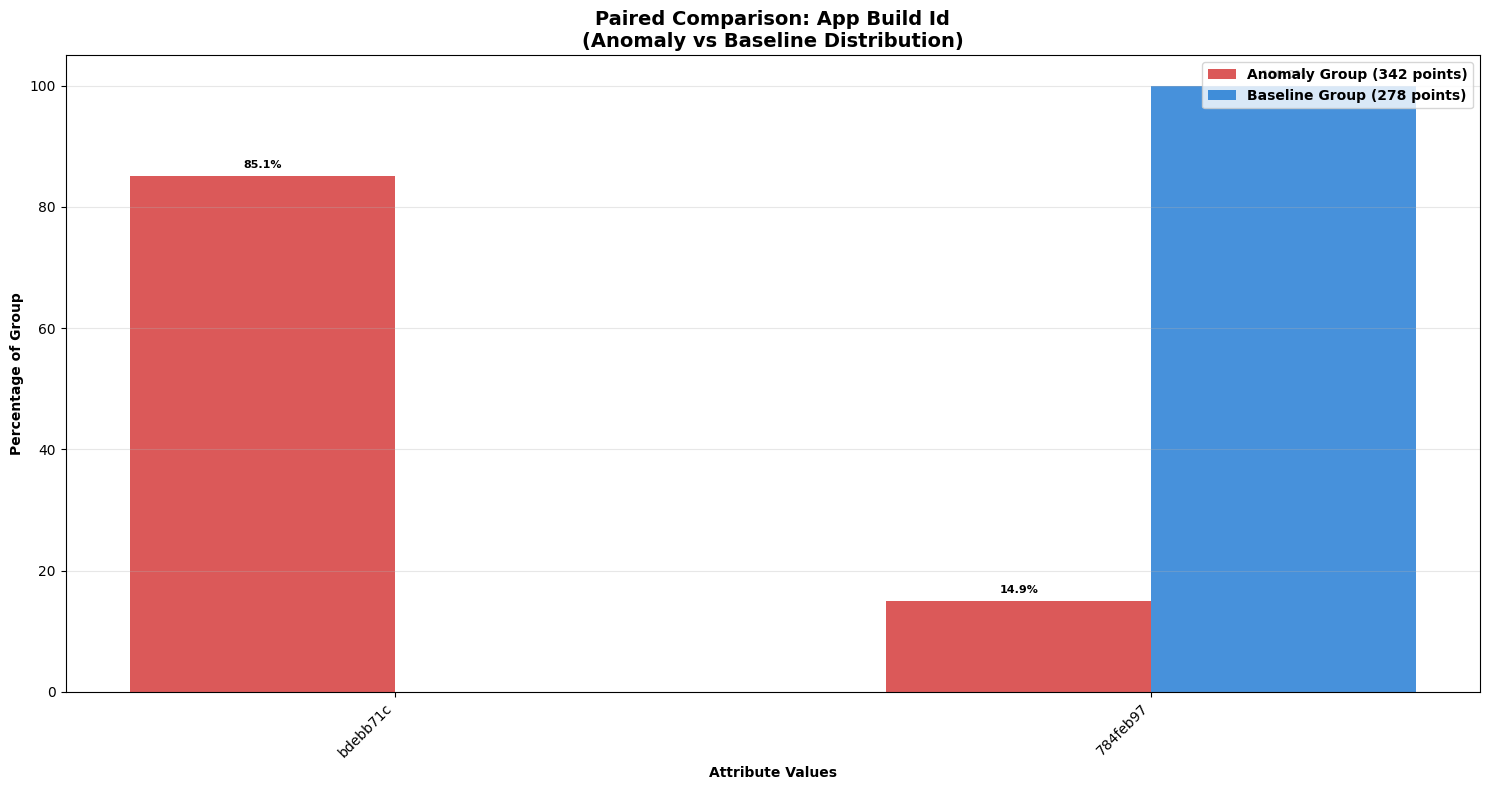

🔢 Value Distribution Table for App Build Id


,Value,Anomaly %,Baseline %
0,bdebb71c,85.087719,0.0
1,784feb97,14.912281,100.0


     🔍 Key Insights for App Build Id:
        🚨 ANOMALY-ONLY values: 'bdebb71c' (85.1%)
        📊 LARGE differences: 'bdebb71c': 85.1% higher in anomalies, '784feb97': 85.1% lower in anomalies
        📋 Coverage: 34.2% | Usefulness Score: 133.7

# 7. Http Method (Score: 129.4)


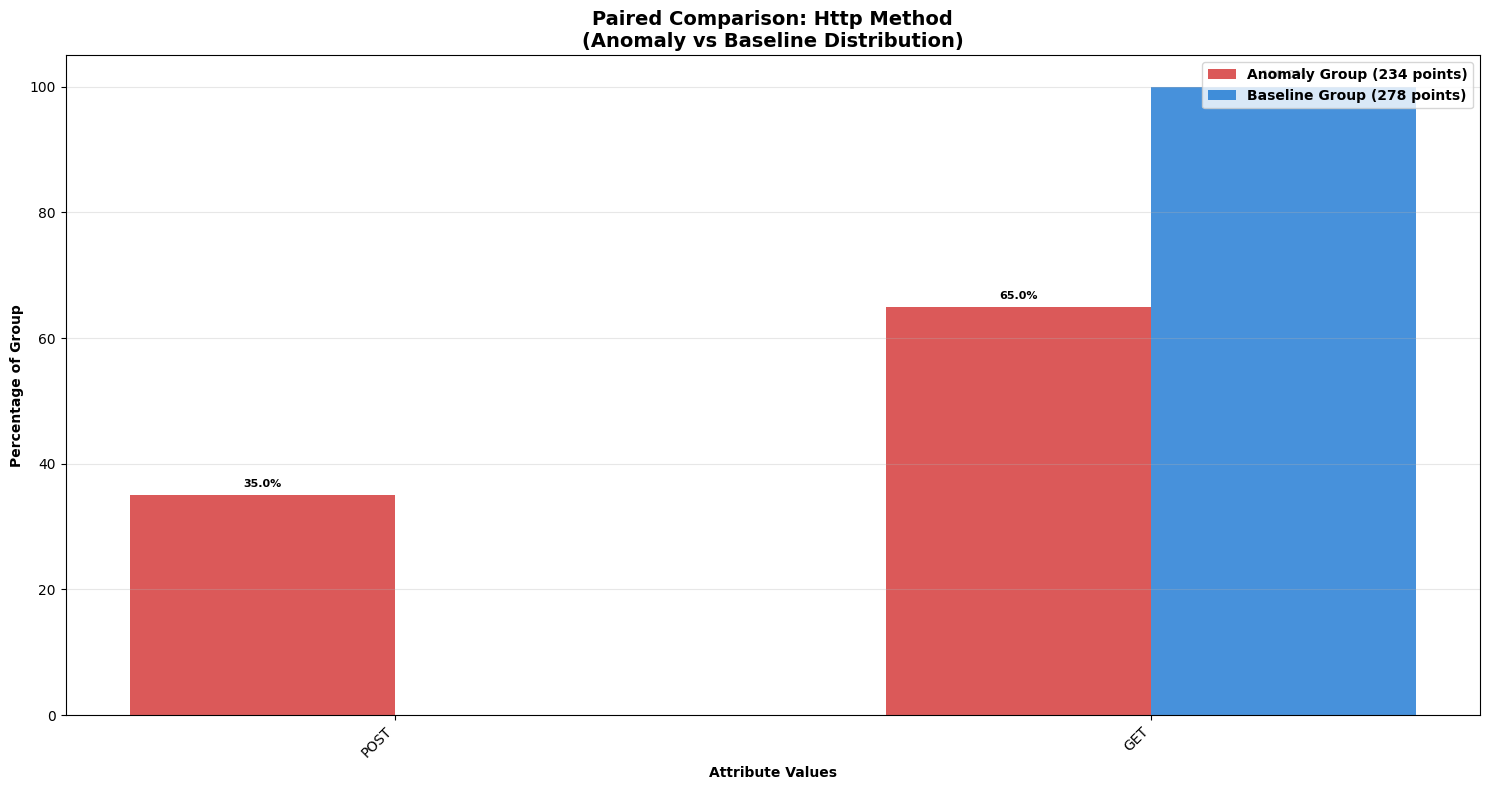

🔢 Value Distribution Table for Http Method


,Value,Anomaly %,Baseline %
0,POST,35.042735,0.0
1,GET,64.957265,100.0


     🔍 Key Insights for Http Method:
        🚨 ANOMALY-ONLY values: 'POST' (35.0%)
        📊 LARGE differences: 'POST': 35.0% higher in anomalies, 'GET': 35.0% lower in anomalies
        📋 Coverage: 23.4% | Usefulness Score: 129.4

# 8. Http Route (Score: 129.4)


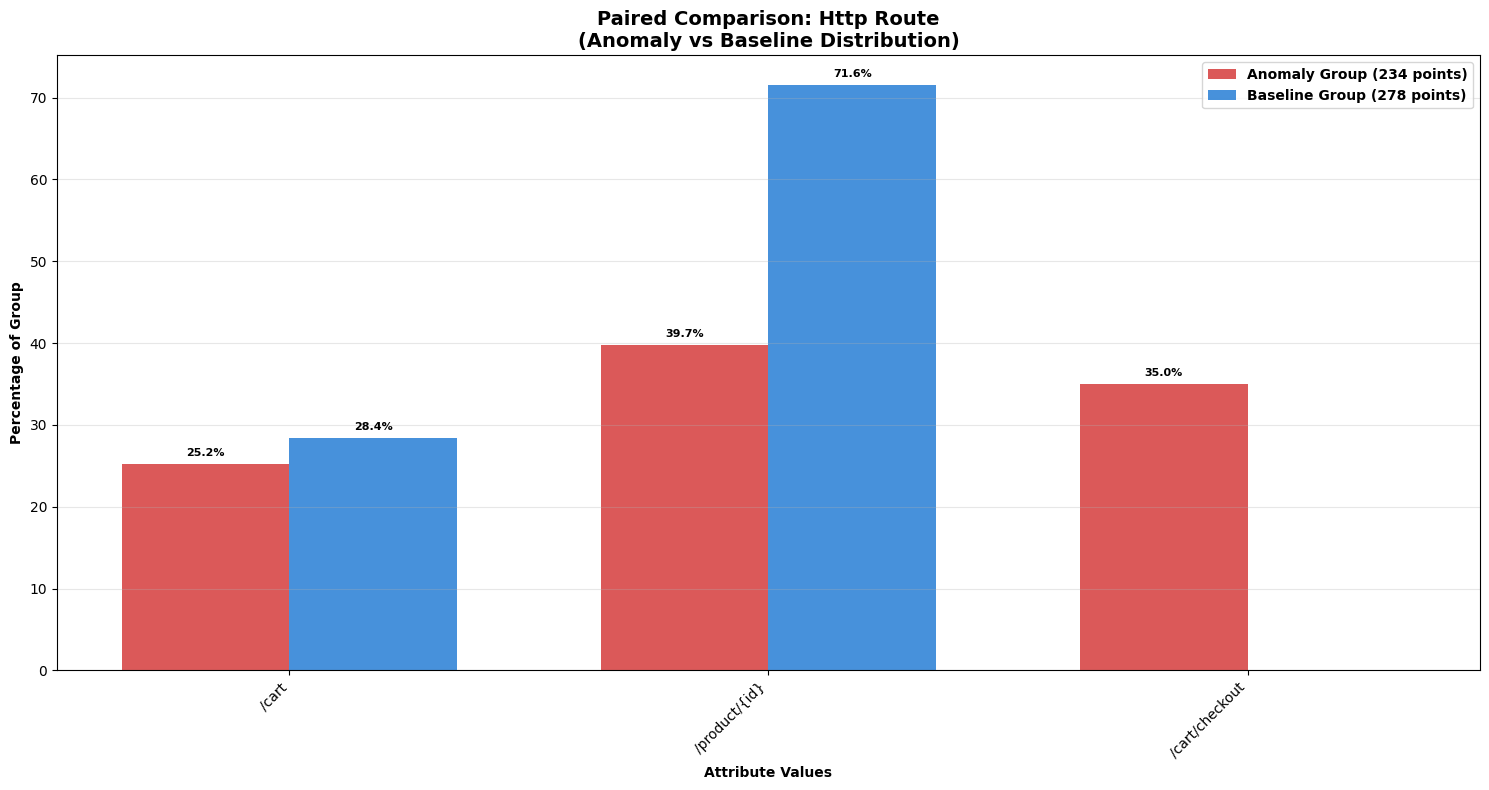

🔢 Value Distribution Table for Http Route


,Value,Anomaly %,Baseline %
0,/cart,25.213675,28.417266
1,/product/{id},39.743590,71.582734
2,/cart/checkout,35.042735,0.000000


     🔍 Key Insights for Http Route:
        🚨 ANOMALY-ONLY values: '/cart/checkout' (35.0%)
        📊 LARGE differences: '/product/{id}': 31.8% lower in anomalies, '/cart/checkout': 35.0% higher in anomalies
        📋 Coverage: 23.4% | Usefulness Score: 129.4

# 9. Http Target (Score: 109.4)


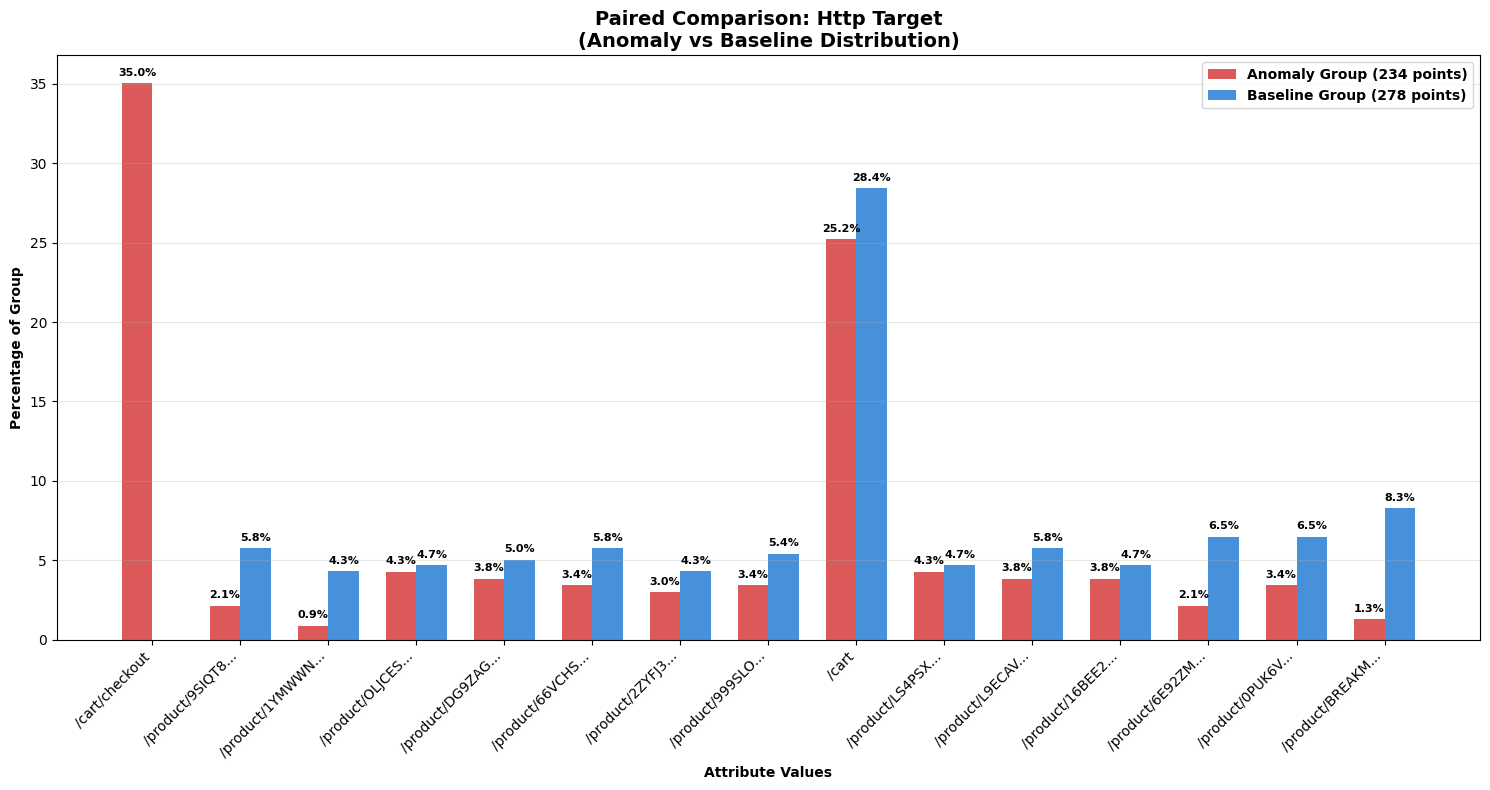

🔢 Value Distribution Table for Http Target


,Value,Anomaly %,Baseline %
0,/cart/checkout,35.042735,0.000000
1,/product/9SIQT8TOJO,2.136752,5.755396
2,/product/1YMWWN1N4O,0.854701,4.316547
3,/product/OLJCESPC7Z,4.273504,4.676259
4,/product/DG9ZAG9RCG,3.846154,5.035971
5,/product/66VCHSJNUP,3.418803,5.755396
6,/product/2ZYFJ3GM2N,2.991453,4.316547
7,/product/999SLO4D20,3.418803,5.395683
8,/cart,25.213675,28.417266
9,/product/LS4PSXUNUM,4.273504,4.676259


     🔍 Key Insights for Http Target:
        📊 LARGE differences: '/cart/checkout': 35.0% higher in anomalies
        📋 Coverage: 23.4% | Usefulness Score: 109.4

#10. Rpc System (Score: 27.3)


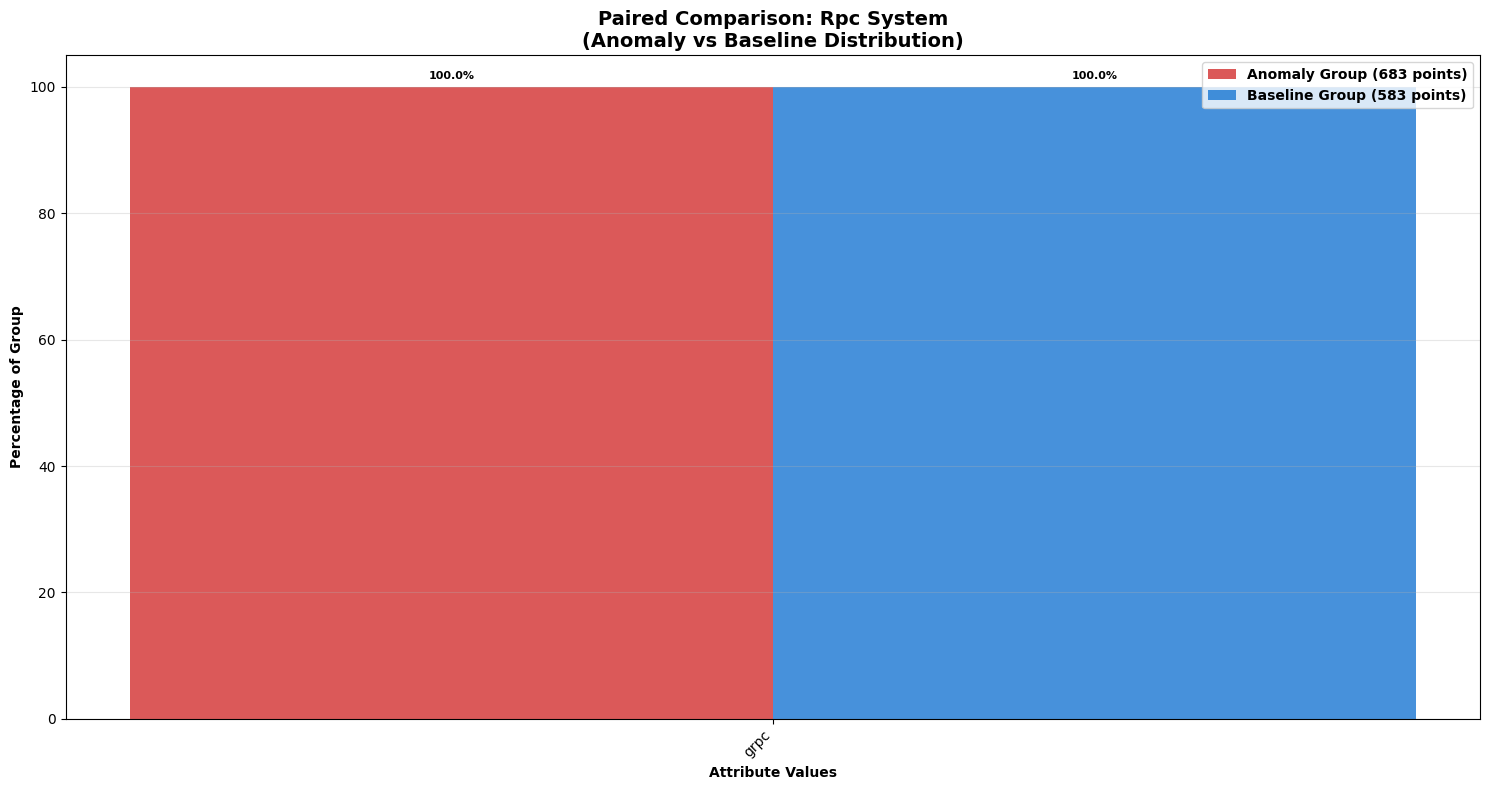

🔢 Value Distribution Table for Rpc System


,Value,Anomaly %,Baseline %
0,grpc,100.0,100.0


     🔍 Key Insights for Rpc System:
        📋 Coverage: 68.3% | Usefulness Score: 27.3

#11. Rpc Grpc Status Code (Score: 27.3)


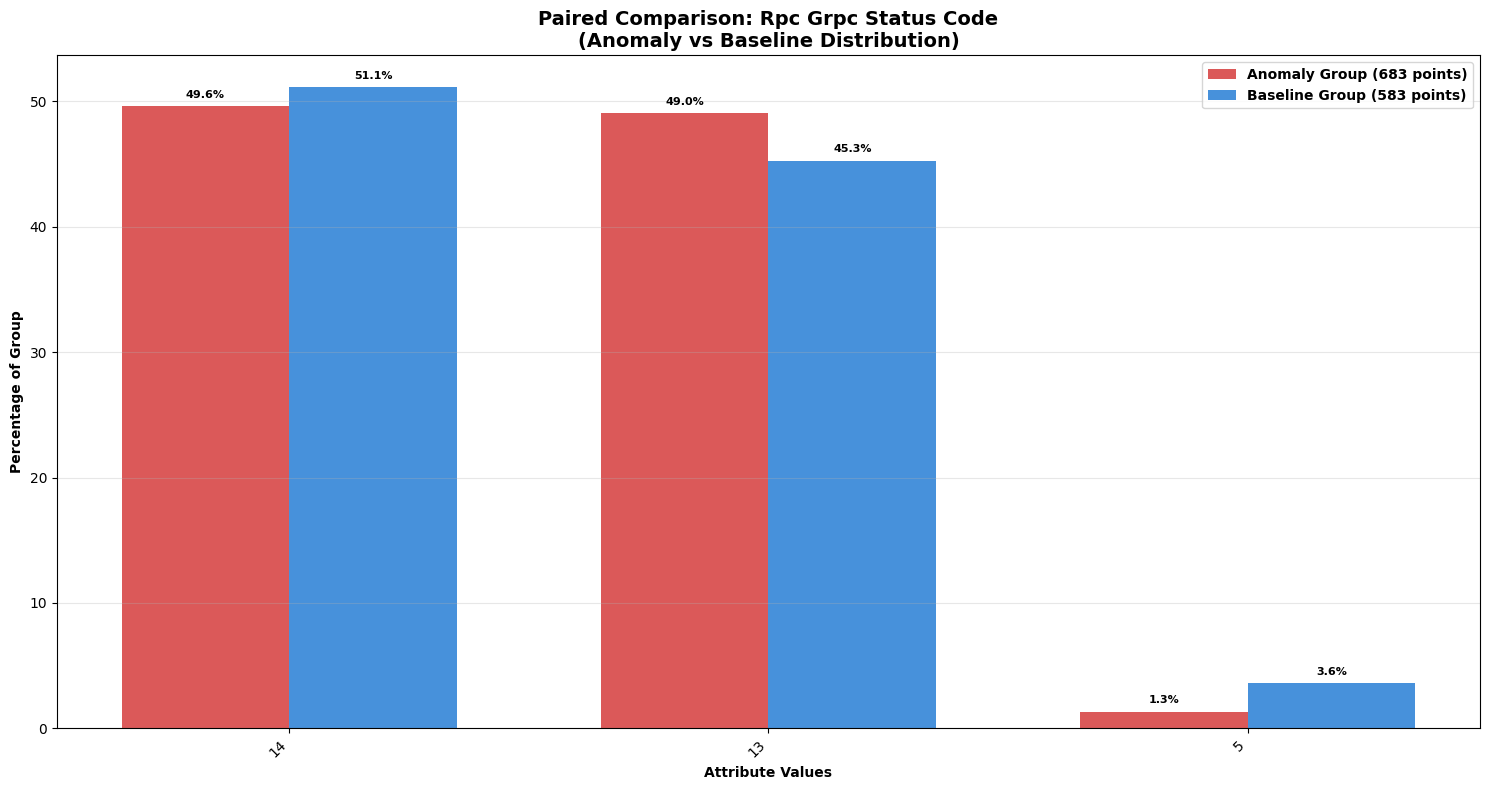

🔢 Value Distribution Table for Rpc Grpc Status Code


,Value,Anomaly %,Baseline %
0,14,49.633968,51.114923
1,13,49.048316,45.283019
2,5,1.317716,3.602058


     🔍 Key Insights for Rpc Grpc Status Code:
        📋 Coverage: 68.3% | Usefulness Score: 27.3

#12. App User Id (Score: 13.7)
     🔝 Showing top 20 values (out of 515 total)


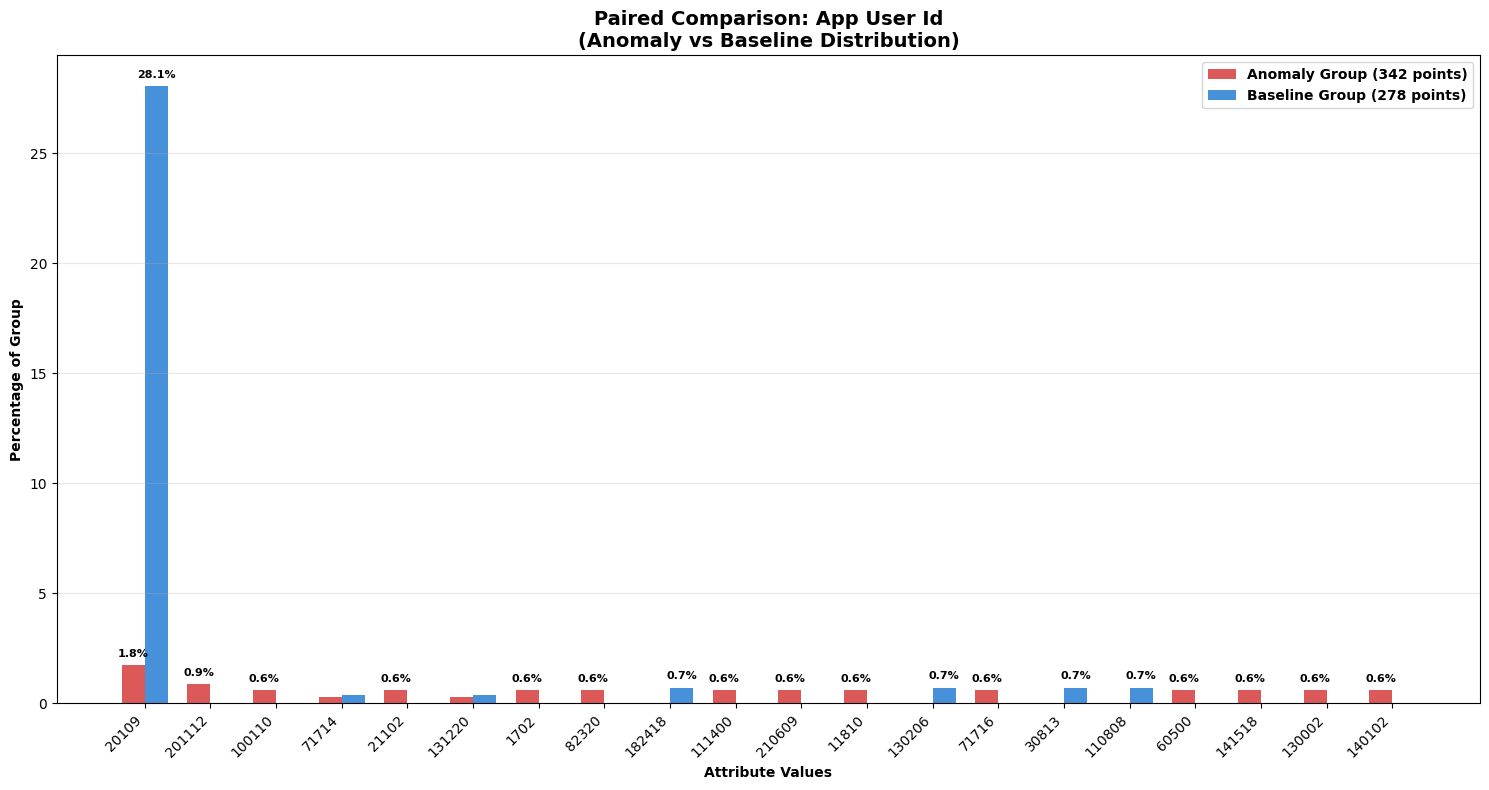

🔢 Value Distribution Table for App User Id


,Value,Anomaly %,Baseline %
0,20109,1.754386,28.057554
1,201112,0.877193,0.000000
2,100110,0.584795,0.000000
3,71714,0.292398,0.359712
4,21102,0.584795,0.000000
5,131220,0.292398,0.359712
6,1702,0.584795,0.000000
7,82320,0.584795,0.000000
8,182418,0.000000,0.719424
9,111400,0.584795,0.000000


     🔍 Key Insights for App User Id:
        📊 LARGE differences: '20109': 26.3% lower in anomalies
        📋 Coverage: 34.2% | Usefulness Score: 13.7

✅ RANKED ANALYSIS COMPLETE
📊 Created 12 charts ordered by usefulness
🎯 Focus on the top-ranked attributes for fastest anomaly resolution
[{'Attribute_name': 'Service Name', 'table':             Value  Anomaly %  Baseline %
0  recommendation       21.2        40.1
1        frontend       47.4        59.9
2        checkout       20.5         0.0
3         payment       10.9         0.0}, {'Attribute_name': 'Rpc Service', 'table':                           Value  Anomaly %  Baseline %
0  msdemo.ProductCatalogService   1.317716    3.602058
1  msdemo.RecommendationService  38.799414   96.397942
2        msdemo.CheckoutService  29.721816    0.000000
3         msdemo.PaymentService  30.161054    0.000000}, {'Attribute_name': 'Rpc Method', 'table':                  Value  Anomaly %  Baseline %
0           PlaceOrder  29.721816    0.000000
1  Li

In [ ]:
# Execute the ranked analysis
ranked_tables = []
ranked_charts = create_ranked_bubble_up_histograms(df_anomaly, df_baseline, attribute_rankings, max_charts=12)

# Show summary of ranked tables
print(ranked_tables)


In [105]:
# Display AI analysis of the ranked tables
display_ai_analysis(ranked_tables=ranked_tables)

## 🚦 Quick‑look summary  

| Rank | Attribute (key value) | **Anomaly %** | **Baseline %** | **Δ (Anomaly‑Baseline)** | Why it stands out |
|------|-----------------------|--------------|----------------|--------------------------|-------------------|
| **1** | **`Http Route = /cart/checkout`** | **35.04 %** | **0 %** | **+35.04 %** | Appears **only during the anomaly window** – a brand‑new request path that never existed in the healthy period. |
| **2** | **`Service Name = checkout`** / **`payment`** | 20.5 % / 10.9 % | 0 % / 0 % | +20.5 % / +10.9 % | Two brand‑new micro‑services showing traffic exclusively in the anomaly period. |
| **3** | **`Rpc Service = msdemo.CheckoutService`** / **`msdemo.PaymentService`** | 29.72 % / 30.16 % | 0 % / 0 % | +29.72 % / +30.16 % | RPC calls to the same new services above – reinforces that the checkout flow is the source. |
| **4** | **`Rpc Method = PlaceOrder`** / **`Charge`** | 29.72 % / 30.16 % | 0 % / 0 % | +29.72 % / +30.16 % | Method‑level view of the same new services – both only fire during the anomaly. |
| **5** | **`Http Method = POST`** | 35.04 % | 0 % | +35.04 % | All POST traffic is new; the only GET traffic existed before (100 %). |
| **6** | **`App Build Id = bdebb71c`** | 85.09 % | 0 % | +85.09 % | A brand‑new application build dominates the anomaly window, while the previous build (`784feb97`) disappears. |
| **7** | **`Net Sock Peer Addr = 10.0.147.123`** / **`10.0.37.233`** | 16.64 % / 16.99 % | 0 % / 0 % | +16.64 % / +16.99 % | New client IPs that only appear when the anomaly occurs – likely the front‑ends of the new checkout service. |
| **8** | **`Net Sock Peer Port = 50051`** | 16.99 % | 0 % | +16.99 % | New gRPC port used exclusively by the anomalous traffic. |
| **9** | **`Rpc Grpc Status Code = 13`** | 49.05 % | 45.28 % | +3.77 % | Slight increase in “UNAVAILABLE” errors, consistent with a failing downstream service. |
| **10** | **`Rpc Grpc Status Code = 14`** | 49.63 % | 51.11 % | –1.48 % | Slight decrease – not a primary driver. |
| **11** | **`Http Target = /cart/checkout`** | 35.04 % | 0 % | +35.04 % | Mirrors the `Http Route` finding (same request, different granularity). |
| **12** | **`Http Route = /cart`** | 25.21 % | 28.42 % | –3.21 % | Slight drop – not a cause. |
| **13** | **`Http Route = /product/{id}`** | 39.74 % | 71.58 % | –31.84 % | Decrease, likely unrelated. |
| **14** | **`App User Id`** (any single ID) | ≤ 1.75 % | ≤ 28 % | – | No single user dominates the anomaly; traffic is spread across many IDs. |
| **15** | **`Rpc System = grpc`** | 100 % | 100 % | 0 % | No change – baseline protocol. |
| **16** | **`Service Name = recommendation` / `frontend`** | 21.2 % / 47.4 % | 40.1 % / 59.9 % | –18.9 % / –12.5 % | Both drop in the anomaly window, indicating they are **not** the problem source. |

---

## 🔎 What the data tells us  

1. **New checkout‑related traffic**  
   * The `/cart/checkout` HTTP route, its corresponding target, the **POST** method, and the **checkout** & **payment** services all appear **exclusively** during the anomaly period (0 % baseline).  
   * At the RPC layer the same story repeats: `msdemo.CheckoutService` / `msdemo.PaymentService` and the methods `PlaceOrder` and `Charge` are completely absent in the healthy window.

2. **A new application build**  
   * Build ID `bdebb71c` accounts for **85 %** of the anomalous events, whereas the previously deployed build (`784feb97`)